In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# filename = "../results/keltner_squeeze_breakout/evaluations/full_dataset_backtest.json"
filename = "../results_2026-01-21/stochastic_oscillator/evaluations/full_dataset_backtest.json"
# filename = "../results/replay/replay_keltner.json"
with open(filename, 'r') as f:
    data = json.load(f)

In [24]:
data['trades_detail']

[{'direction': 'SELL',
  'entry_time': '2025-01-05T21:20:00+00:00',
  'entry_price': 1.03153,
  'stop_price': 1.0350300000000001,
  'take_profit_price': 1.02703,
  'exit_time': '2025-01-06T04:00:00+00:00',
  'exit_price': 1.0350500000000002,
  'size': 0.01,
  'stop_distance_pips': 35.0,
  'size_pre_cap': 0.8571428571428571,
  'size_after_leverage_cap': 0.8571428571428571,
  'size_after_rounding': 0.85,
  'size_after_max_cap': 0.01,
  'pnl': -3.520000000000189,
  'equity_after': 9996.48},
 {'direction': 'SELL',
  'entry_time': '2025-01-07T00:40:00+00:00',
  'entry_price': 1.03983,
  'stop_price': 1.04333,
  'take_profit_price': 1.03533,
  'exit_time': '2025-01-07T04:05:00+00:00',
  'exit_price': 1.0433500000000002,
  'size': 0.01,
  'stop_distance_pips': 35.0,
  'size_pre_cap': 0.8568411428571427,
  'size_after_leverage_cap': 0.8568411428571427,
  'size_after_rounding': 0.85,
  'size_after_max_cap': 0.01,
  'pnl': -3.520000000000189,
  'equity_after': 9992.960000000001},
 {'direction': 

In [25]:
col_to_keep = ['direction', 'entry_time', 'exit_time']
trade_details = pd.DataFrame(data['trades_detail'])
trade_details['win/loss'] = trade_details['pnl'].apply(lambda x: 1 if x > 0 else 0)
trade_details[col_to_keep + ['win/loss']]
trade_details.sort_values('entry_time', inplace=True)
trade_details.index = range(len(trade_details))

In [26]:
# Calculate concurrent trades
current_open = 0
current_time = "2025-01-01T00:00:00"
open_trade_end_times = []
concurrent_trades = []
for row in trade_details.iterrows():
    current_time = row[1]['entry_time']
    open_trade_end_times = [x for x in open_trade_end_times if x > current_time]
    open_trade_end_times.append(row[1]['exit_time'])
    current_open = len(open_trade_end_times)
    concurrent_trades.append(current_open)

trade_details['concurrent_trades'] = concurrent_trades

# Calculate consequtive wins and losses
consequtive_wins = []
consequtive_losses = []
sum_of_win_loss = []
current_wins = 0
current_losses = 0
sum_win_loss = 0
for row in trade_details.iterrows():
    if row[1]['win/loss'] == 1:
        current_wins += 1
        current_losses = 0
        sum_win_loss += 1
    else:
        current_losses += 1
        current_wins = 0
        sum_win_loss -= 1
    
    consequtive_wins.append(current_wins)
    consequtive_losses.append(current_losses)
    sum_of_win_loss.append(sum_win_loss)

trade_details['consequtive_wins'] = consequtive_wins
trade_details['consequtive_losses'] = consequtive_losses
trade_details['win_loss_sum'] = sum_of_win_loss

# Calcualte consequtive buy and sell trades
consequtive_buys = []
consequtive_sells = []
current_buys = 0
current_sells = 0
for row in trade_details.iterrows():
    if row[1]['direction'] == 'BUY':
        current_buys += 1
        current_sells = 0
    if row[1]['direction'] == 'SELL':
        current_sells += 1
        current_buys = 0
    consequtive_buys.append(current_buys)
    consequtive_sells.append(current_sells)

trade_details['consequtive_buys'] = consequtive_buys
trade_details['consequtive_sells'] = consequtive_sells

<Axes: >

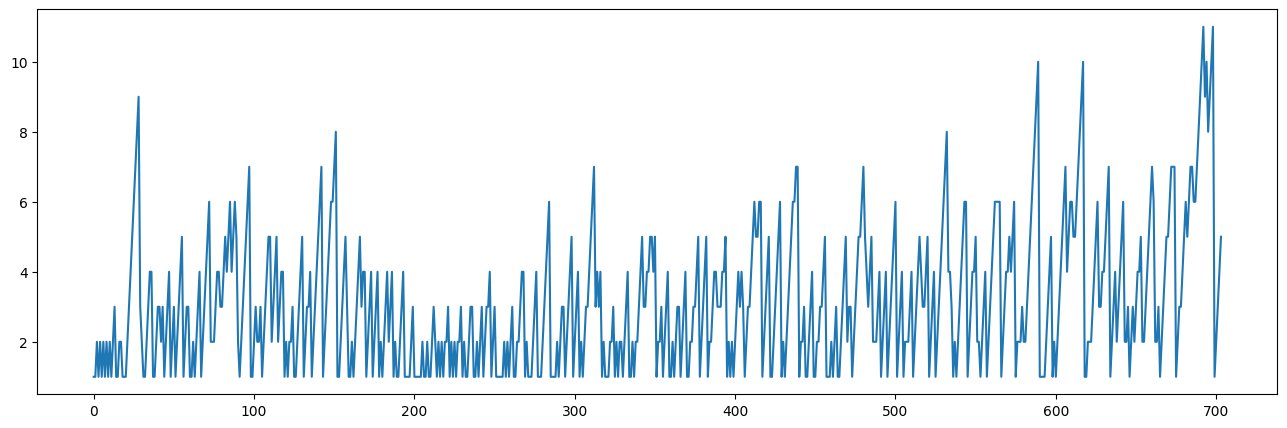

In [43]:
trade_details['concurrent_trades'].plot(figsize=(16, 5))
# trade_details['equity_after'].plot(figsize=(16, 5))

<Axes: >

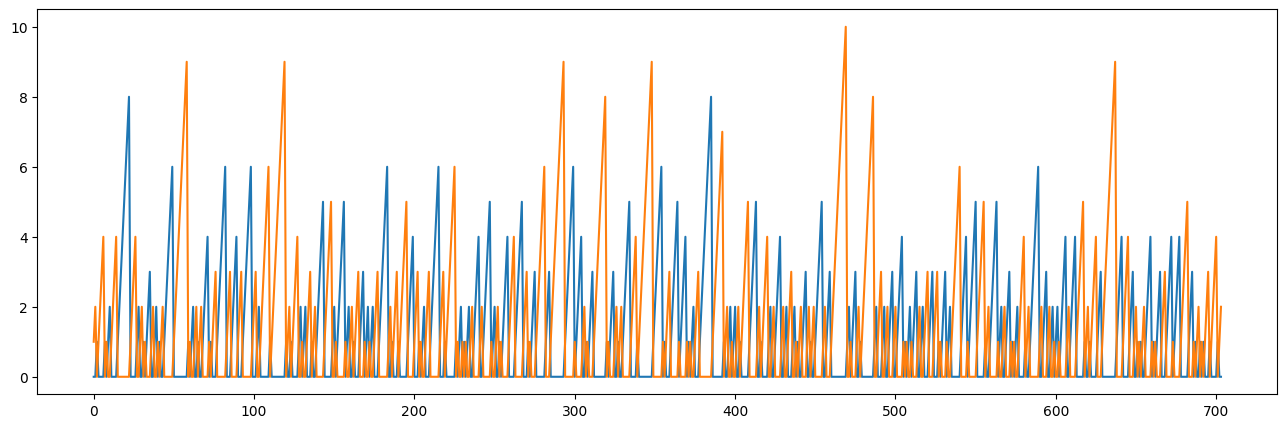

In [31]:
trade_details['consequtive_wins'].plot(figsize=(16, 5))
trade_details['consequtive_losses'].plot(figsize=(16, 5))

<Axes: >

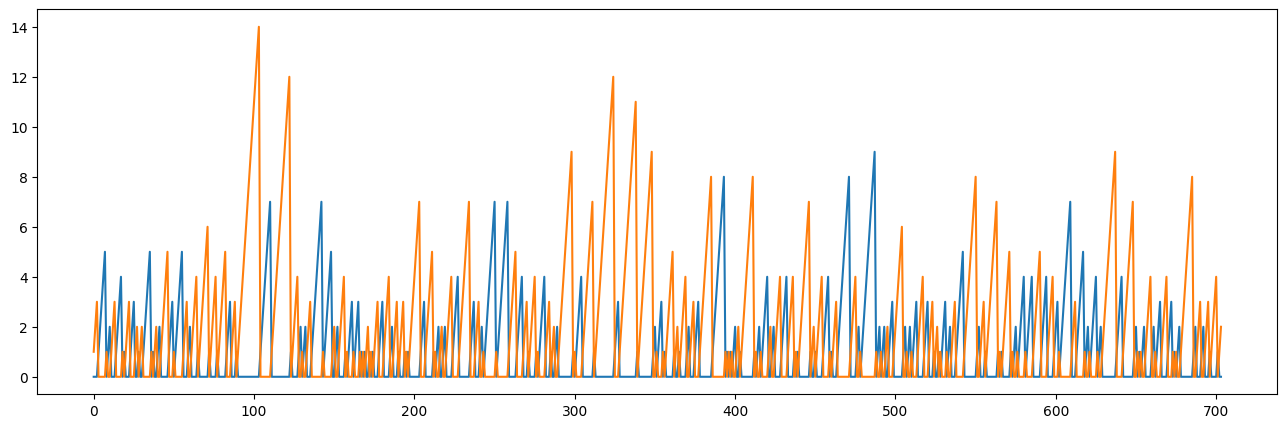

In [32]:
trade_details['consequtive_buys'].plot(figsize=(16, 5))
trade_details['consequtive_sells'].plot(figsize=(16, 5))
# trade_details['consequtive_buys']

In [34]:
trade_details
# trade_details_analysis

,direction,entry_time,entry_price,stop_price,take_profit_price,exit_time,exit_price,size,stop_distance_pips,size_pre_cap,...,size_after_max_cap,pnl,equity_after,win/loss,concurrent_trades,consequtive_wins,consequtive_losses,win_loss_sum,consequtive_buys,consequtive_sells
0,SELL,2025-01-05T21:20:00+00:00,1.03153,1.03503,1.02703,2025-01-06T04:00:00+00:00,1.03505,0.01,35.0,0.857143,...,0.01,-3.52,9996.48,0,1,0,1,-1,0,1
1,SELL,2025-01-07T00:40:00+00:00,1.03983,1.04333,1.03533,2025-01-07T04:05:00+00:00,1.04335,0.01,35.0,0.856841,...,0.01,-3.52,9992.96,0,1,0,2,-2,0,2
2,SELL,2025-01-07T00:50:00+00:00,1.04019,1.04369,1.03569,2025-01-07T10:50:00+00:00,1.03571,0.01,35.0,0.856841,...,0.01,4.48,9997.44,1,2,1,0,-1,0,3
3,BUY,2025-01-07T16:30:00+00:00,1.03424,1.03074,1.03874,2025-01-08T06:20:00+00:00,1.03072,0.01,35.0,0.856923,...,0.01,-3.52,9993.92,0,1,0,1,-2,1,0
4,BUY,2025-01-08T03:15:00+00:00,1.03247,1.02897,1.03697,2025-01-08T06:35:00+00:00,1.02895,0.01,35.0,0.856923,...,0.01,-3.52,9990.40,0,2,0,2,-3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,SELL,2025-12-10T18:35:00+00:00,1.16986,1.17336,1.16536,2025-12-11T08:50:00+00:00,1.17338,0.01,35.0,0.881445,...,0.01,-3.52,10280.00,0,1,0,3,-14,0,3
700,SELL,2025-12-10T18:50:00+00:00,1.17013,1.17363,1.16563,2025-12-11T08:55:00+00:00,1.17365,0.01,35.0,0.881445,...,0.01,-3.52,10277.44,0,2,0,4,-15,0,4
701,BUY,2025-12-10T23:35:00+00:00,1.16870,1.16520,1.17320,2025-12-11T08:50:00+00:00,1.17318,0.01,35.0,0.881445,...,0.01,4.48,10284.48,1,3,1,0,-14,1,0
702,SELL,2025-12-11T02:45:00+00:00,1.16979,1.17329,1.16529,2025-12-11T08:50:00+00:00,1.17331,0.01,35.0,0.881445,...,0.01,-3.52,10280.96,0,4,0,1,-15,0,1


In [35]:
# Build trade_details_analysis with 50+ strategy selectors
import numpy as np

# Base dataframe
_df = trade_details.copy()

# Derived features
_df['entry_dt'] = pd.to_datetime(_df['entry_time'])
_df['exit_dt'] = pd.to_datetime(_df['exit_time'])
_df['entry_hour'] = _df['entry_dt'].dt.hour
_df['entry_dow'] = _df['entry_dt'].dt.dayofweek  # Monday=0
_df['duration_min'] = (_df['exit_dt'] - _df['entry_dt']).dt.total_seconds() / 60.0
_df['is_buy'] = _df['direction'] == 'BUY'
_df['is_sell'] = _df['direction'] == 'SELL'

# Prior states (use previous trade values)
_prev_dir = _df['direction'].shift(1)
_prev_win_streak = _df['consequtive_wins'].shift(1).fillna(0).astype(int)
_prev_loss_streak = _df['consequtive_losses'].shift(1).fillna(0).astype(int)
_prev_buy_streak = _df['consequtive_buys'].shift(1).fillna(0).astype(int)
_prev_sell_streak = _df['consequtive_sells'].shift(1).fillna(0).astype(int)
_prev_win = _df['win/loss'].shift(1).fillna(0).astype(int)
_prev_loss = (1 - _df['win/loss']).shift(1).fillna(0).astype(int)

# Rolling performance (prior window only)
_roll3 = _df['win/loss'].shift(1).rolling(3).mean().fillna(0)
_roll5 = _df['win/loss'].shift(1).rolling(5).mean().fillna(0)
_roll10 = _df['win/loss'].shift(1).rolling(10).mean().fillna(0)

_to_int = lambda s: s.astype(int)

strategies = {}

# 1) Concurrency caps (6)
for k in [1, 2, 3, 4, 5, 6]:
    strategies[f'strat_concurrency_le_{k}'] = _to_int(_df['concurrent_trades'] <= k)

# 2) Direction streak gating (BUY/SELL) (8)
for n in [2, 3, 4, 5]:
    strategies[f'strat_prev_buystreak_ge_{n}'] = _to_int(_prev_buy_streak >= n)
for n in [2, 3, 4, 5]:
    strategies[f'strat_prev_sellstreak_ge_{n}'] = _to_int(_prev_sell_streak >= n)
# Combined: any dir streak >= 2 (1)
strategies['strat_prev_dir_streak_ge_2'] = _to_int((_prev_buy_streak >= 2) | (_prev_sell_streak >= 2))

# 3) Win/Loss streak gating based on prior trades (10)
for n in [1, 2, 3, 4, 5]:
    strategies[f'strat_prev_win_streak_ge_{n}'] = _to_int(_prev_win_streak >= n)
for n in [1, 2, 3, 4, 5]:
    strategies[f'strat_prev_loss_streak_ge_{n}'] = _to_int(_prev_loss_streak >= n)

# 4) Previous outcome + direction combinations (4)
strategies['strat_prev_was_win'] = _to_int(_prev_win == 1)
strategies['strat_prev_was_loss'] = _to_int(_prev_win == 0)
strategies['strat_prev_win_same_dir'] = _to_int((_prev_win == 1) & (_df['direction'] == _prev_dir))
strategies['strat_prev_loss_reverse_dir'] = _to_int((_prev_win == 0) & (_df['direction'] != _prev_dir))

# 5) Time-of-day session filters (4)
strategies['strat_session_early_0_6'] = _to_int(_df['entry_hour'].between(0, 6))
strategies['strat_session_london_7_12'] = _to_int(_df['entry_hour'].between(7, 12))
strategies['strat_session_newyork_13_18'] = _to_int(_df['entry_hour'].between(13, 18))
strategies['strat_session_off_19_23'] = _to_int(_df['entry_hour'].between(19, 23))

# 6) Day-of-week filters (2)
strategies['strat_weekdays_only_mon_fri'] = _to_int(_df['entry_dow'] <= 4)
strategies['strat_mon_thu_only'] = _to_int(_df['entry_dow'].between(0, 3))

# 7) Duration-based filters (4)
strategies['strat_duration_le_60min'] = _to_int(_df['duration_min'] <= 60)
strategies['strat_duration_le_120min'] = _to_int(_df['duration_min'] <= 120)
strategies['strat_duration_ge_180min'] = _to_int(_df['duration_min'] >= 180)
strategies['strat_duration_60_180min'] = _to_int((_df['duration_min'] >= 60) & (_df['duration_min'] <= 180))

# 8) Stop distance pips (4)
if 'stop_distance_pips' in _df.columns:
    strategies['strat_stop_pips_le_8'] = _to_int(_df['stop_distance_pips'] <= 8)
    strategies['strat_stop_pips_le_10'] = _to_int(_df['stop_distance_pips'] <= 10)
    strategies['strat_stop_pips_10_15'] = _to_int((_df['stop_distance_pips'] >= 10) & (_df['stop_distance_pips'] <= 15))
    strategies['strat_stop_pips_ge_15'] = _to_int(_df['stop_distance_pips'] >= 15)
else:
    # Fallback if column not present
    strategies['strat_stop_pips_le_8'] = _to_int(pd.Series(False, index=_df.index))
    strategies['strat_stop_pips_le_10'] = _to_int(pd.Series(False, index=_df.index))
    strategies['strat_stop_pips_10_15'] = _to_int(pd.Series(False, index=_df.index))
    strategies['strat_stop_pips_ge_15'] = _to_int(pd.Series(False, index=_df.index))

# 9) Rolling win-rate filters (4)
strategies['strat_roll3_winrate_ge_0_66'] = _to_int(_roll3 >= (2/3))
strategies['strat_roll5_winrate_ge_0_60'] = _to_int(_roll5 >= 0.60)
strategies['strat_roll10_winrate_ge_0_60'] = _to_int(_roll10 >= 0.60)
strategies['strat_roll5_winrate_le_0_40'] = _to_int(_roll5 <= 0.40)

# 10) Direction-only & alternation (4)
strategies['strat_only_buy'] = _to_int(_df['is_buy'])
strategies['strat_only_sell'] = _to_int(_df['is_sell'])
strategies['strat_alternate_direction'] = _to_int(_df['direction'] != _prev_dir)
strategies['strat_reversal_after_buy_streak_ge_2'] = _to_int((_prev_buy_streak >= 2) & (_df['direction'] == 'SELL'))
strategies['strat_reversal_after_sell_streak_ge_2'] = _to_int((_prev_sell_streak >= 2) & (_df['direction'] == 'BUY'))

# 11) Combined conditions for more nuanced filters (8)
strategies['strat_london_and_conc_le_2'] = _to_int(_df['entry_hour'].between(7, 12) & (_df['concurrent_trades'] <= 2))
strategies['strat_london'] = _to_int(_df['entry_hour'].between(7, 12))
strategies['strat_newyork_and_prev_win'] = _to_int(_df['entry_hour'].between(13, 18) & (_prev_win == 1))
strategies['strat_early_and_prev_loss'] = _to_int(_df['entry_hour'].between(0, 6) & (_prev_win == 0))
strategies['strat_duration_le_120_and_conc_le_3'] = _to_int((_df['duration_min'] <= 120) & (_df['concurrent_trades'] <= 3))
strategies['strat_stop_le_10_and_buy'] = _to_int((_df.get('stop_distance_pips', np.inf) <= 10) & _df['is_buy'])
strategies['strat_stop_ge_15_and_sell'] = _to_int((_df.get('stop_distance_pips', -np.inf) >= 15) & _df['is_sell'])
strategies['strat_prev_loss_streak_ge_2_and_reverse'] = _to_int((_prev_loss_streak >= 2) & (_df['direction'] != _prev_dir))
strategies['strat_prev_win_streak_ge_2_and_same_dir'] = _to_int((_prev_win_streak >= 2) & (_df['direction'] == _prev_dir))

# Assemble analysis dataframe
trade_details_analysis = pd.DataFrame(strategies, index=_df.index)
trade_details_analysis.head()

"""
strat_concurrency_le_1
strat_concurrency_le_2
strat_concurrency_le_3
strat_london_and_conc_le_2
strat_duration_le_120_and_conc_le_3"""

'\nstrat_concurrency_le_1\nstrat_concurrency_le_2\nstrat_concurrency_le_3\nstrat_london_and_conc_le_2\nstrat_duration_le_120_and_conc_le_3'

In [36]:
trade_details_new = trade_details.combine_first(trade_details_analysis)
trade_details_new.set_index('entry_time', inplace=True)

trade_details_dict = {}
for column in trade_details_analysis.columns:
    trade_details_dict[column] = {}
    df_temp = trade_details_new['win/loss'][trade_details_new[column] == 1]
    
    sum_of_win_loss = []
    sum_win_loss = 0
    
    for item in df_temp.items():
        if item[1] == 1:
            sum_win_loss += 1
        else:
            sum_win_loss -= 1
        
        sum_of_win_loss.append(sum_win_loss)
        
    trade_details_dict[column]['datetimes'] = df_temp.index
    trade_details_dict[column]['values'] = sum_of_win_loss

strat_concurrency_le_1


<Figure size 1600x500 with 0 Axes>

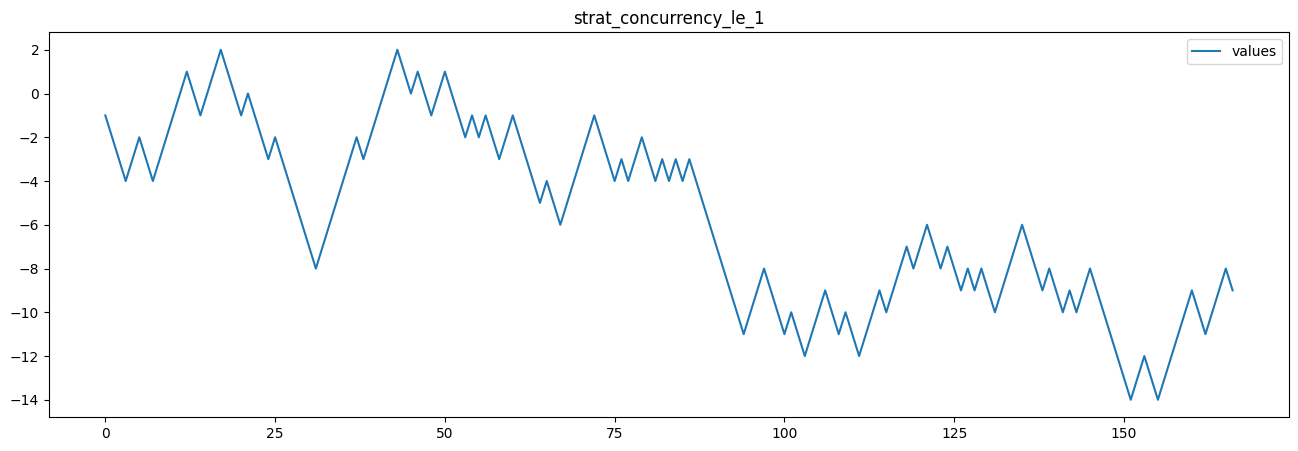

strat_concurrency_le_2


<Figure size 1600x500 with 0 Axes>

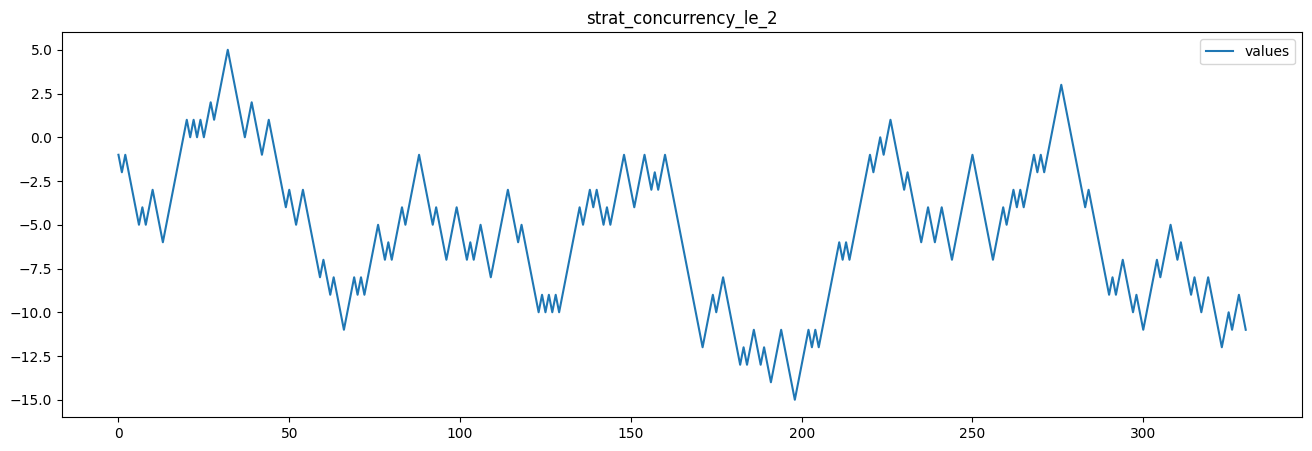

strat_concurrency_le_3


<Figure size 1600x500 with 0 Axes>

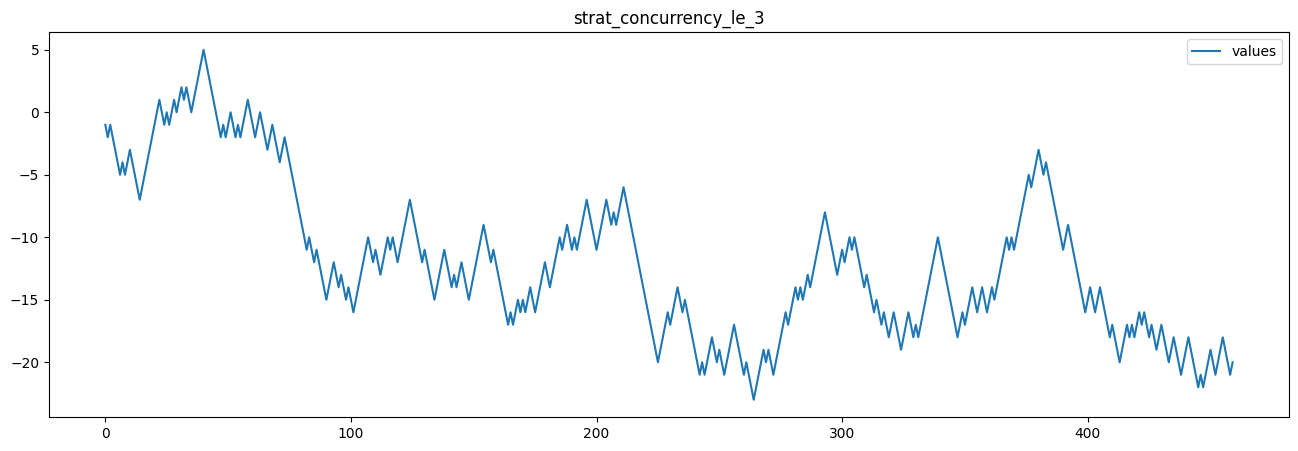

strat_concurrency_le_4


<Figure size 1600x500 with 0 Axes>

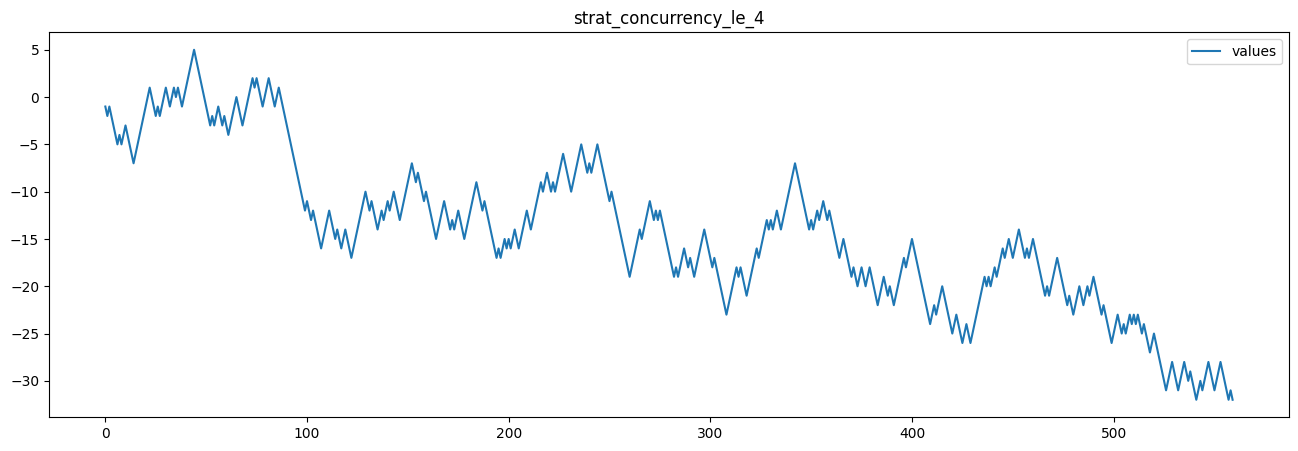

strat_concurrency_le_5


<Figure size 1600x500 with 0 Axes>

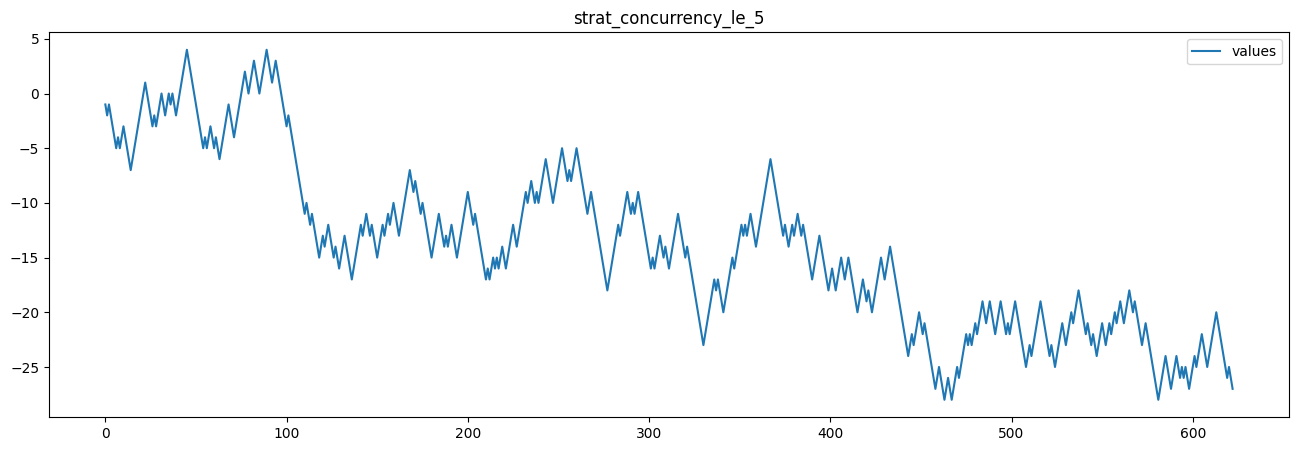

strat_concurrency_le_6


<Figure size 1600x500 with 0 Axes>

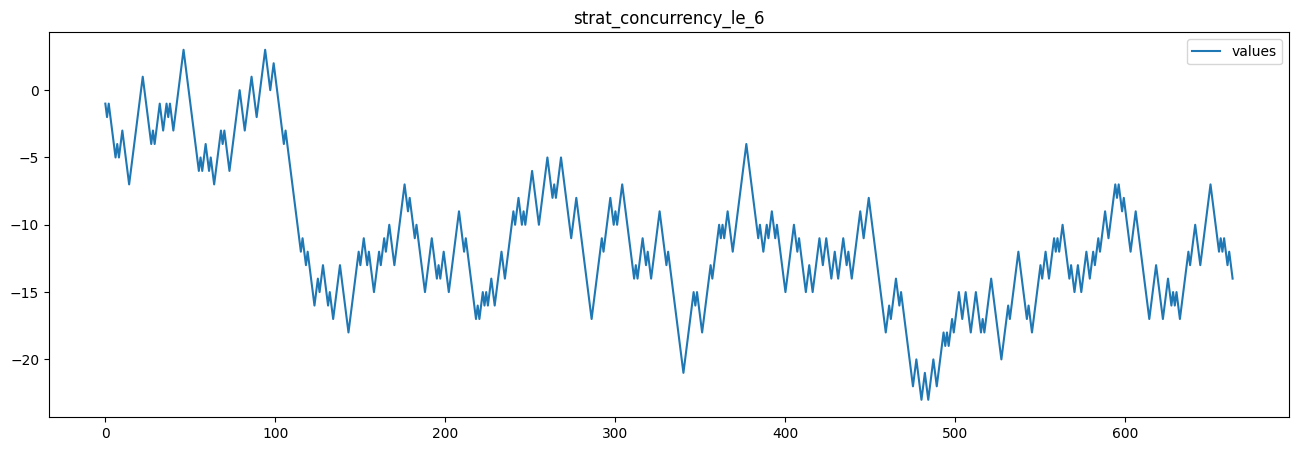

strat_prev_buystreak_ge_2


<Figure size 1600x500 with 0 Axes>

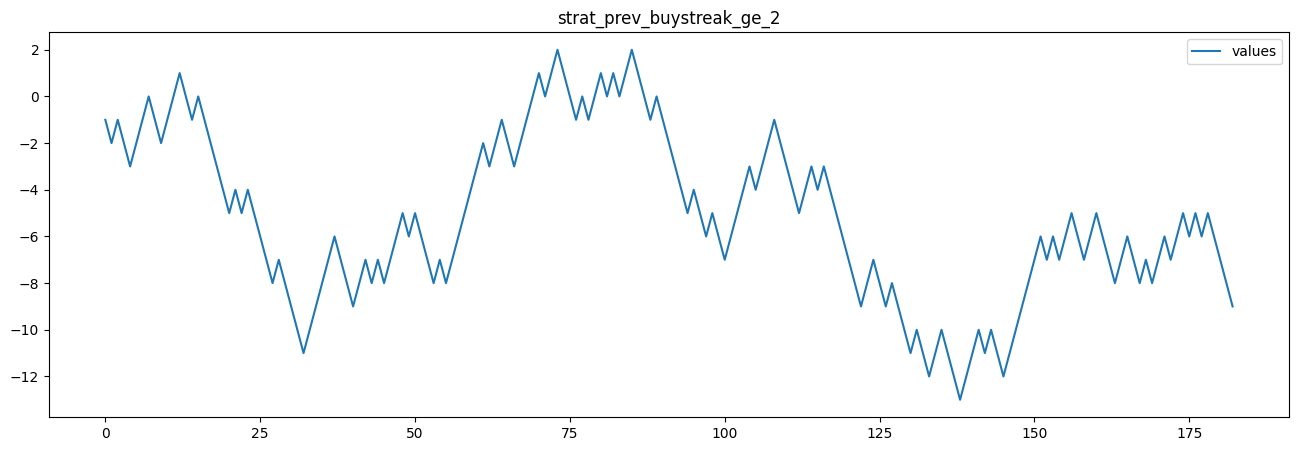

strat_prev_buystreak_ge_3


<Figure size 1600x500 with 0 Axes>

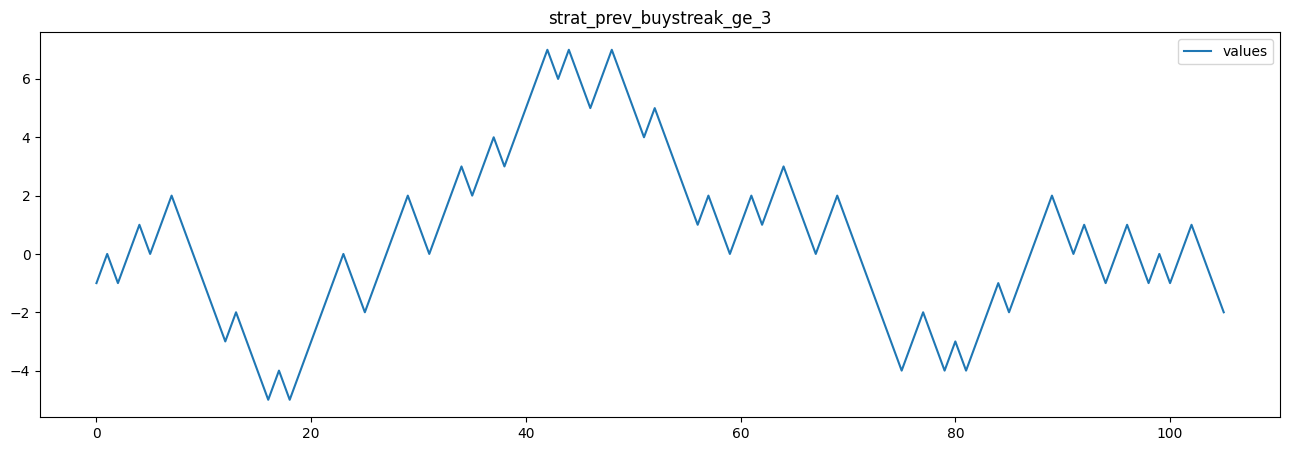

strat_prev_buystreak_ge_4


<Figure size 1600x500 with 0 Axes>

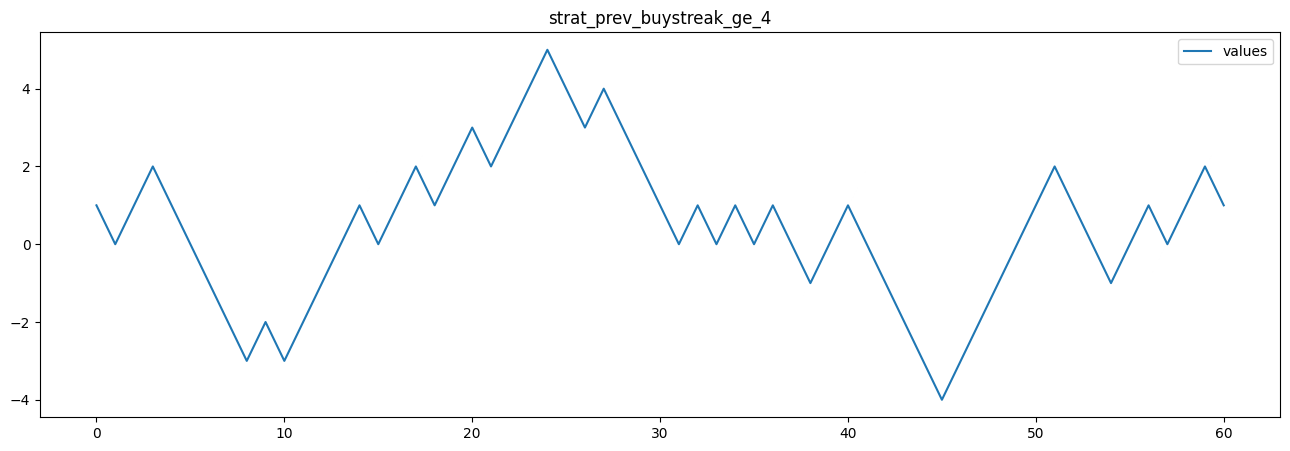

strat_prev_buystreak_ge_5


<Figure size 1600x500 with 0 Axes>

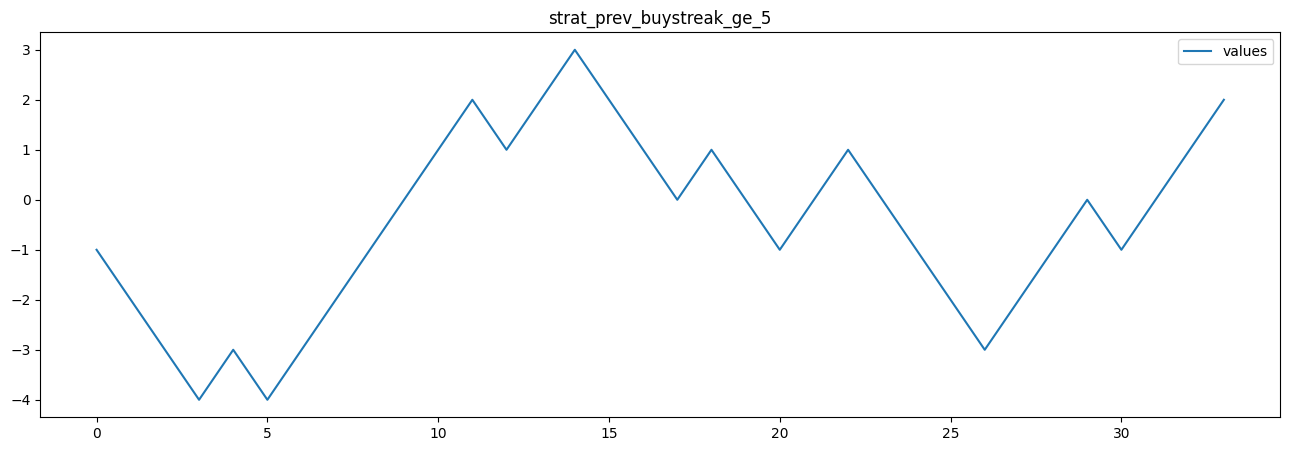

strat_prev_sellstreak_ge_2


<Figure size 1600x500 with 0 Axes>

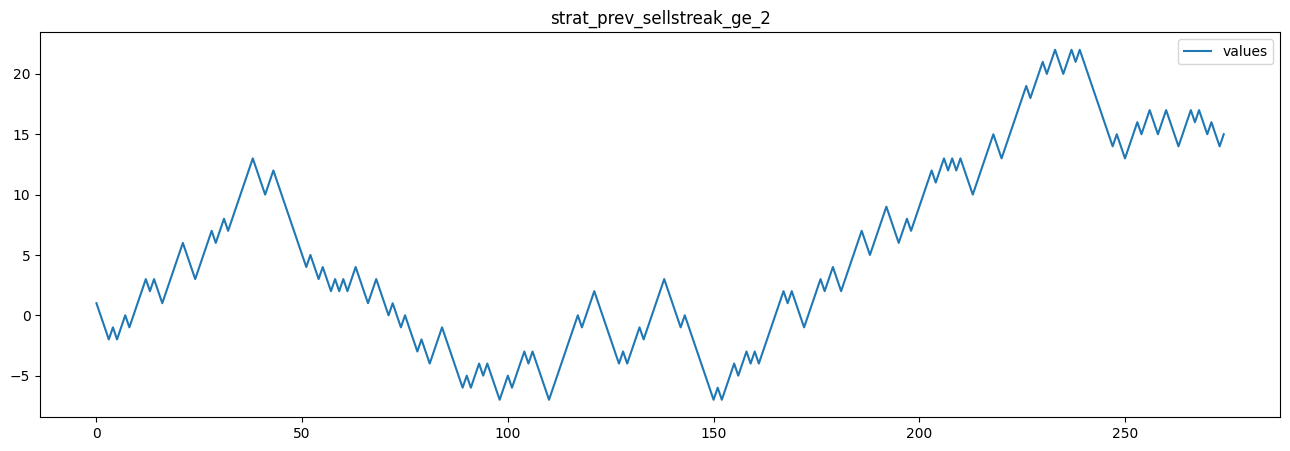

strat_prev_sellstreak_ge_3


<Figure size 1600x500 with 0 Axes>

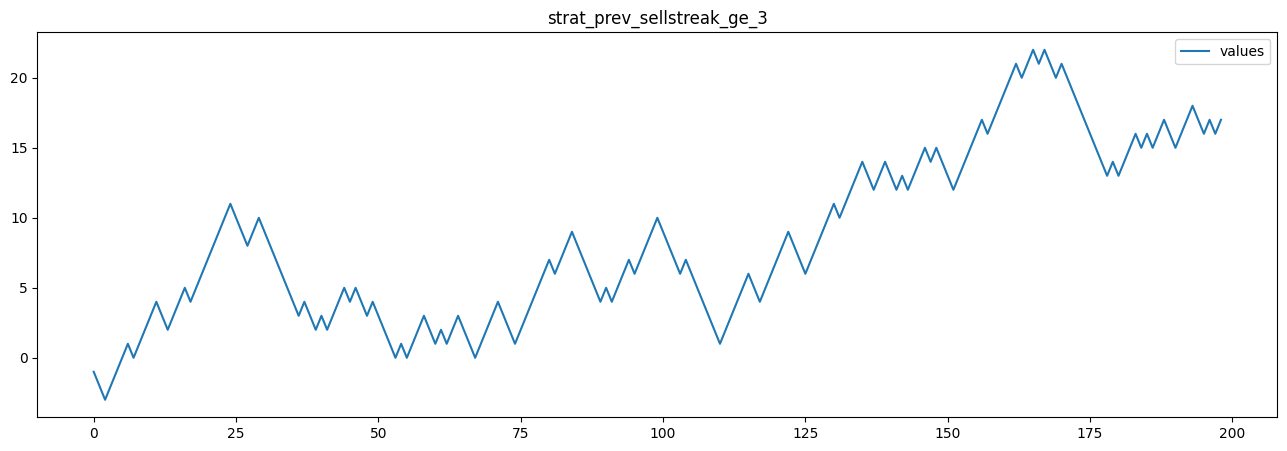

strat_prev_sellstreak_ge_4


<Figure size 1600x500 with 0 Axes>

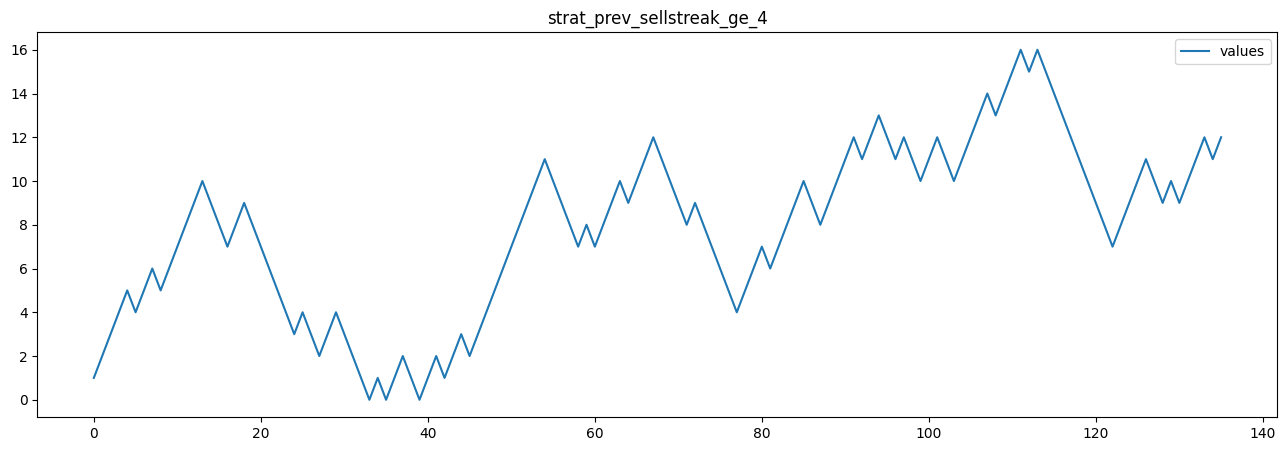

strat_prev_sellstreak_ge_5


<Figure size 1600x500 with 0 Axes>

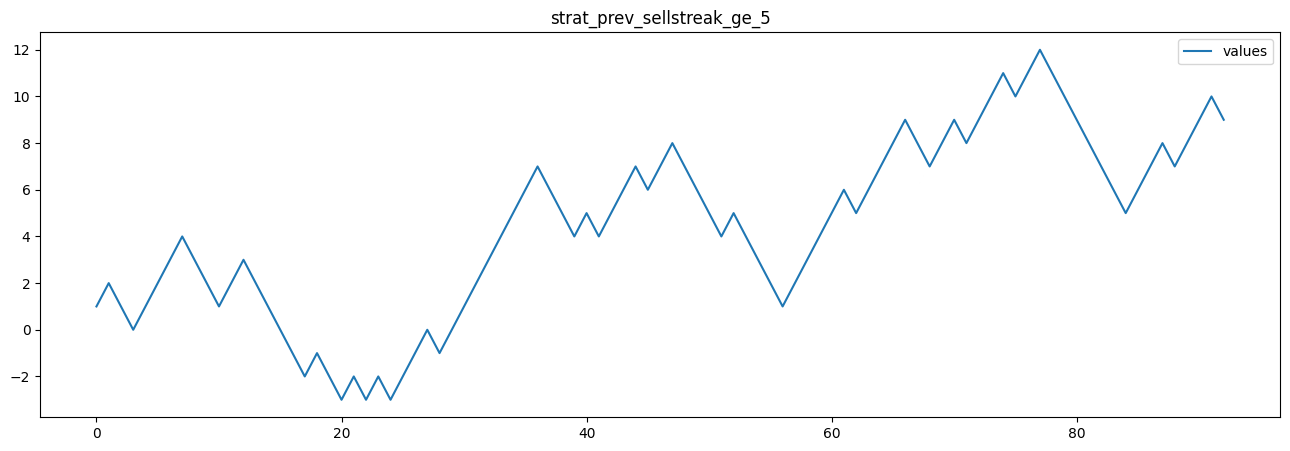

strat_prev_dir_streak_ge_2


<Figure size 1600x500 with 0 Axes>

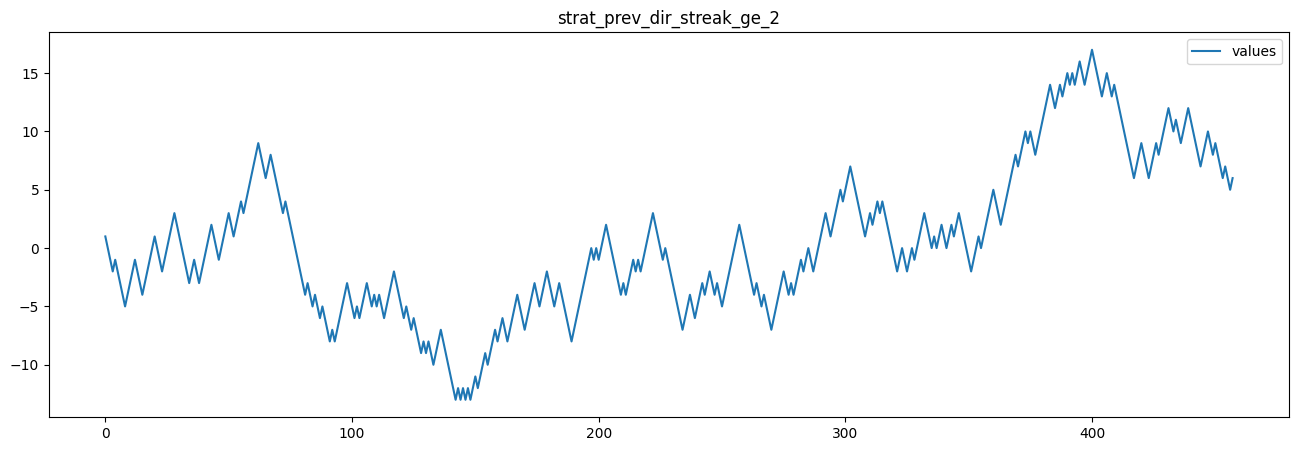

strat_prev_win_streak_ge_1


<Figure size 1600x500 with 0 Axes>

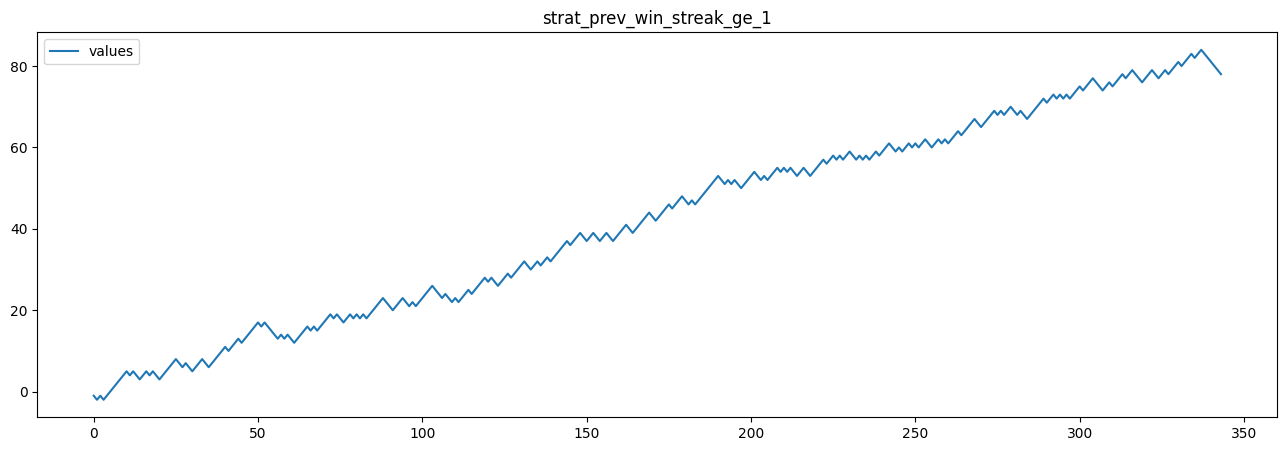

strat_prev_win_streak_ge_2


<Figure size 1600x500 with 0 Axes>

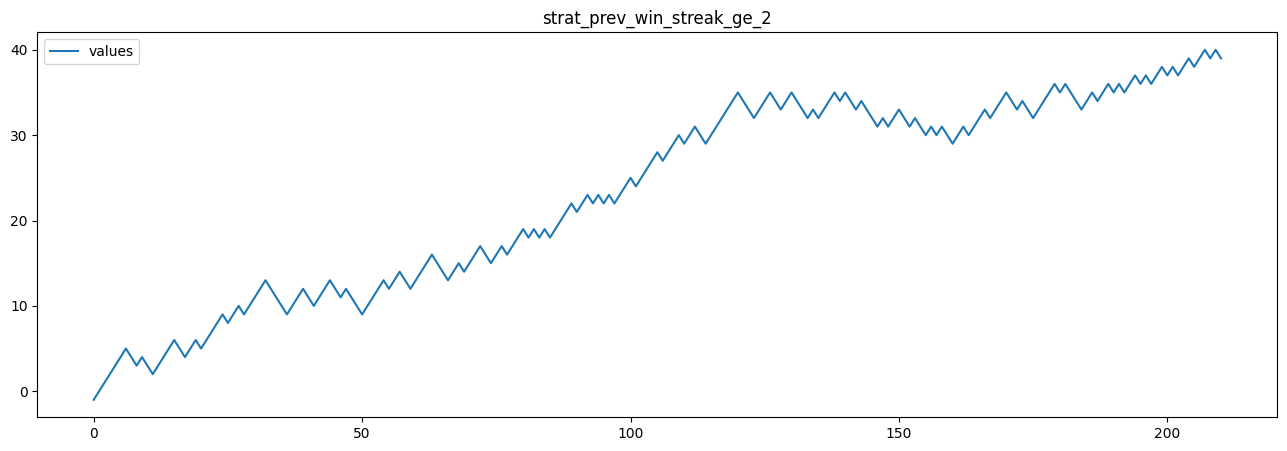

strat_prev_win_streak_ge_3


<Figure size 1600x500 with 0 Axes>

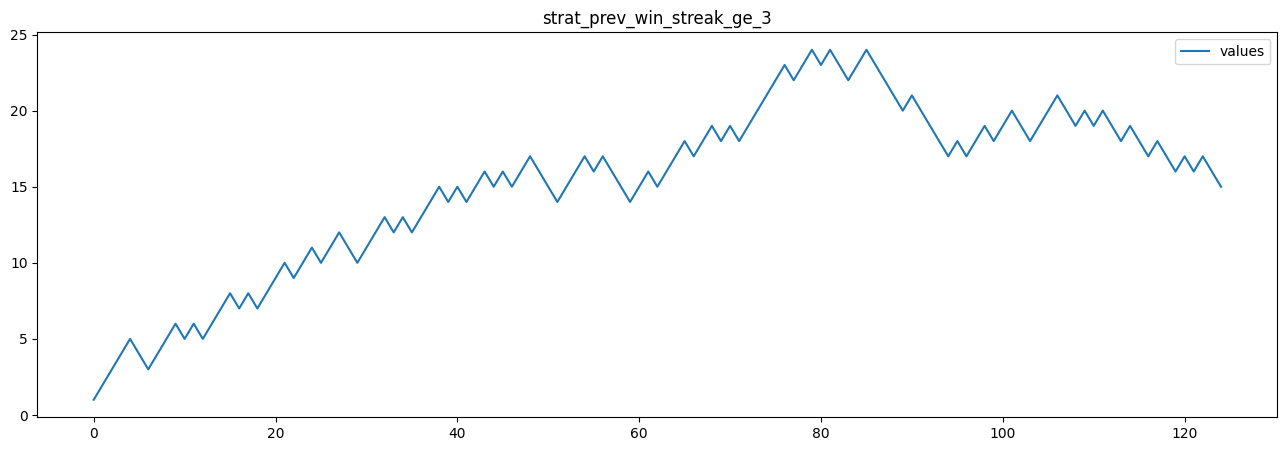

strat_prev_win_streak_ge_4


<Figure size 1600x500 with 0 Axes>

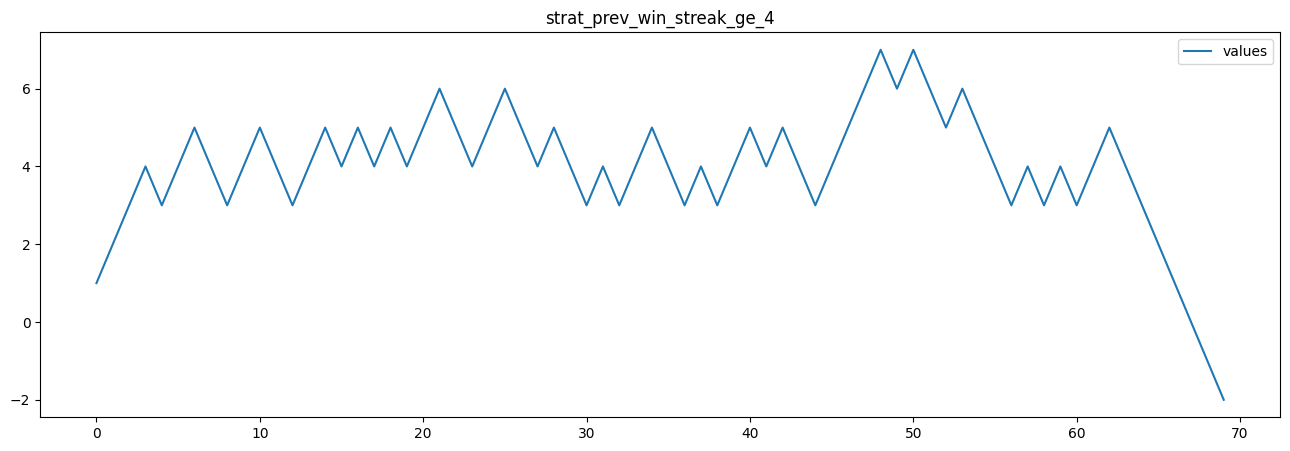

strat_prev_win_streak_ge_5


<Figure size 1600x500 with 0 Axes>

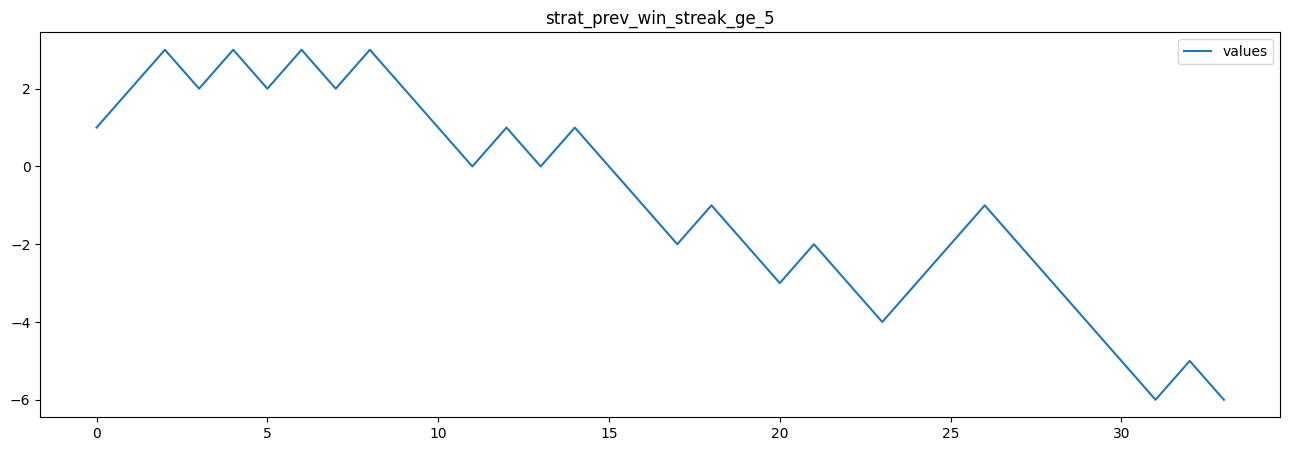

strat_prev_loss_streak_ge_1


<Figure size 1600x500 with 0 Axes>

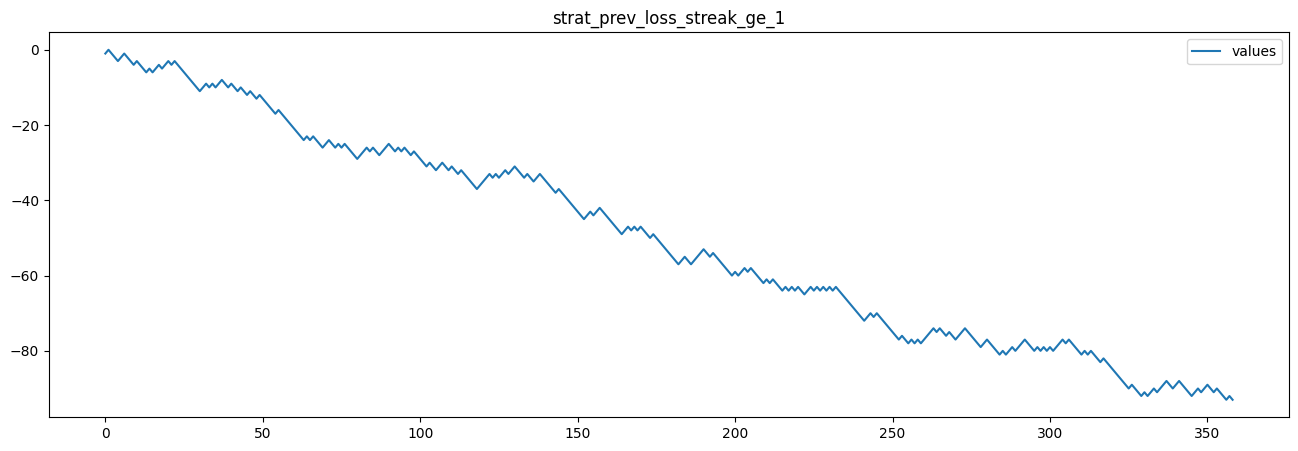

strat_prev_loss_streak_ge_2


<Figure size 1600x500 with 0 Axes>

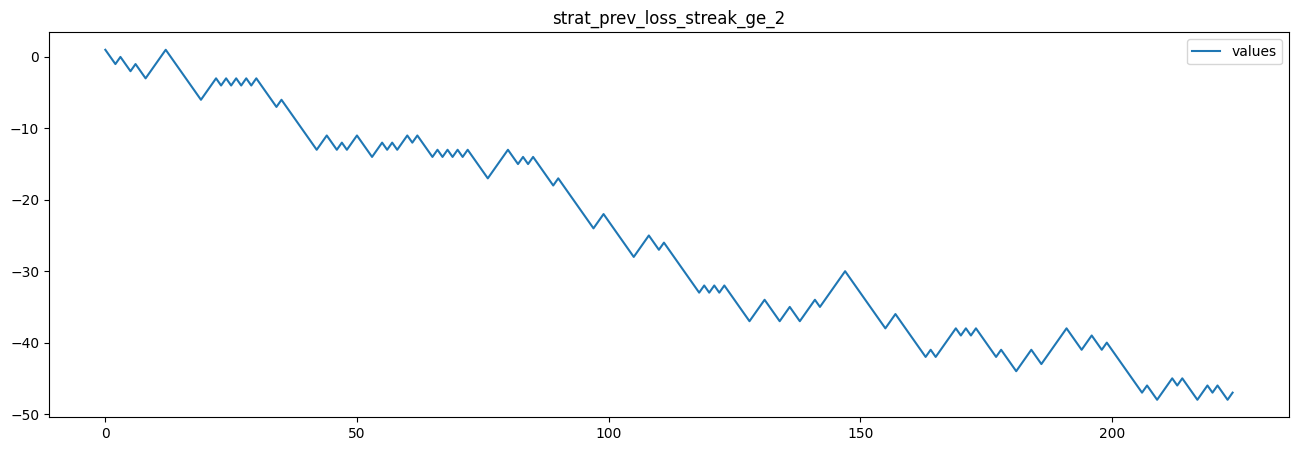

strat_prev_loss_streak_ge_3


<Figure size 1600x500 with 0 Axes>

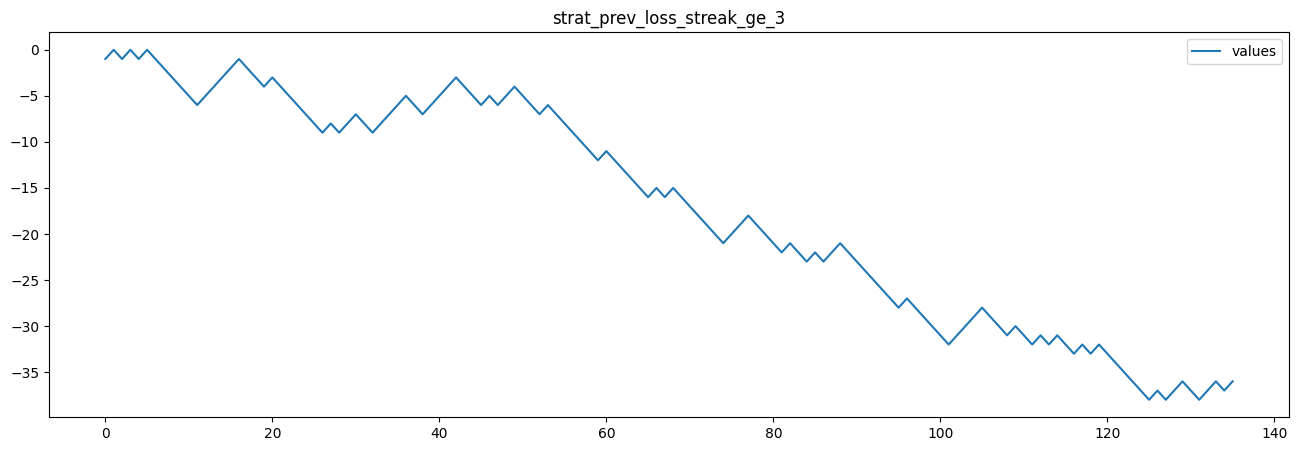

strat_prev_loss_streak_ge_4


<Figure size 1600x500 with 0 Axes>

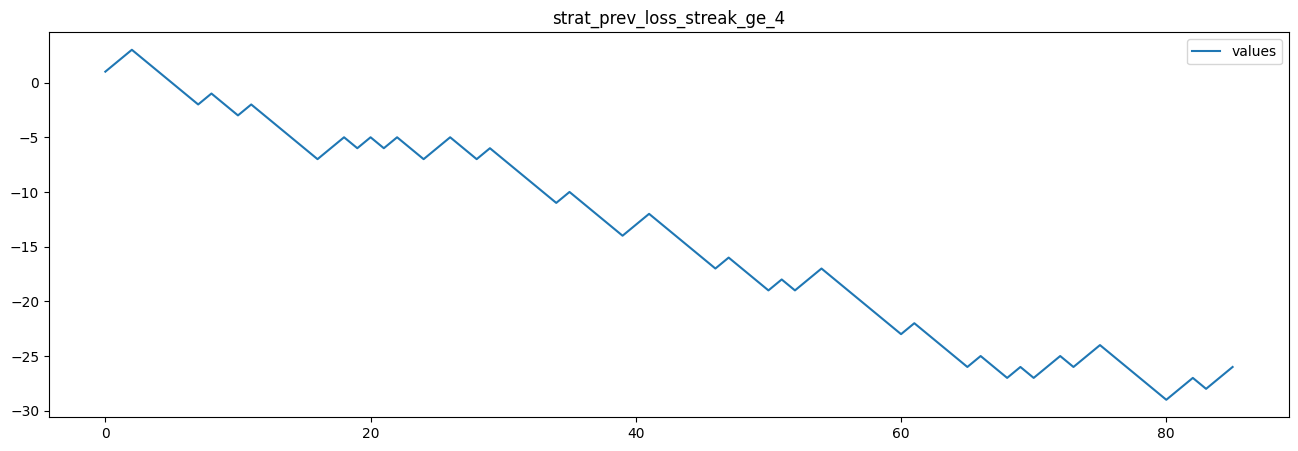

strat_prev_loss_streak_ge_5


<Figure size 1600x500 with 0 Axes>

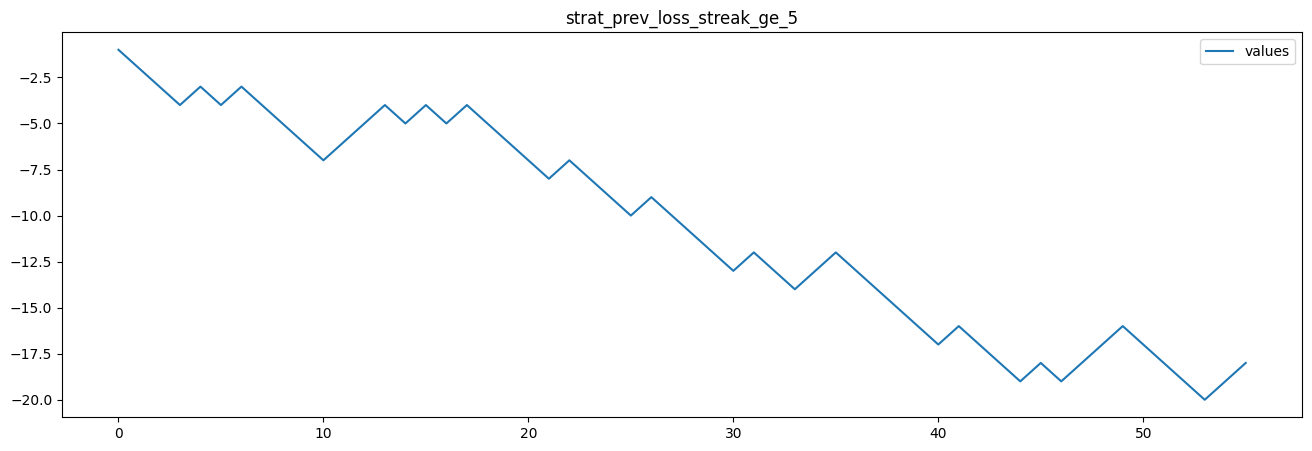

strat_prev_was_win


<Figure size 1600x500 with 0 Axes>

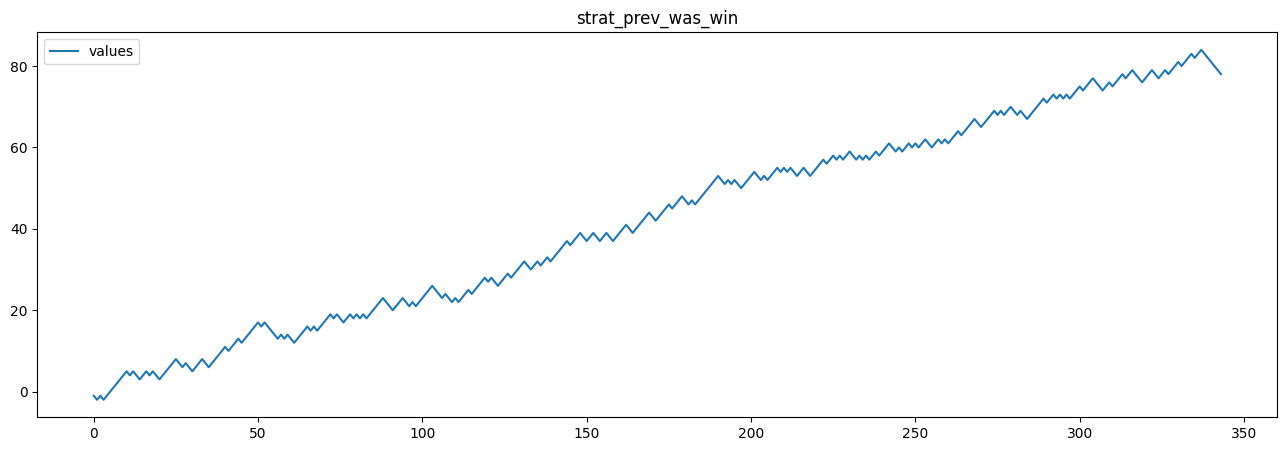

strat_prev_was_loss


<Figure size 1600x500 with 0 Axes>

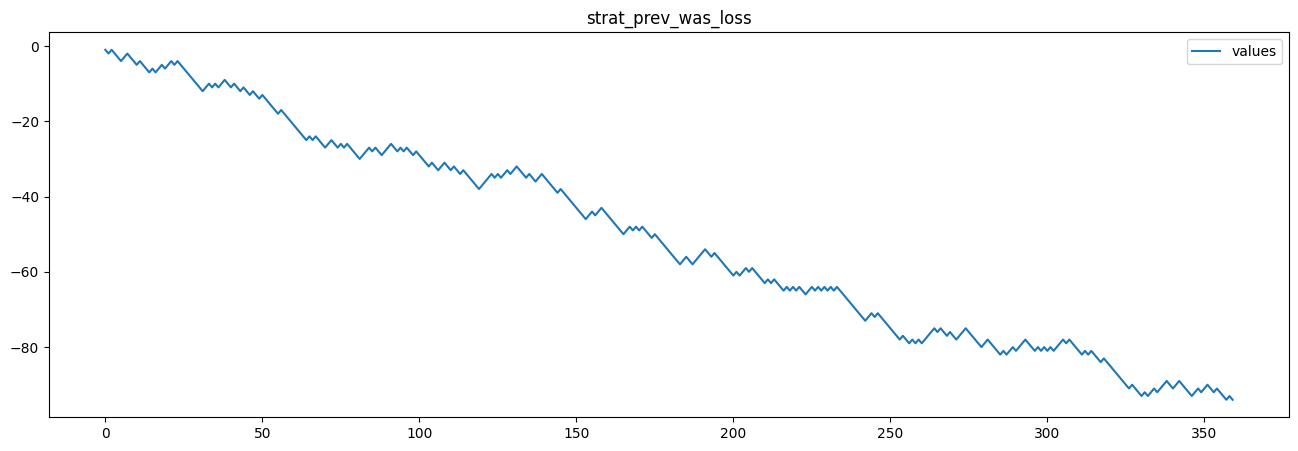

strat_prev_win_same_dir


<Figure size 1600x500 with 0 Axes>

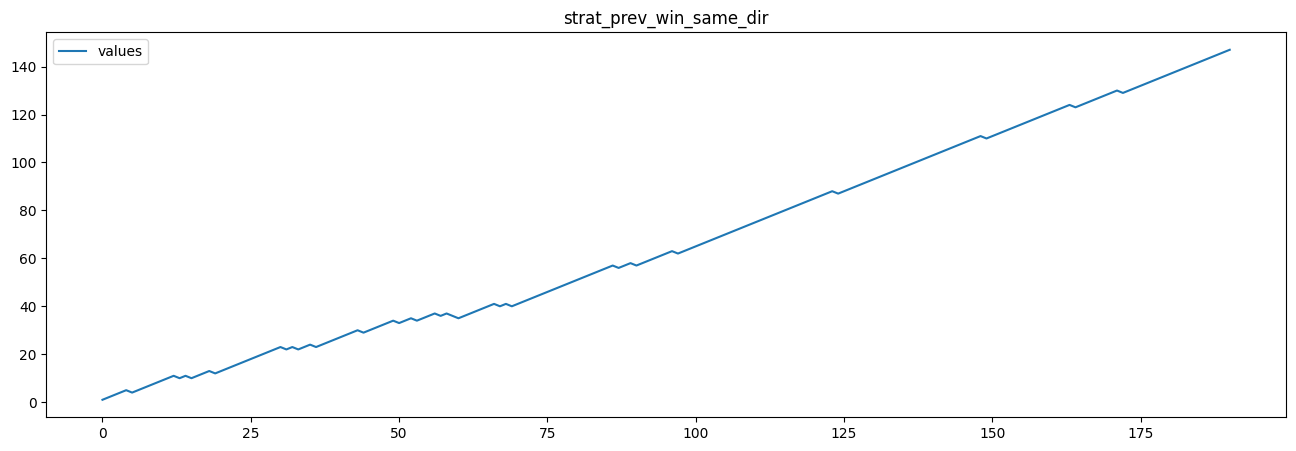

strat_prev_loss_reverse_dir


<Figure size 1600x500 with 0 Axes>

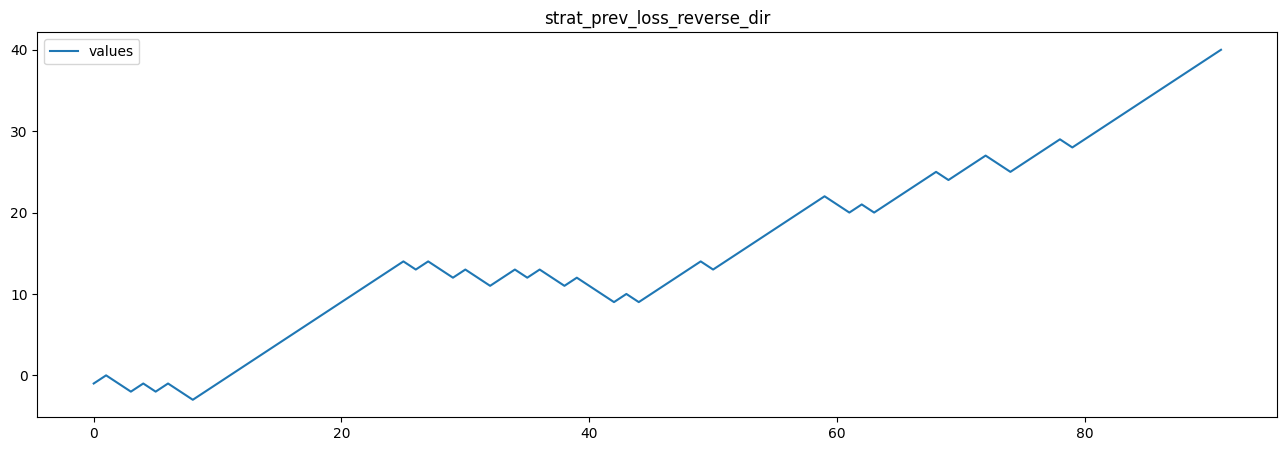

strat_session_early_0_6


<Figure size 1600x500 with 0 Axes>

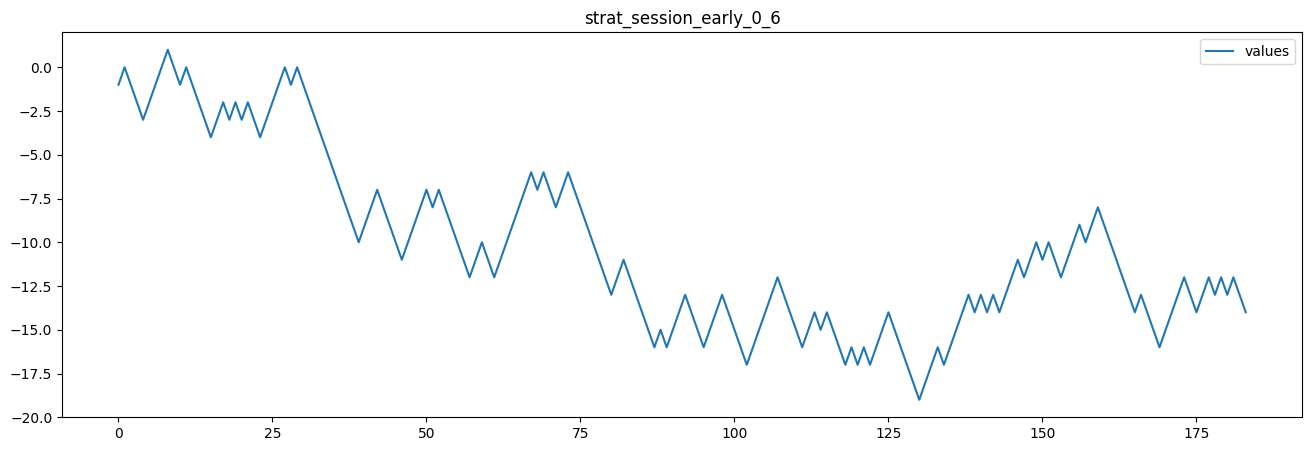

strat_session_london_7_12


<Figure size 1600x500 with 0 Axes>

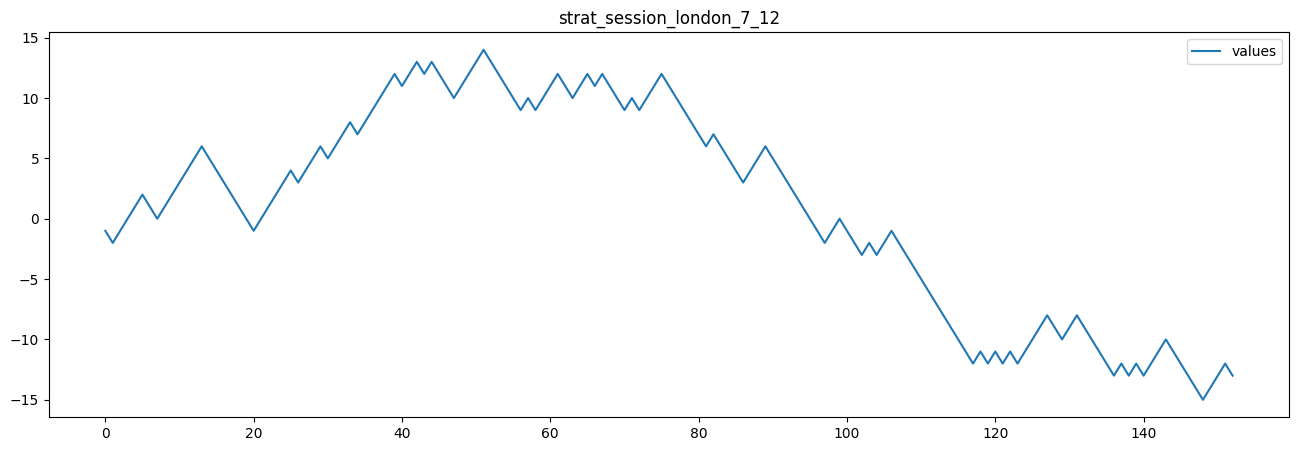

strat_session_newyork_13_18


<Figure size 1600x500 with 0 Axes>

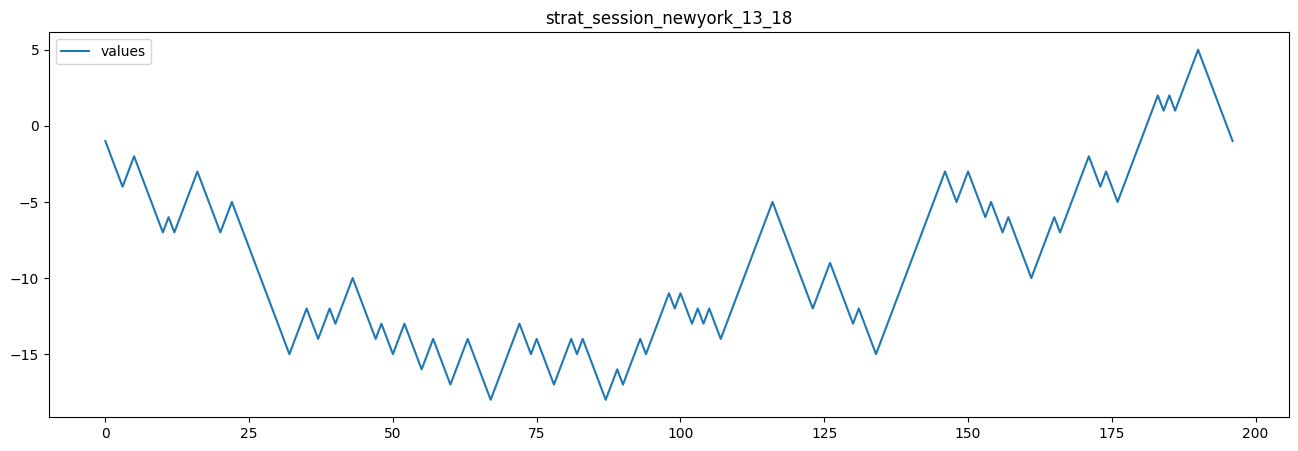

strat_session_off_19_23


<Figure size 1600x500 with 0 Axes>

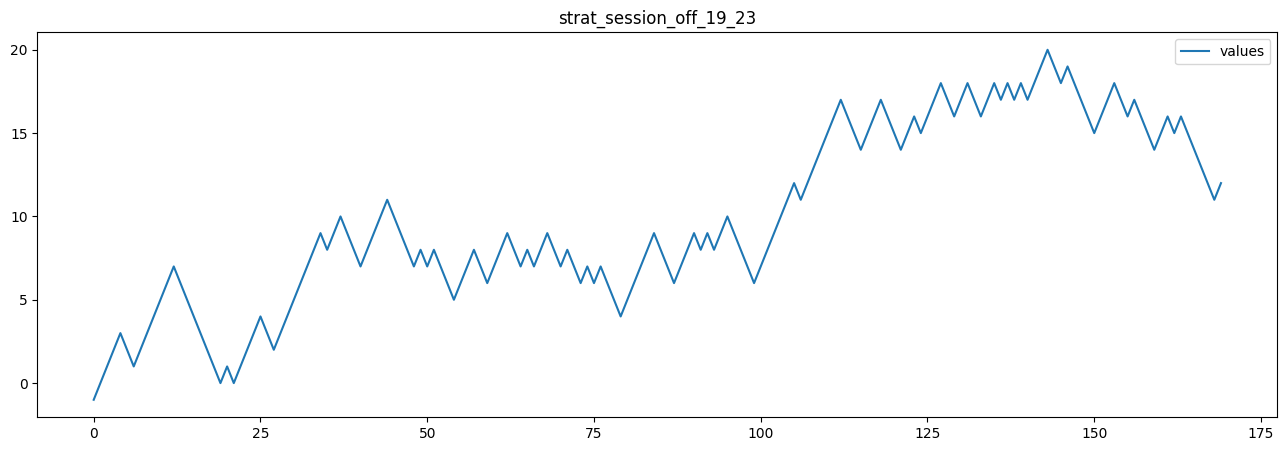

strat_weekdays_only_mon_fri


<Figure size 1600x500 with 0 Axes>

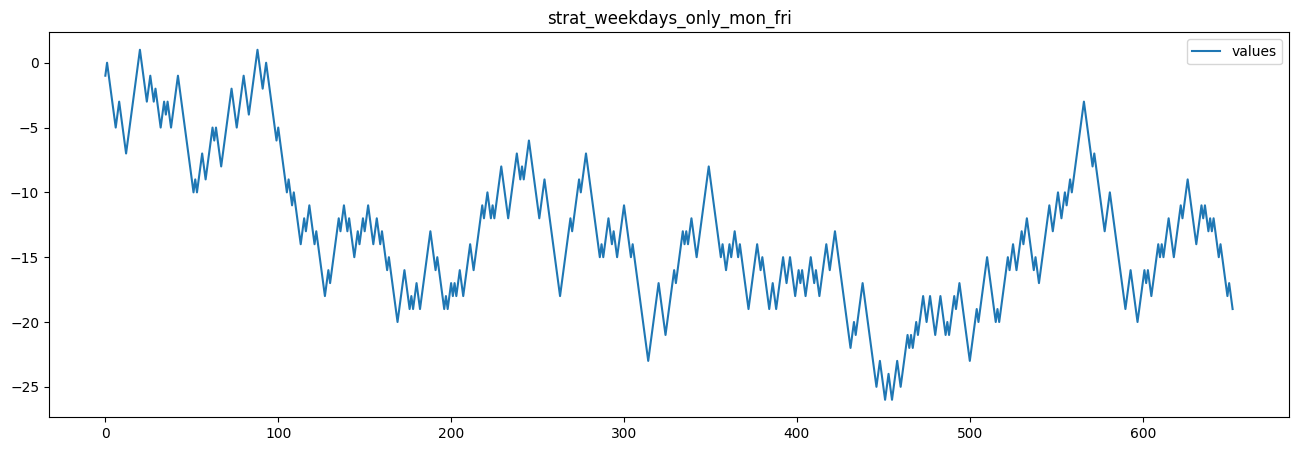

strat_mon_thu_only


<Figure size 1600x500 with 0 Axes>

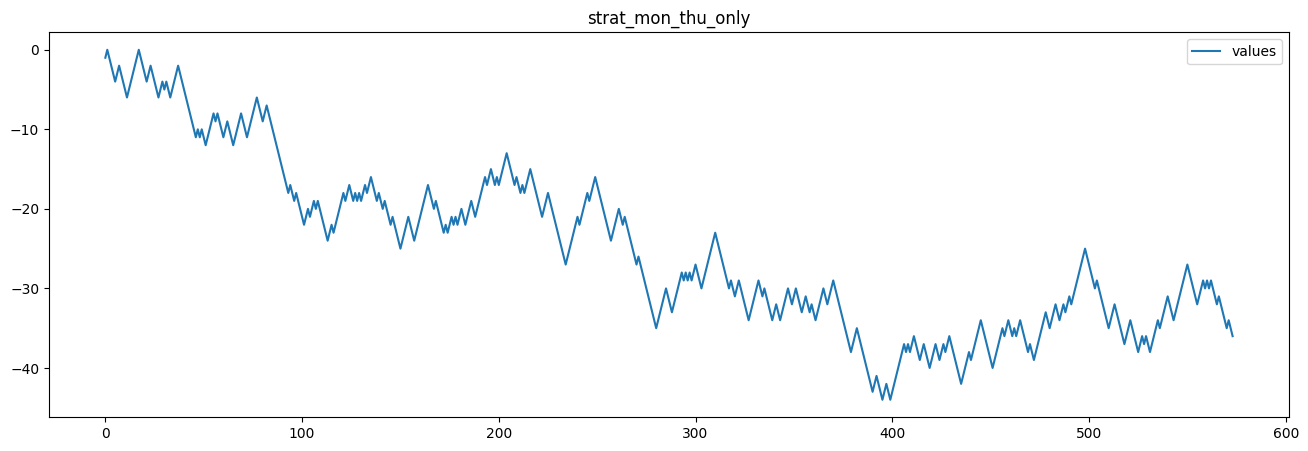

strat_duration_le_60min


<Figure size 1600x500 with 0 Axes>

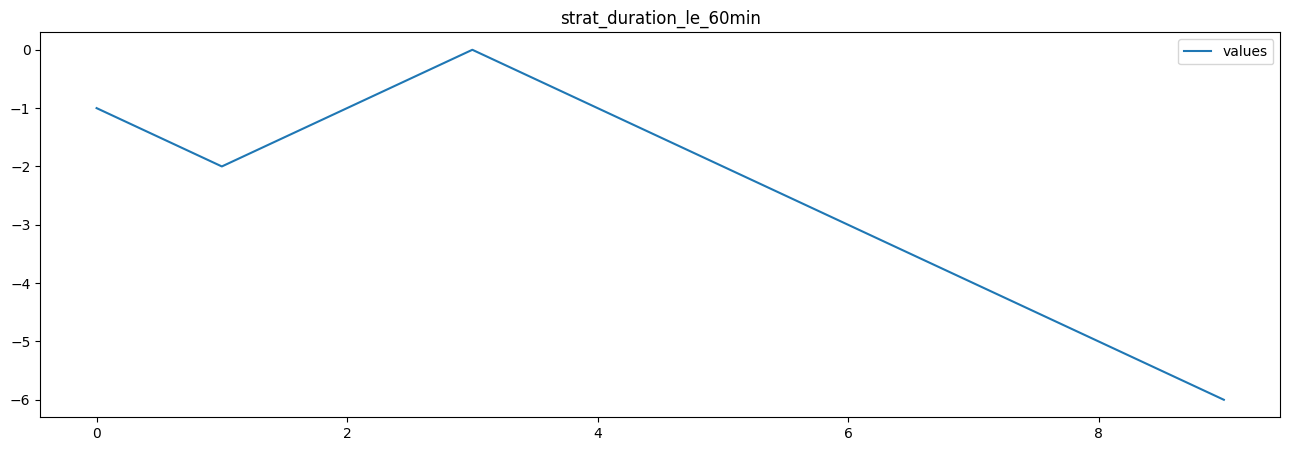

strat_duration_le_120min


<Figure size 1600x500 with 0 Axes>

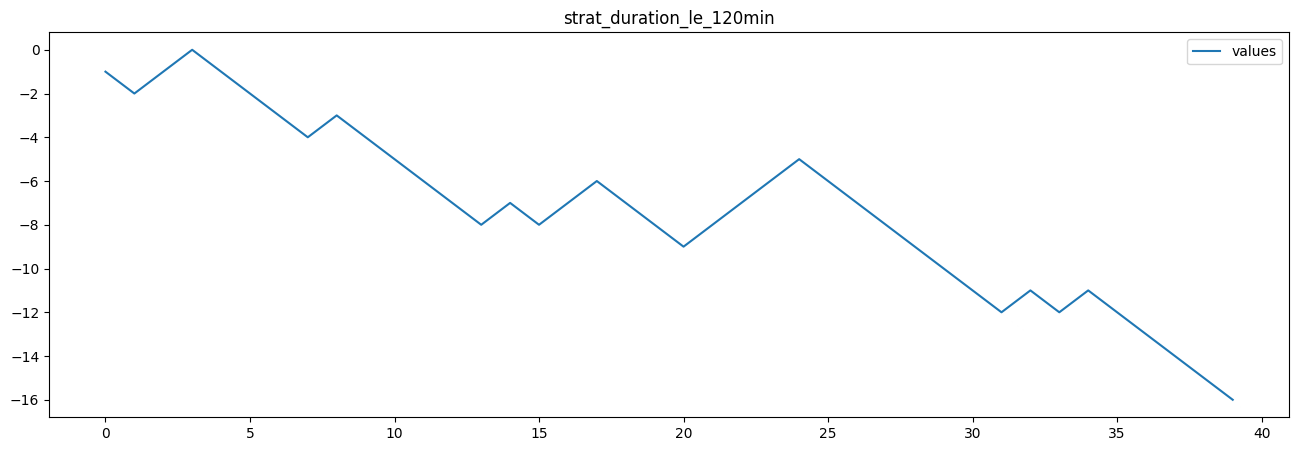

strat_duration_ge_180min


<Figure size 1600x500 with 0 Axes>

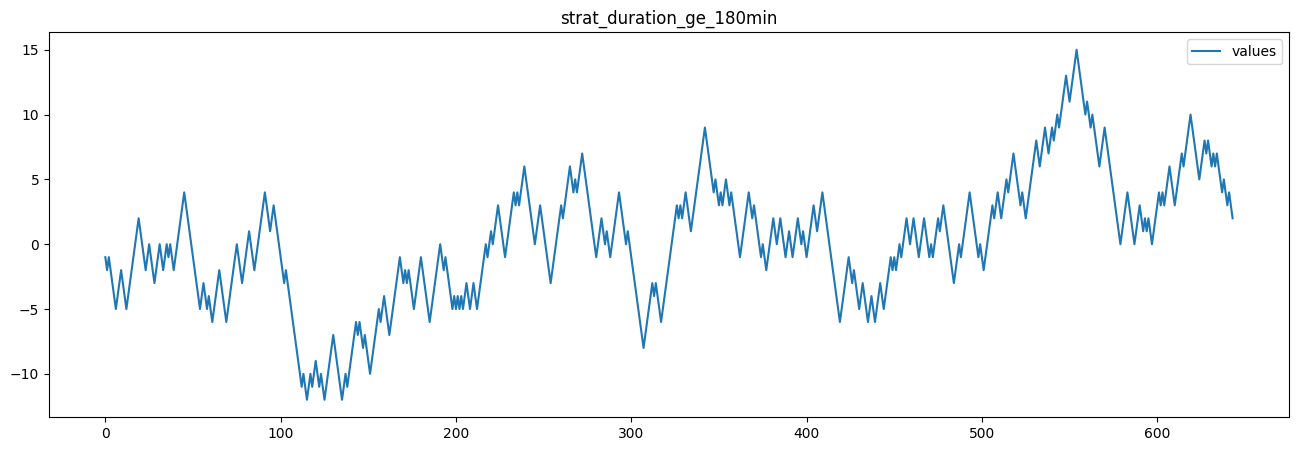

strat_duration_60_180min


<Figure size 1600x500 with 0 Axes>

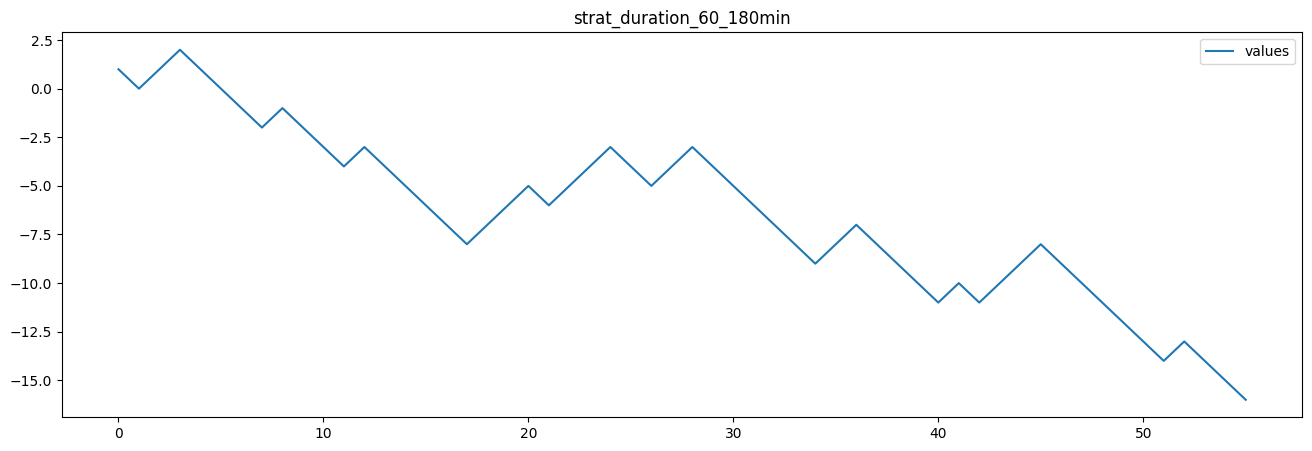

strat_stop_pips_le_8


<Figure size 1600x500 with 0 Axes>

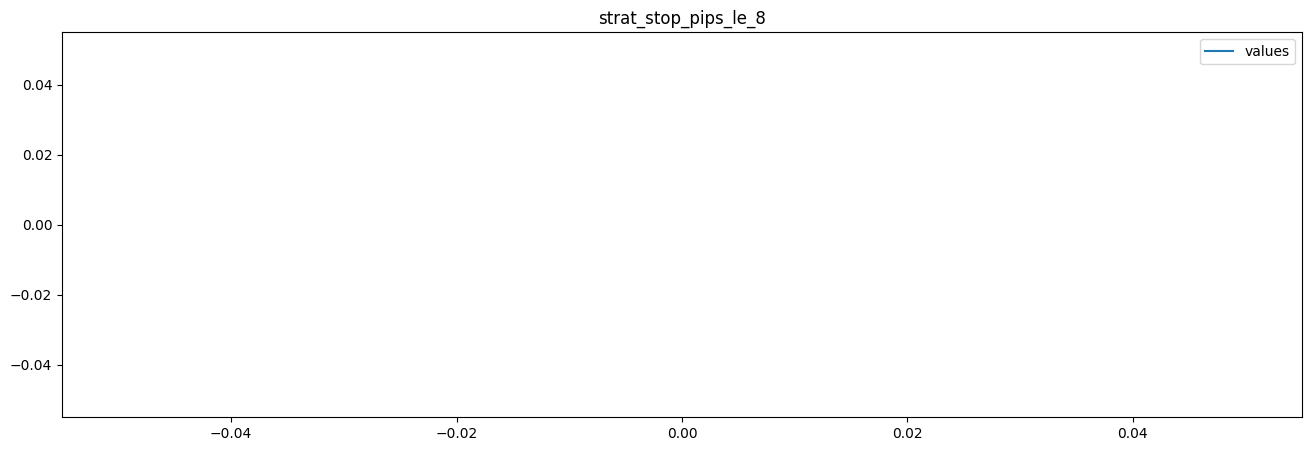

strat_stop_pips_le_10


<Figure size 1600x500 with 0 Axes>

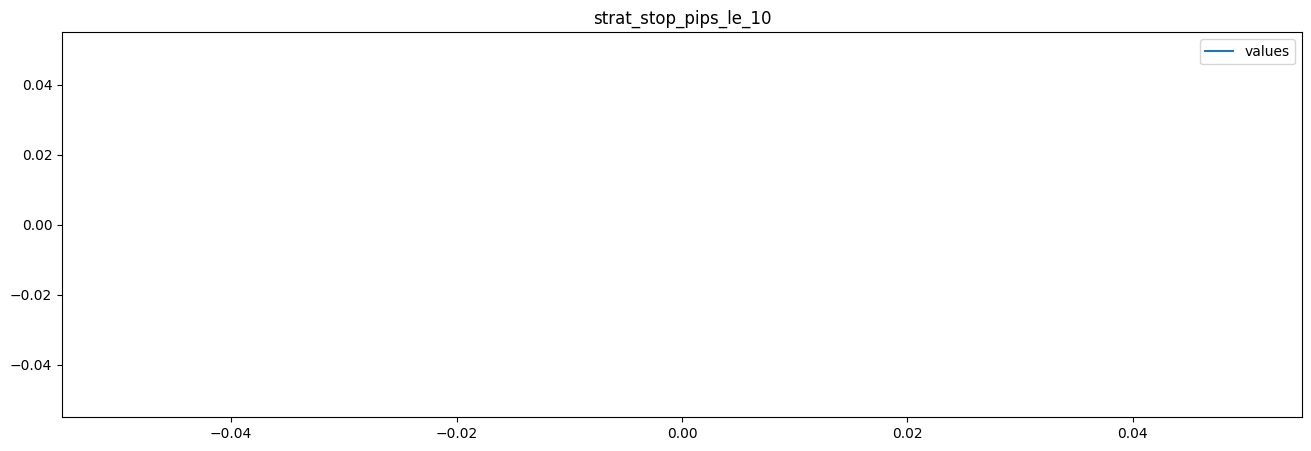

strat_stop_pips_10_15


<Figure size 1600x500 with 0 Axes>

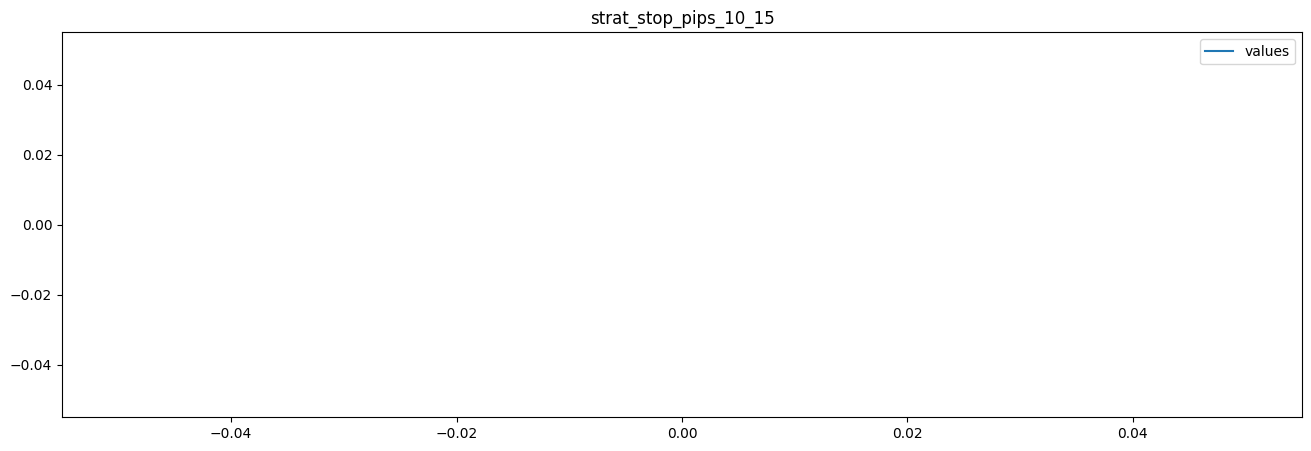

strat_stop_pips_ge_15


<Figure size 1600x500 with 0 Axes>

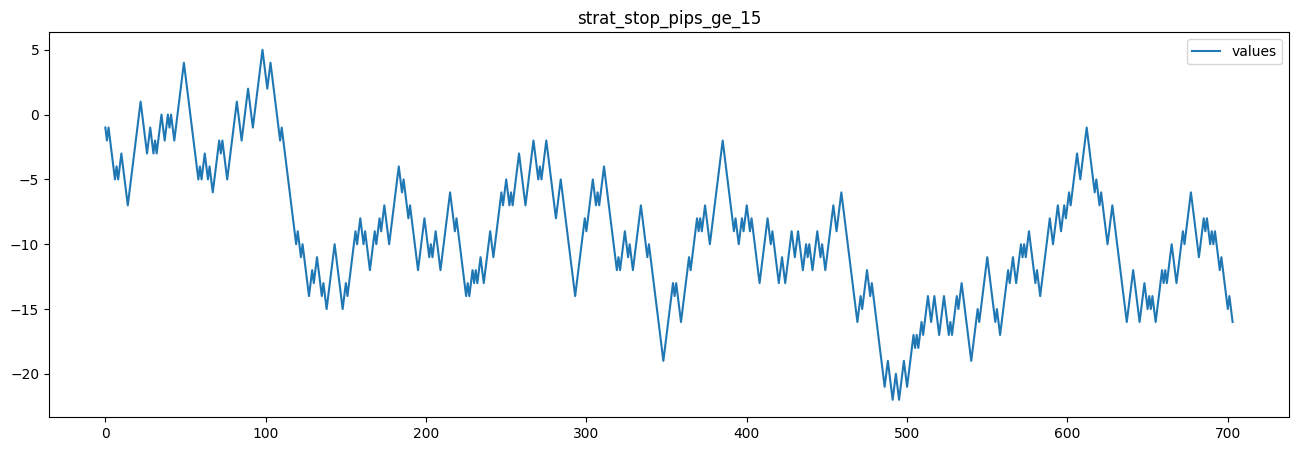

strat_roll3_winrate_ge_0_66


<Figure size 1600x500 with 0 Axes>

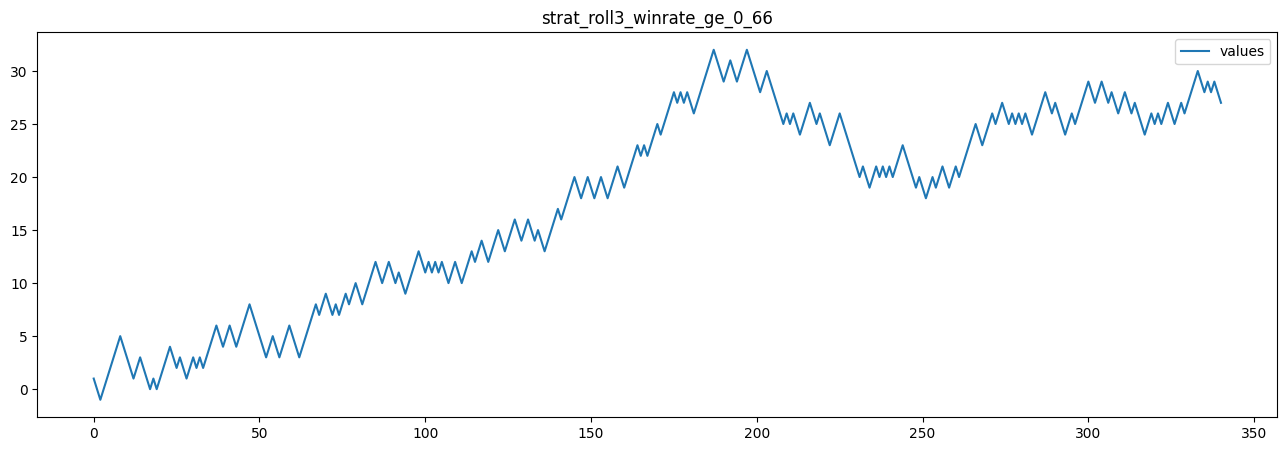

strat_roll5_winrate_ge_0_60


<Figure size 1600x500 with 0 Axes>

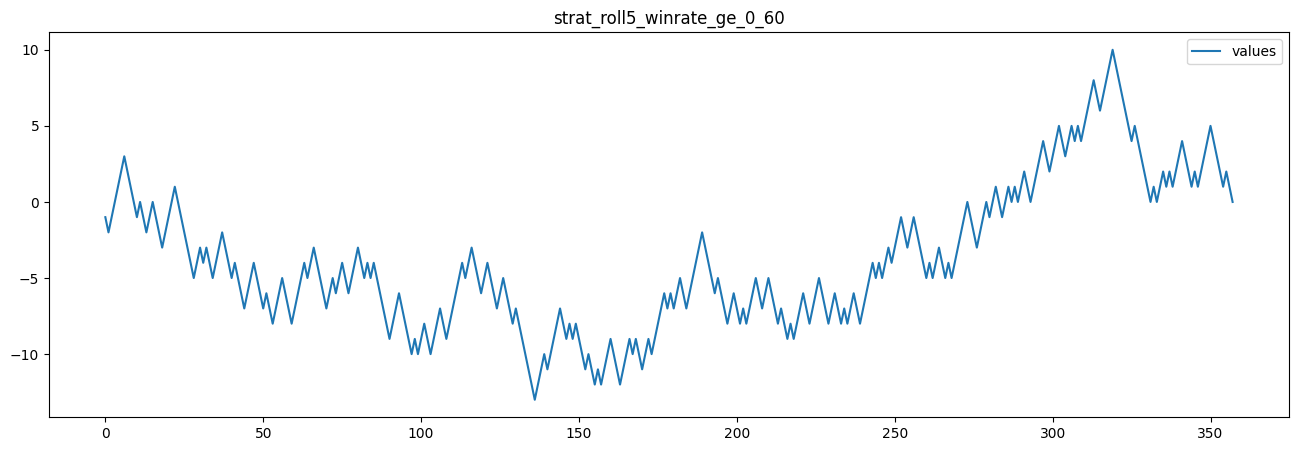

strat_roll10_winrate_ge_0_60


<Figure size 1600x500 with 0 Axes>

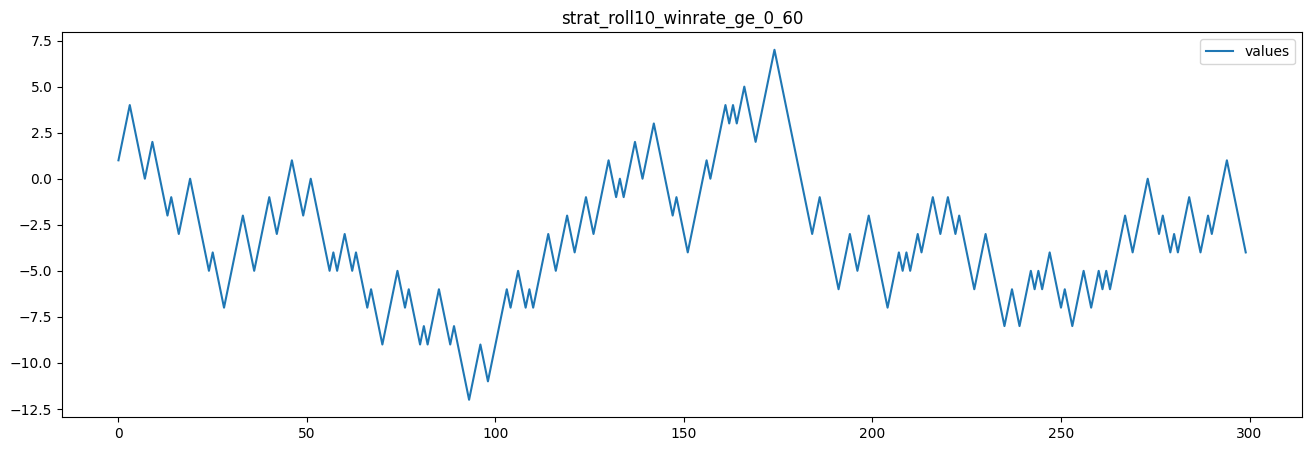

strat_roll5_winrate_le_0_40


<Figure size 1600x500 with 0 Axes>

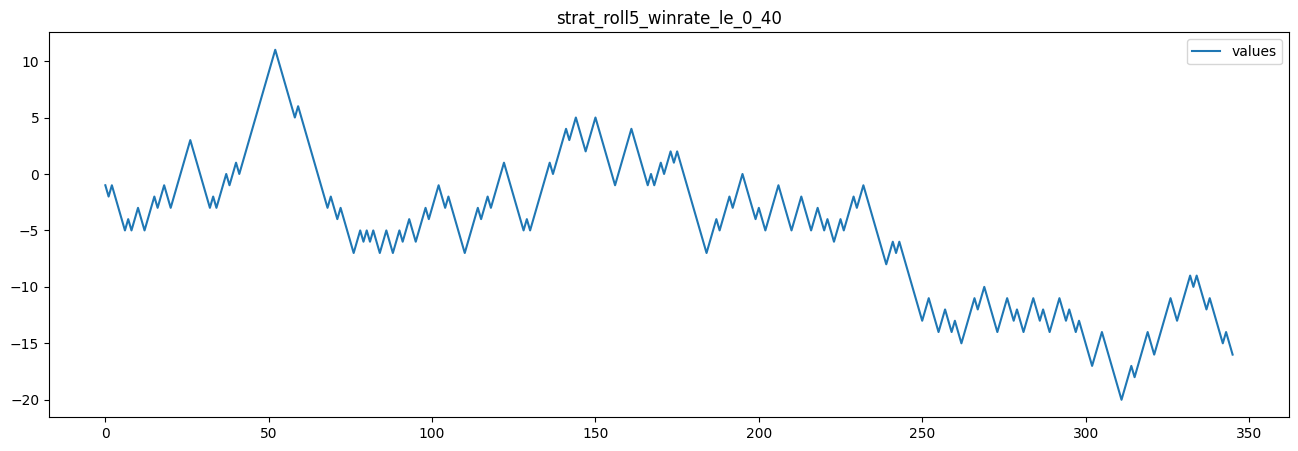

strat_only_buy


<Figure size 1600x500 with 0 Axes>

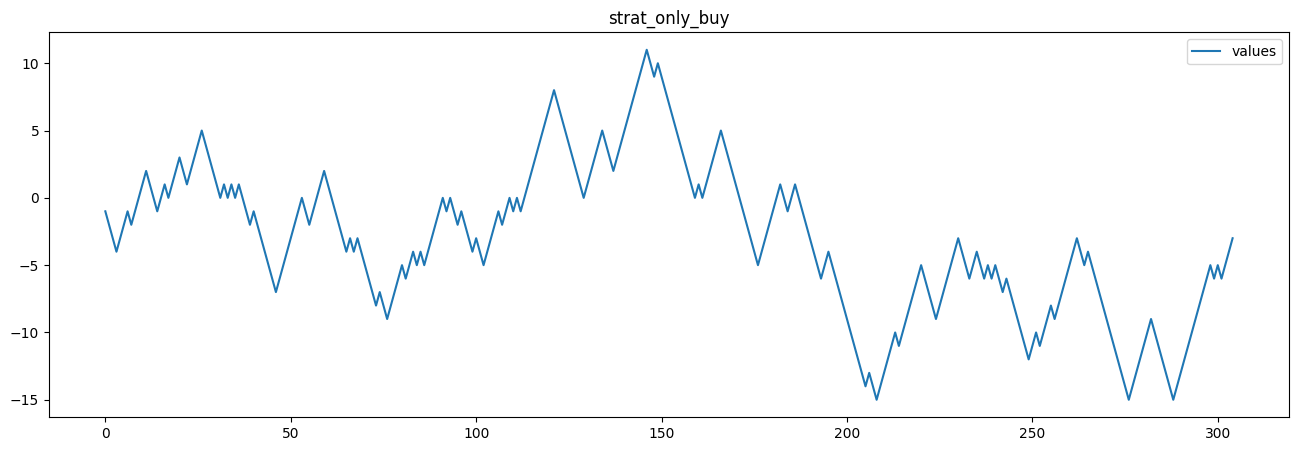

strat_only_sell


<Figure size 1600x500 with 0 Axes>

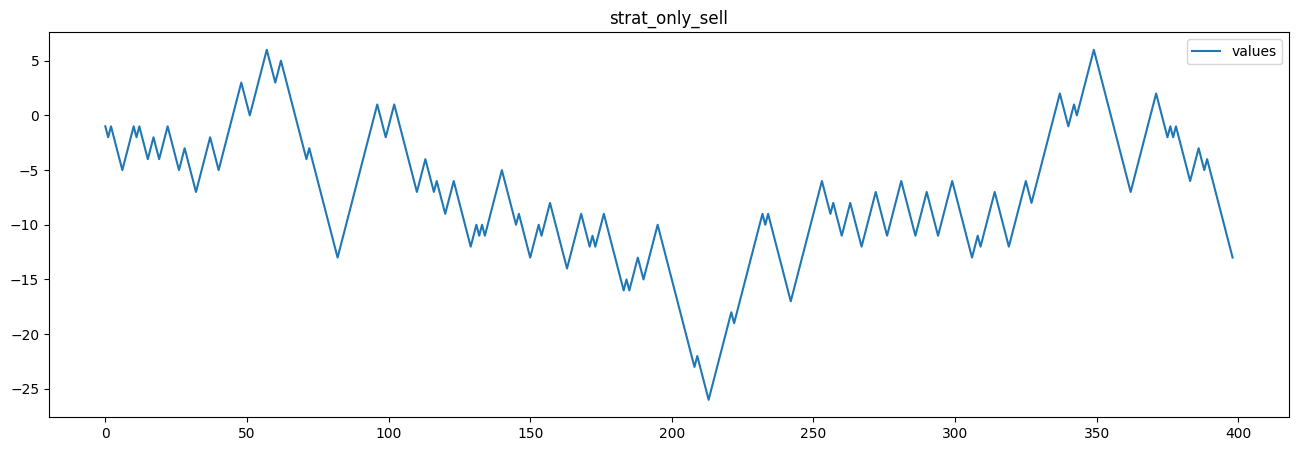

strat_alternate_direction


<Figure size 1600x500 with 0 Axes>

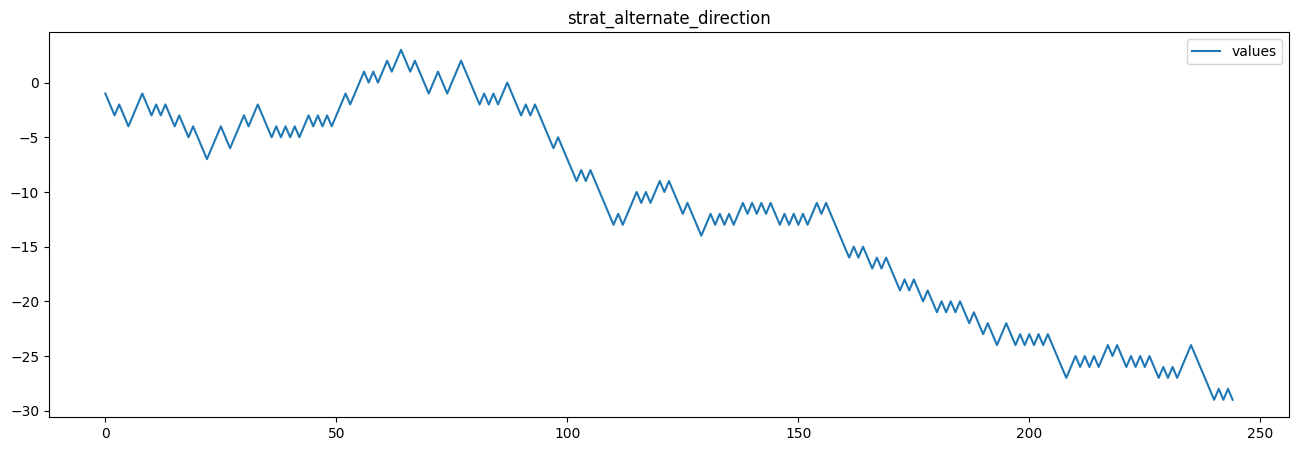

strat_reversal_after_buy_streak_ge_2


<Figure size 1600x500 with 0 Axes>

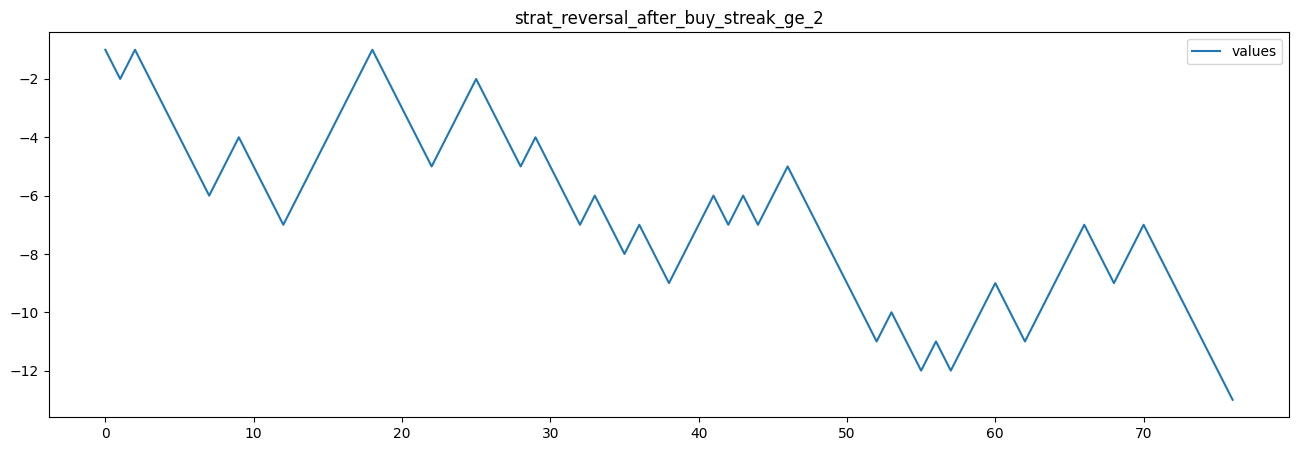

strat_reversal_after_sell_streak_ge_2


<Figure size 1600x500 with 0 Axes>

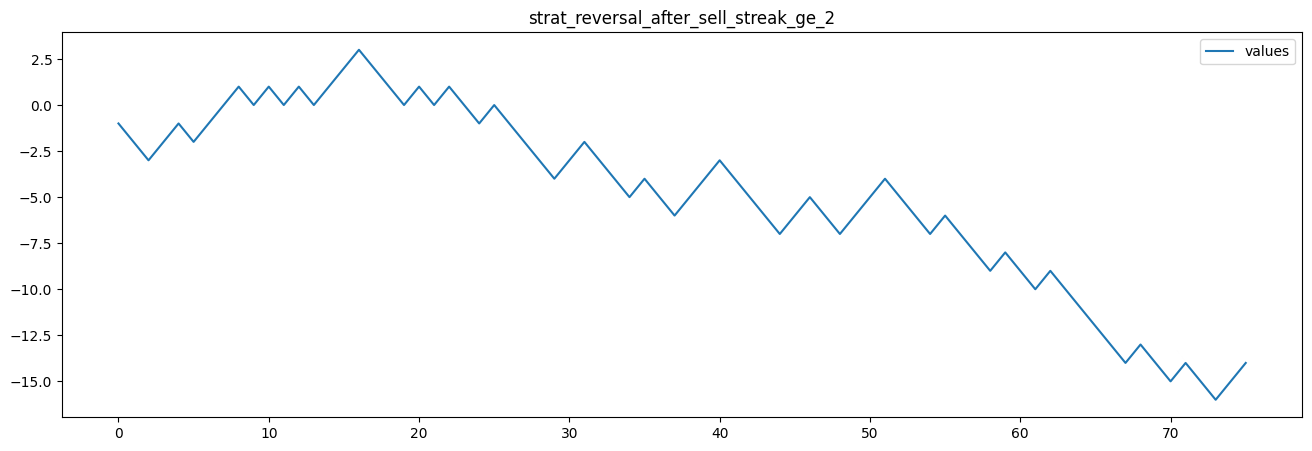

strat_london_and_conc_le_2


<Figure size 1600x500 with 0 Axes>

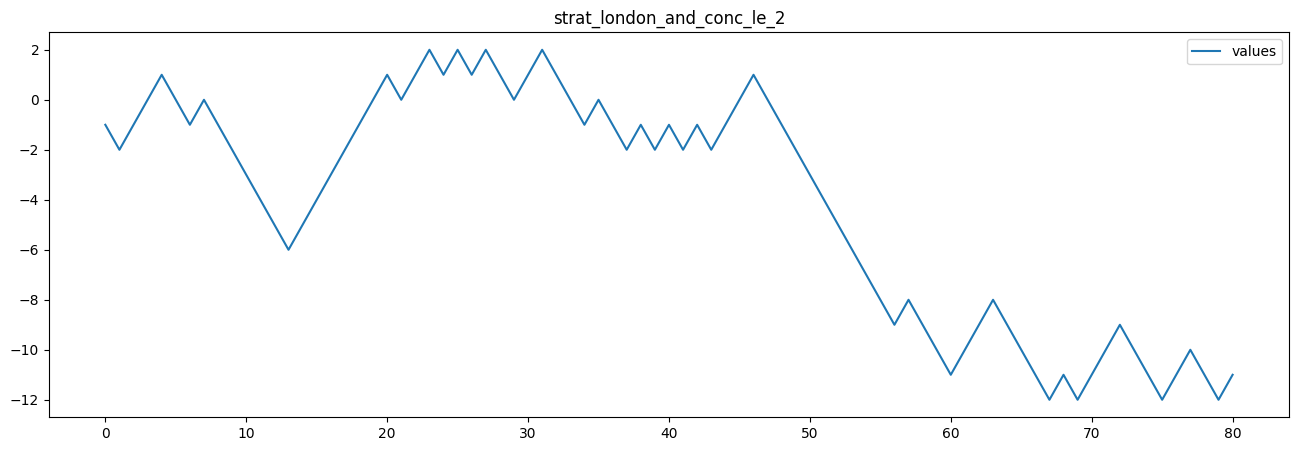

strat_london


<Figure size 1600x500 with 0 Axes>

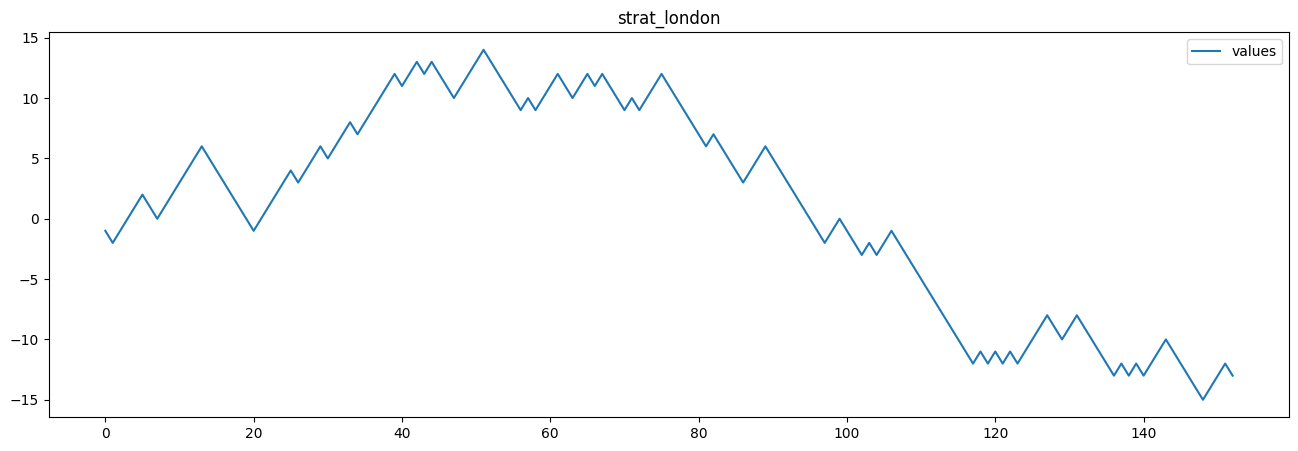

strat_newyork_and_prev_win


<Figure size 1600x500 with 0 Axes>

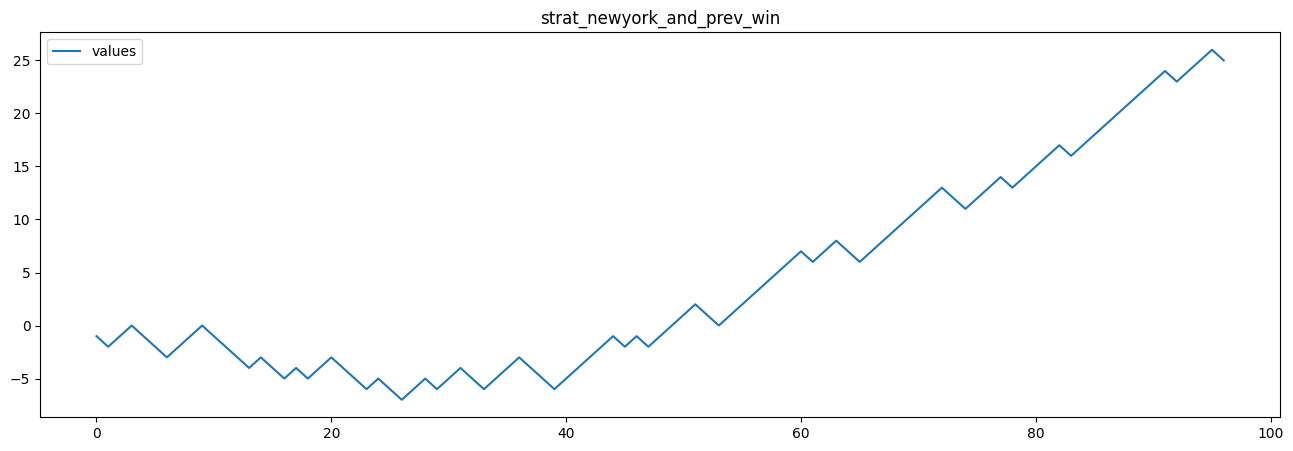

strat_early_and_prev_loss


<Figure size 1600x500 with 0 Axes>

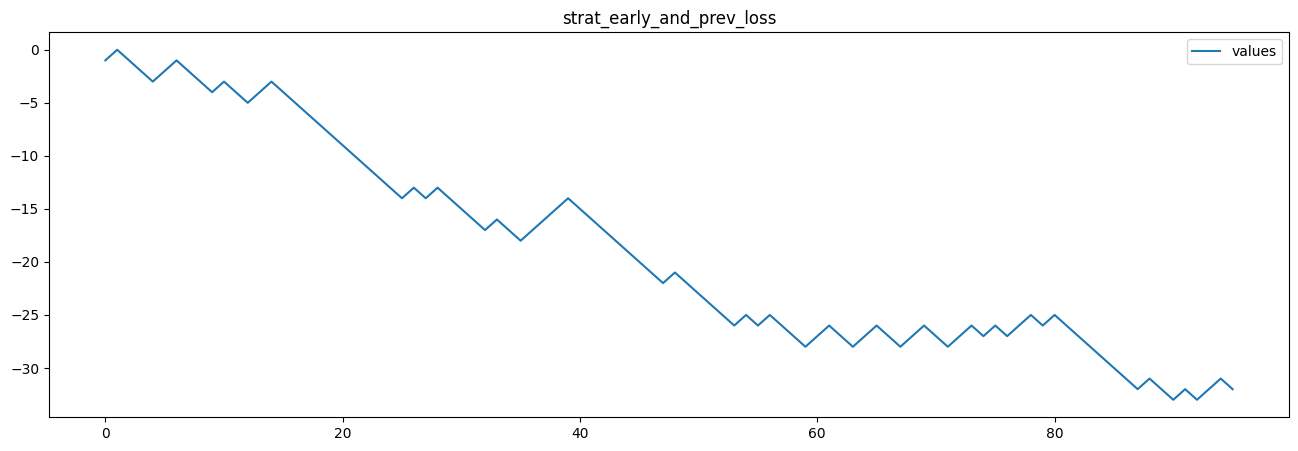

strat_duration_le_120_and_conc_le_3


<Figure size 1600x500 with 0 Axes>

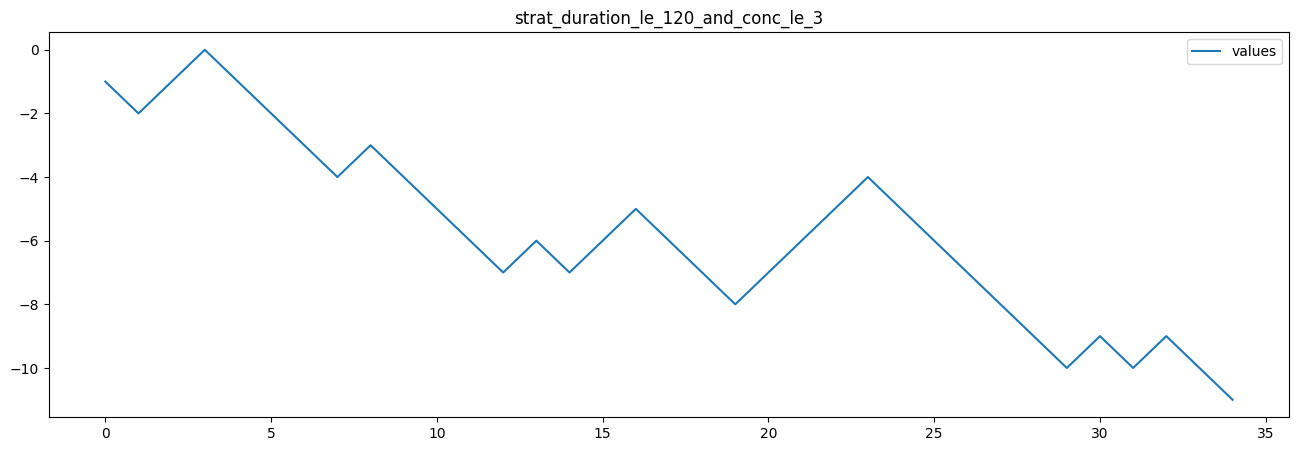

strat_stop_le_10_and_buy


<Figure size 1600x500 with 0 Axes>

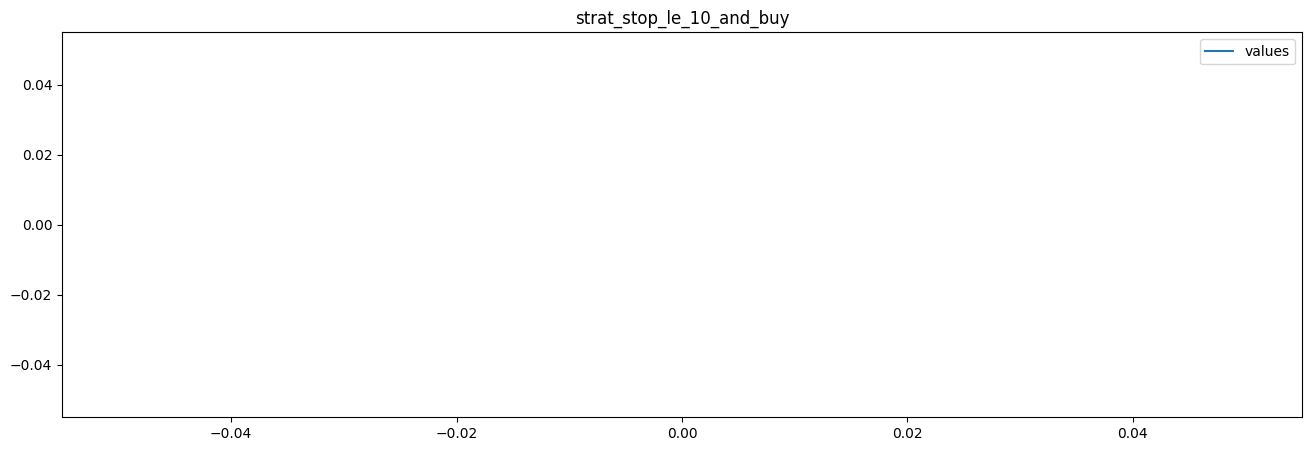

strat_stop_ge_15_and_sell


<Figure size 1600x500 with 0 Axes>

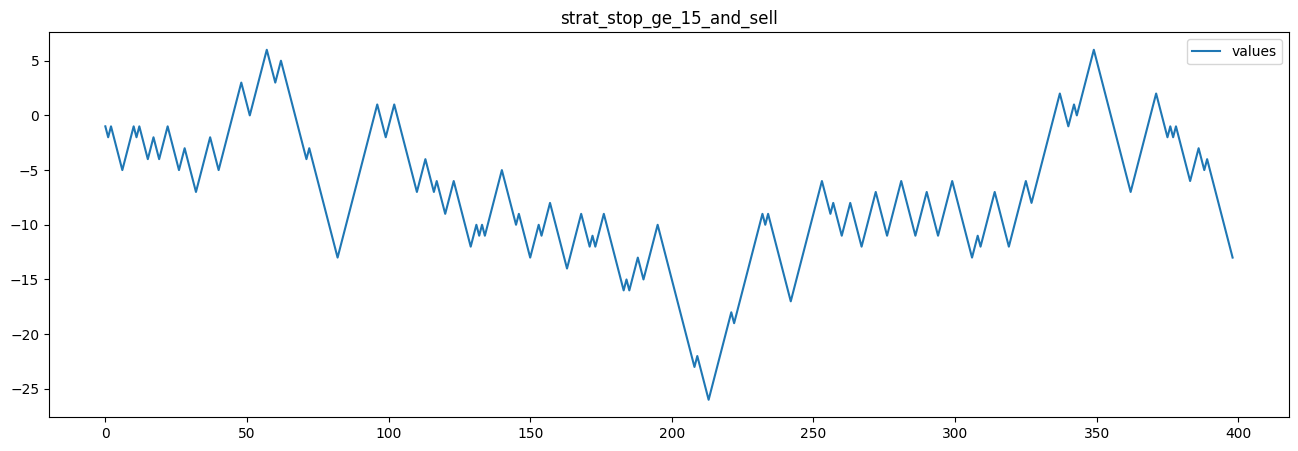

strat_prev_loss_streak_ge_2_and_reverse


<Figure size 1600x500 with 0 Axes>

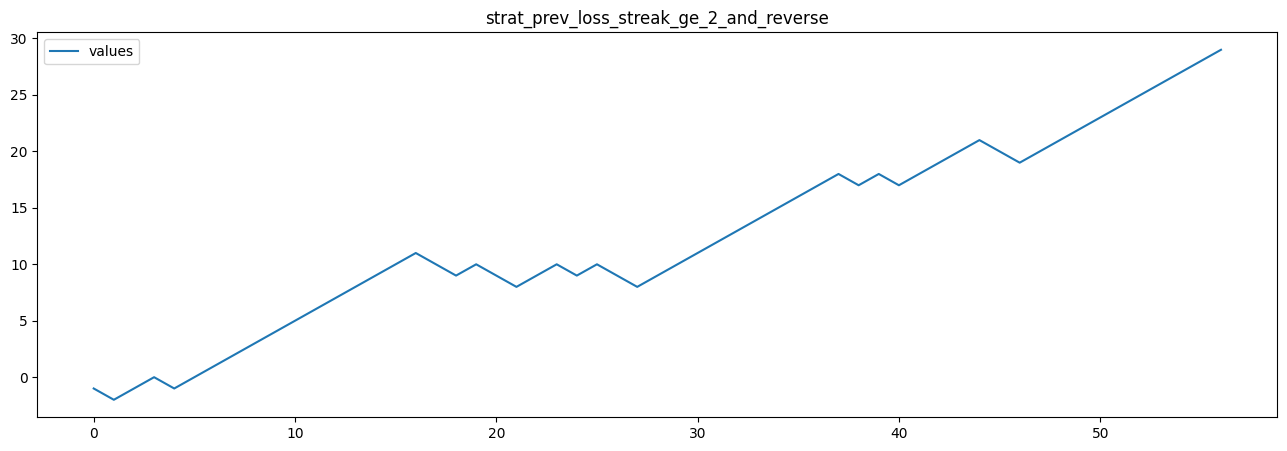

strat_prev_win_streak_ge_2_and_same_dir


<Figure size 1600x500 with 0 Axes>

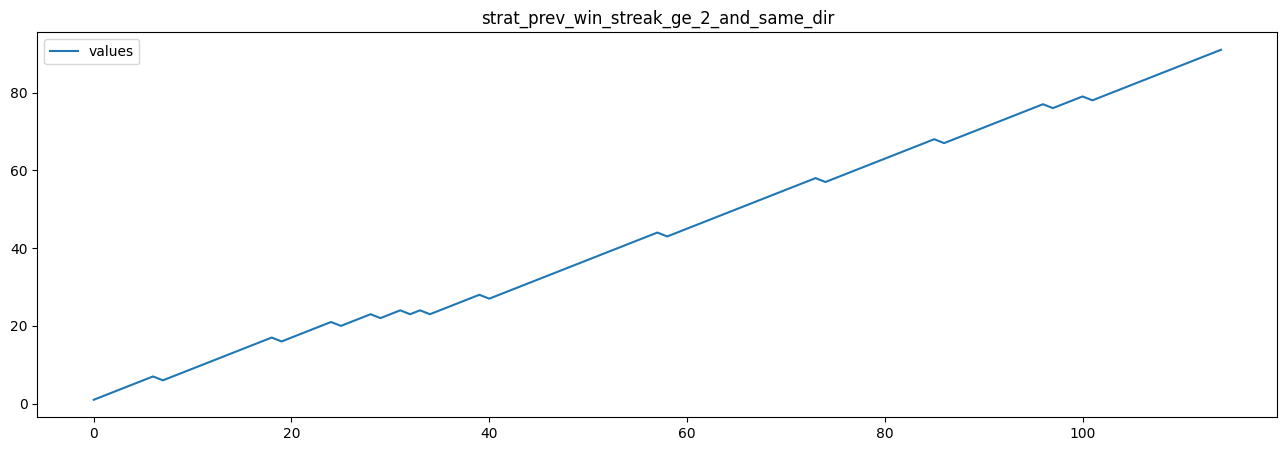

In [37]:
winning_strats = []
for key in list(trade_details_dict.keys()):
    print(key)
    plt.figure(figsize=(16, 5))
    
    df_temp = pd.DataFrame({'datetimes': trade_details_dict[key]['datetimes'], 
                            'values': trade_details_dict[key]['values']})
    df_temp.plot(figsize=(16, 5), title=key)
    
    if not df_temp.empty:
        if df_temp.iloc[-1]['values'] > 0:
            winning_strats.append(key)
    
    plt.show()

strat_concurrency_le_1


<Figure size 1600x500 with 0 Axes>

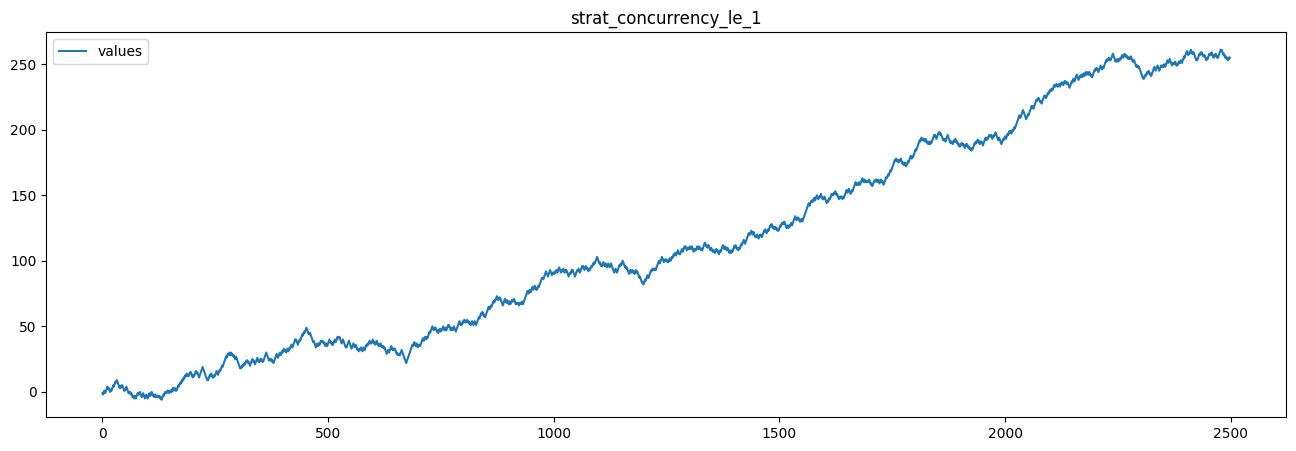

strat_concurrency_le_2


<Figure size 1600x500 with 0 Axes>

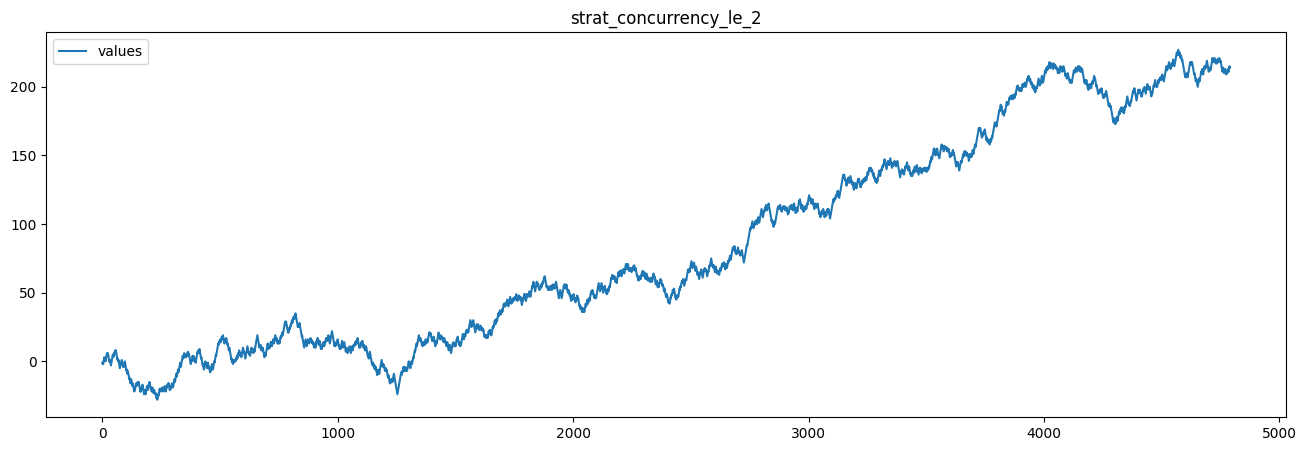

strat_concurrency_le_3


<Figure size 1600x500 with 0 Axes>

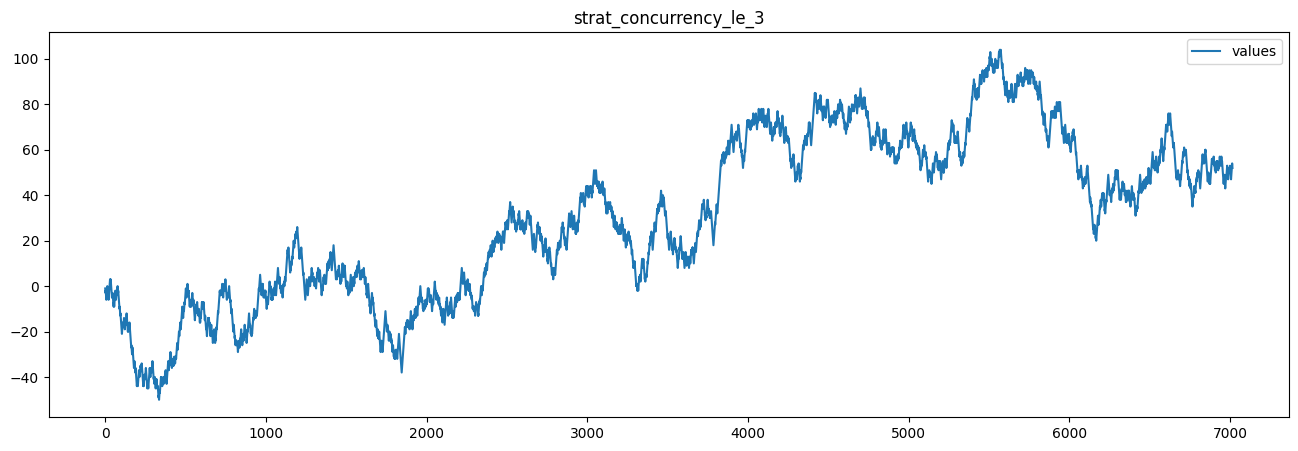

strat_prev_win_streak_ge_1


<Figure size 1600x500 with 0 Axes>

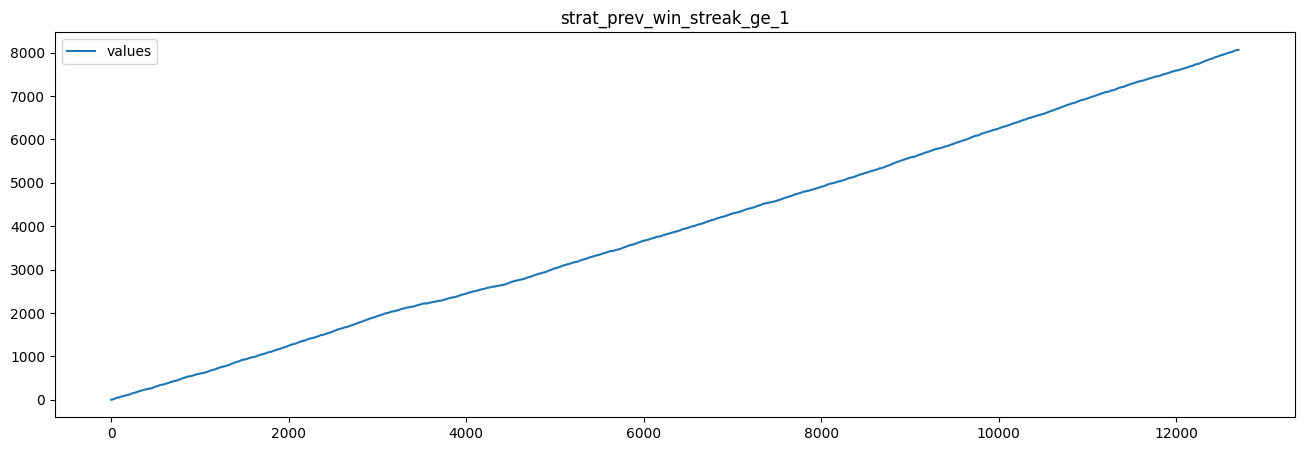

strat_prev_win_streak_ge_2


<Figure size 1600x500 with 0 Axes>

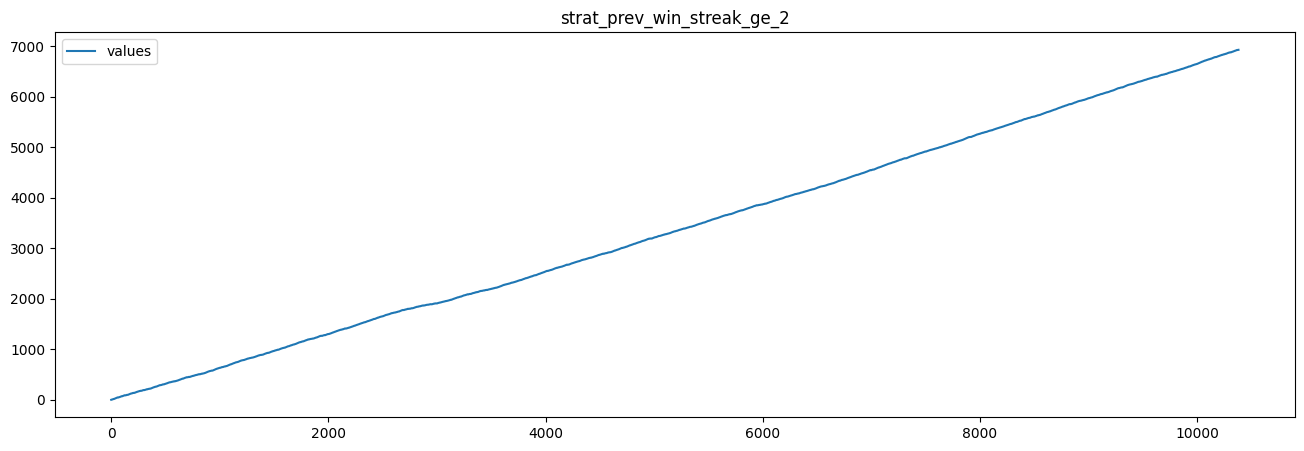

strat_prev_win_streak_ge_3


<Figure size 1600x500 with 0 Axes>

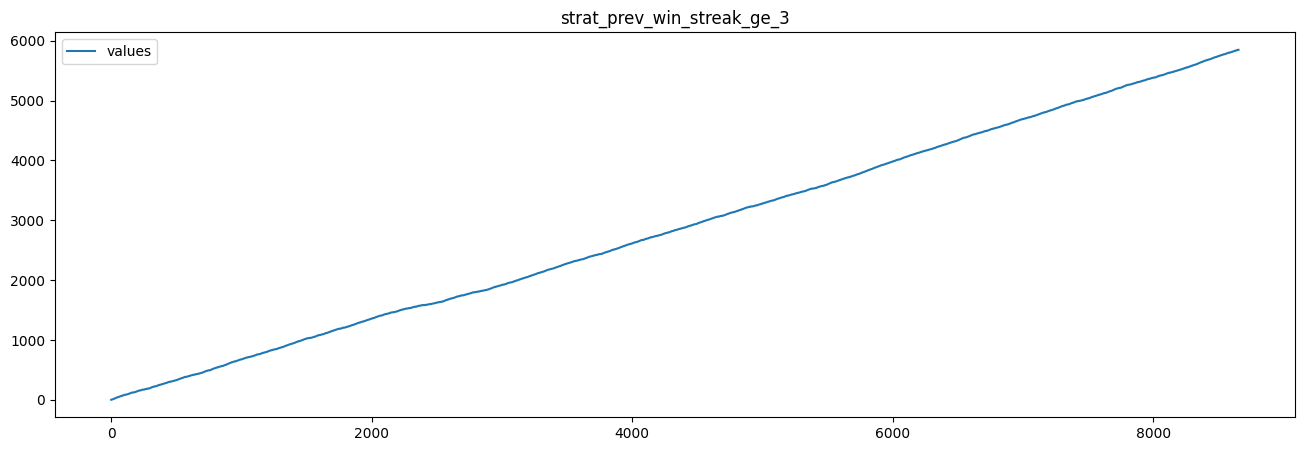

strat_prev_win_streak_ge_4


<Figure size 1600x500 with 0 Axes>

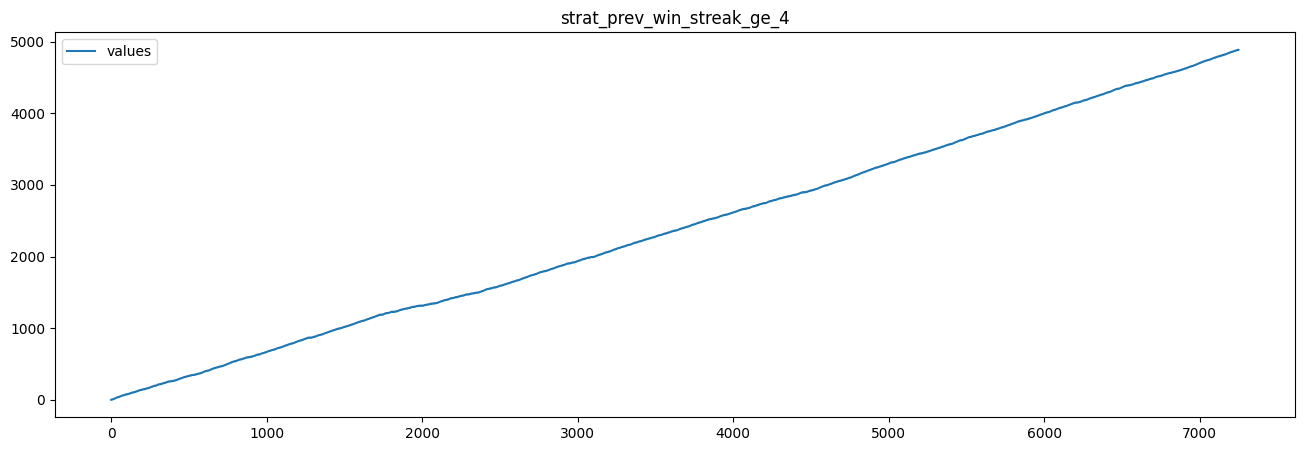

strat_prev_win_streak_ge_5


<Figure size 1600x500 with 0 Axes>

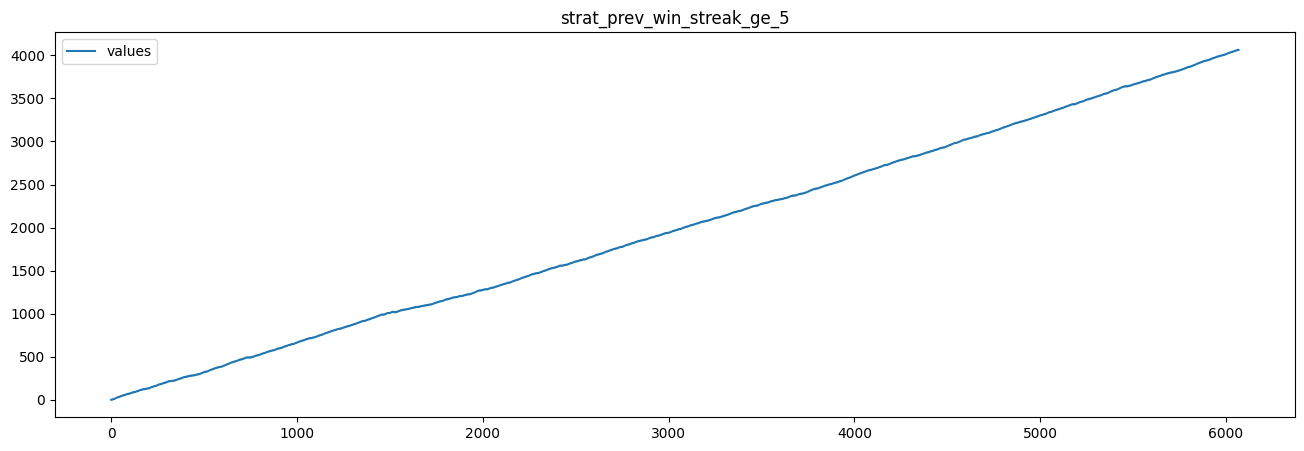

strat_prev_was_win


<Figure size 1600x500 with 0 Axes>

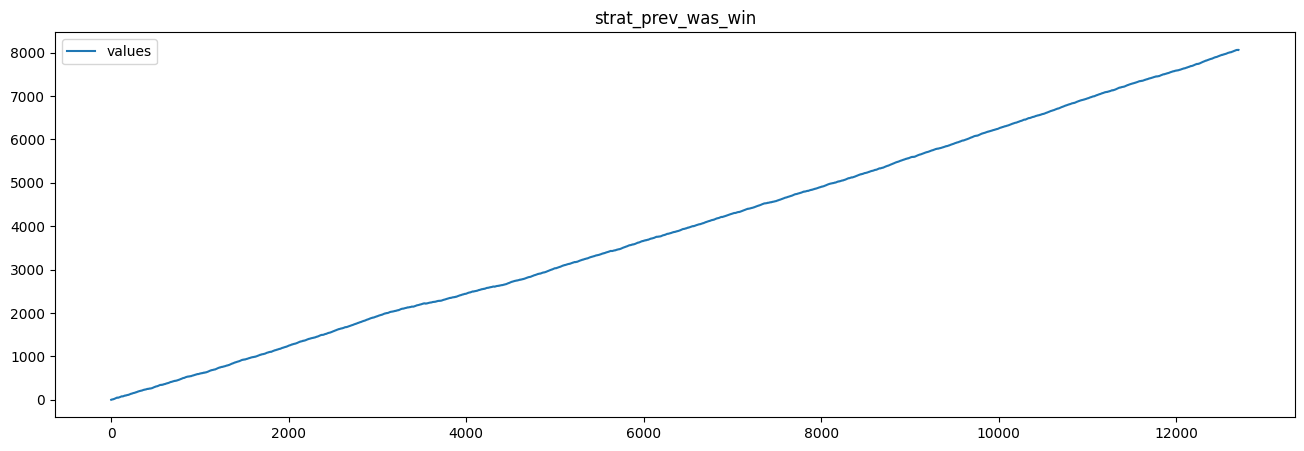

strat_prev_win_same_dir


<Figure size 1600x500 with 0 Axes>

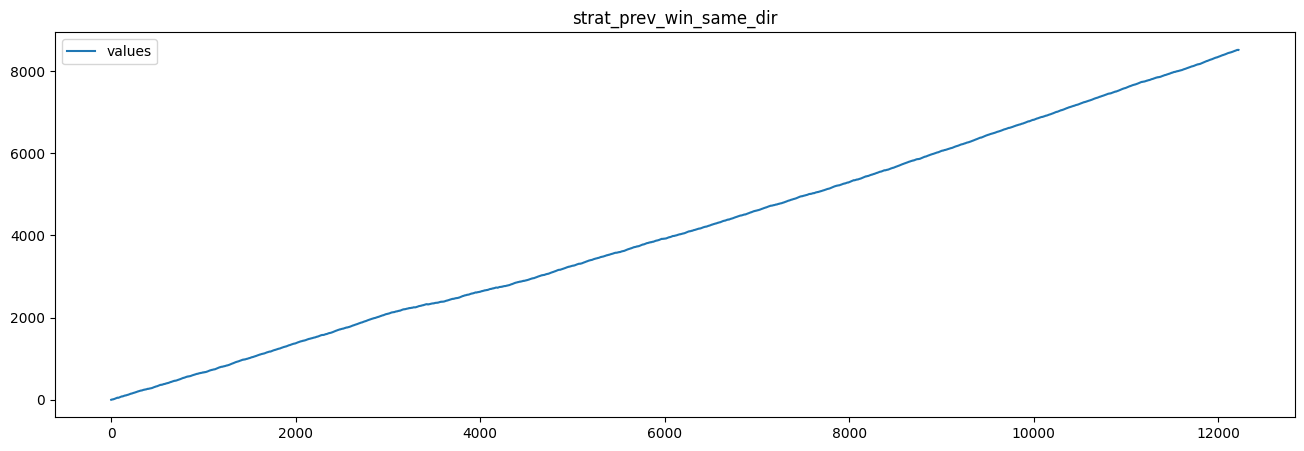

strat_prev_loss_reverse_dir


<Figure size 1600x500 with 0 Axes>

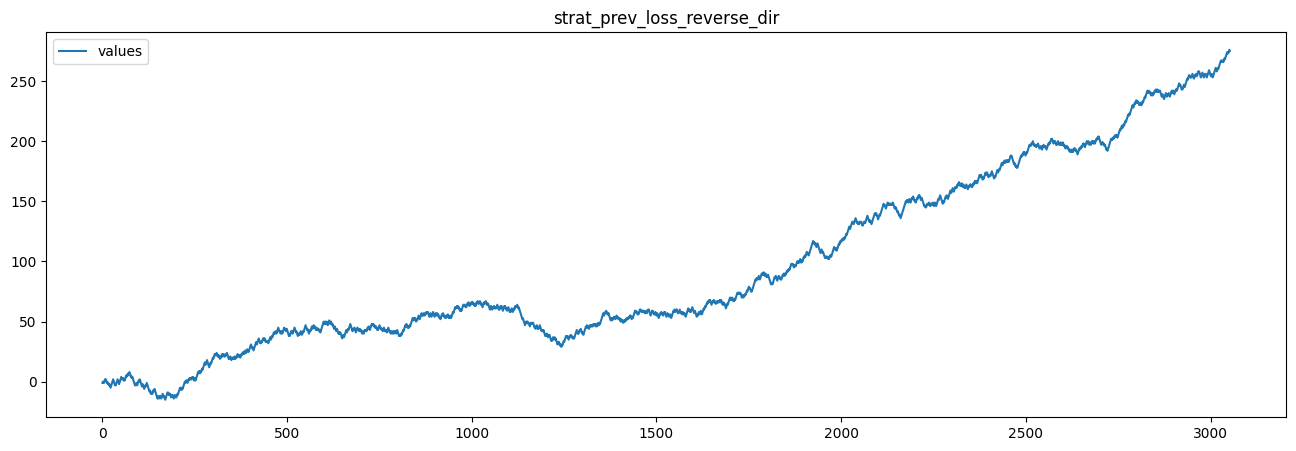

strat_roll3_winrate_ge_0_66


<Figure size 1600x500 with 0 Axes>

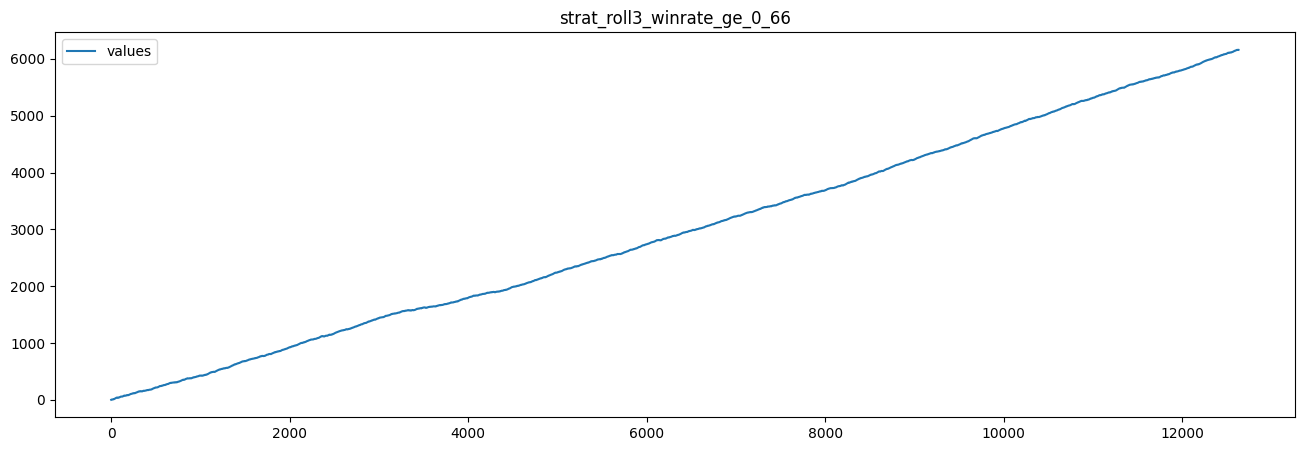

strat_roll5_winrate_ge_0_60


<Figure size 1600x500 with 0 Axes>

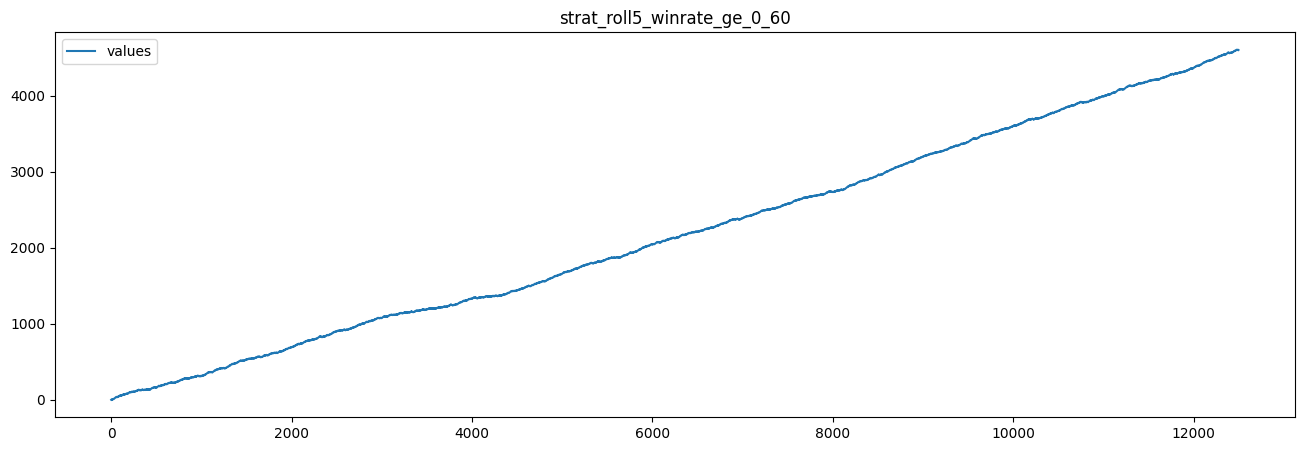

strat_roll10_winrate_ge_0_60


<Figure size 1600x500 with 0 Axes>

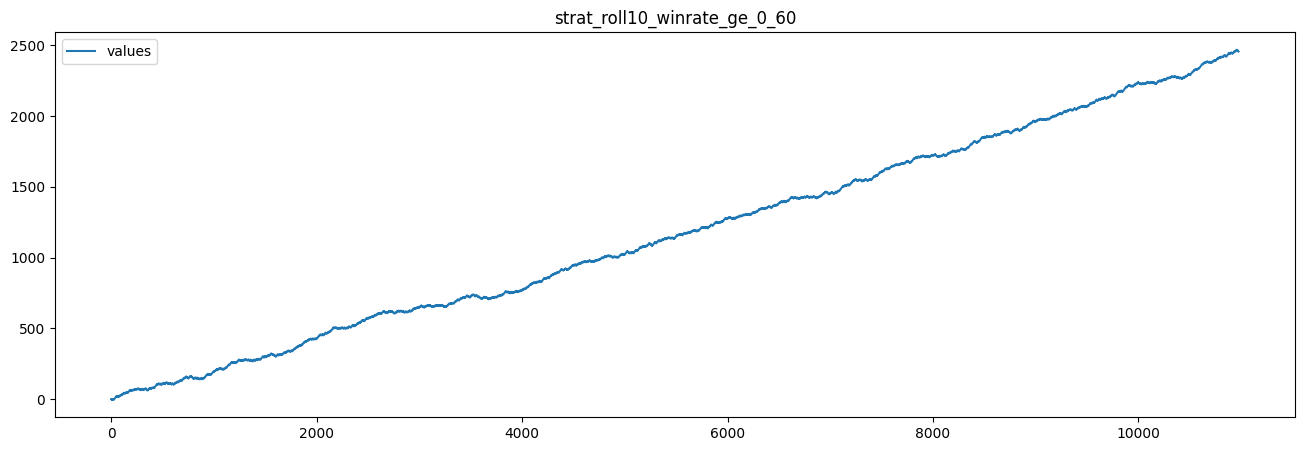

strat_london_and_conc_le_2


<Figure size 1600x500 with 0 Axes>

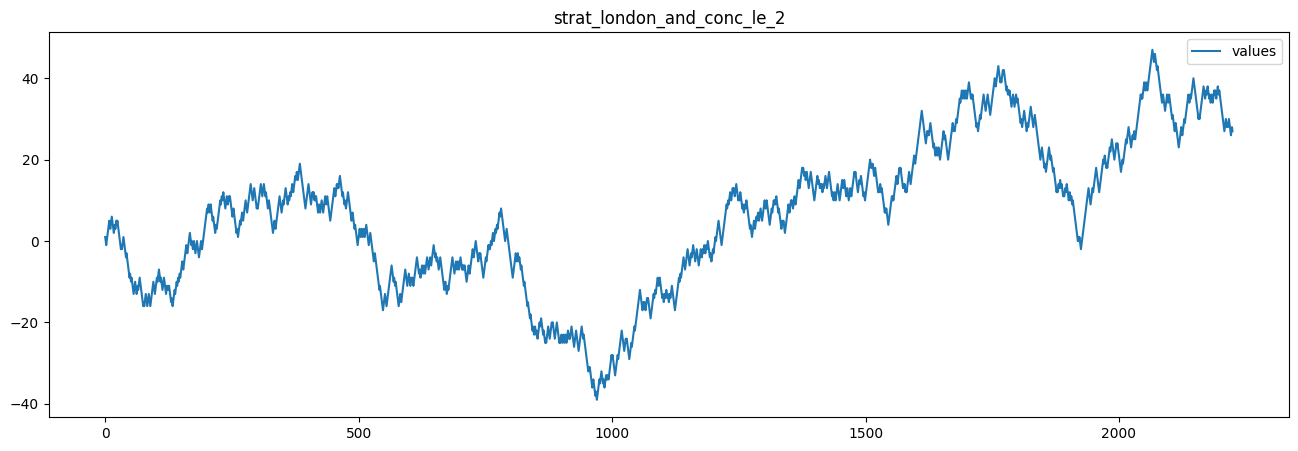

strat_newyork_and_prev_win


<Figure size 1600x500 with 0 Axes>

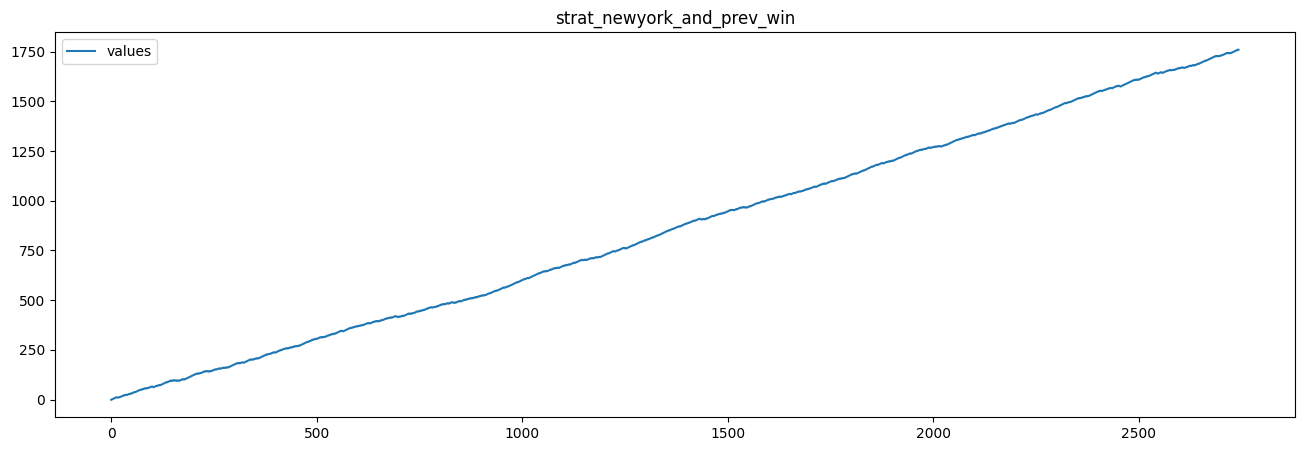

strat_duration_le_120_and_conc_le_3


<Figure size 1600x500 with 0 Axes>

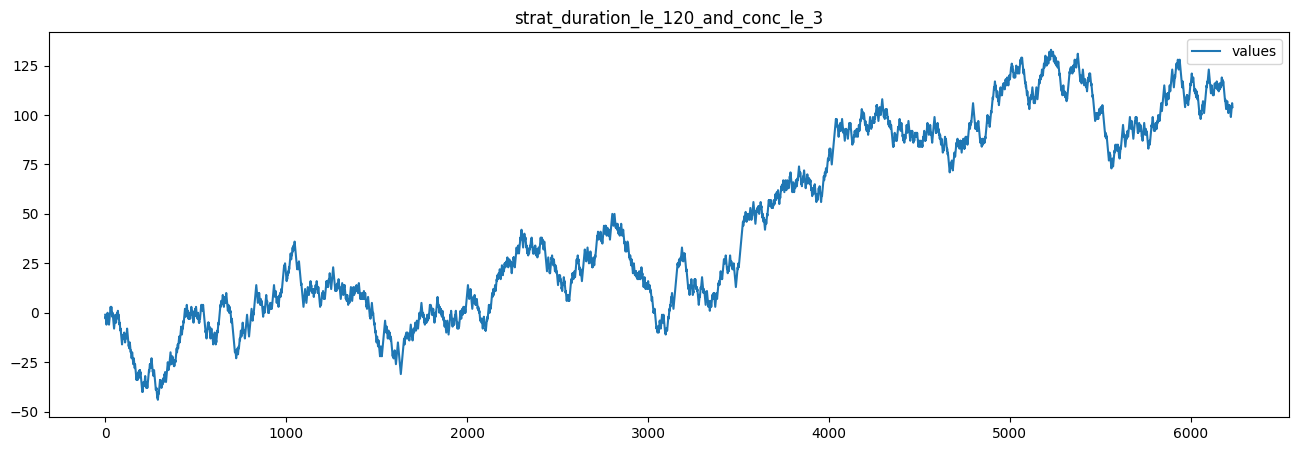

strat_prev_loss_streak_ge_2_and_reverse


<Figure size 1600x500 with 0 Axes>

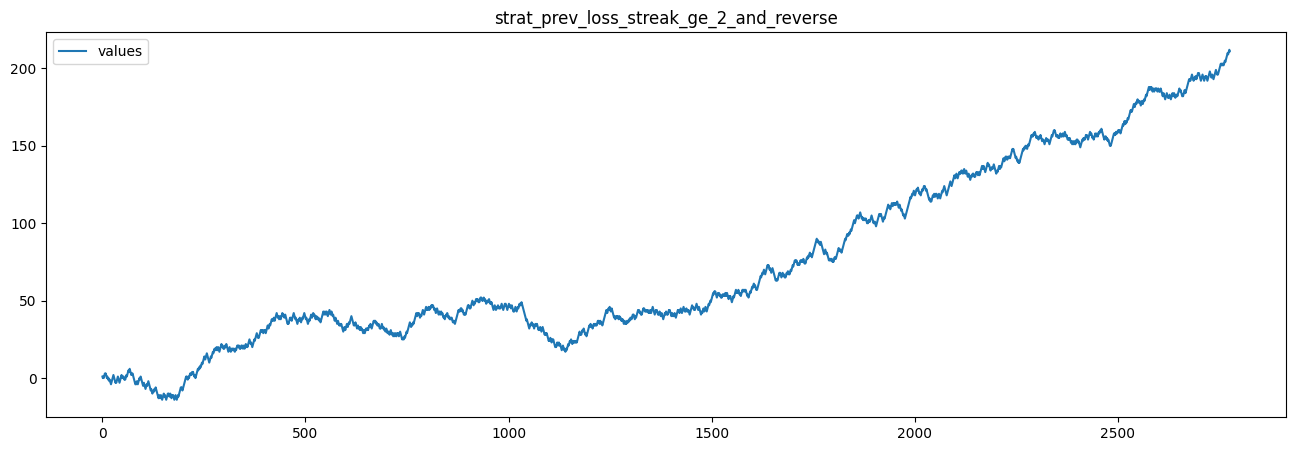

strat_prev_win_streak_ge_2_and_same_dir


<Figure size 1600x500 with 0 Axes>

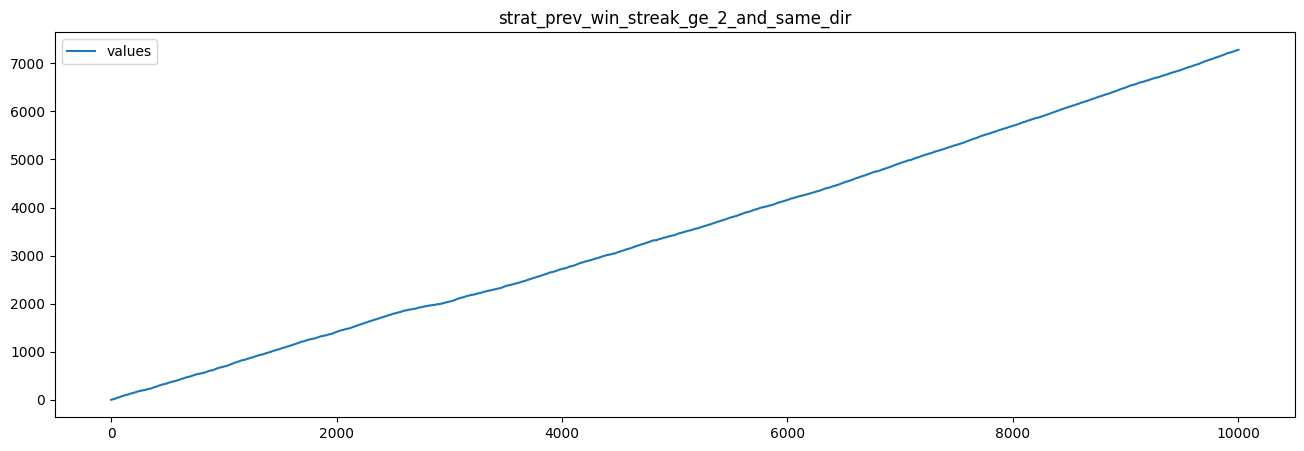

In [199]:
for key in winning_strats:
    print(key)
    plt.figure(figsize=(16, 5))
    
    df_temp = pd.DataFrame({'datetimes': trade_details_dict[key]['datetimes'], 
                            'values': trade_details_dict[key]['values']})
    df_temp.plot(figsize=(16, 5), title=key)
    
    plt.show()

In [198]:
for ii in winning_strats:
    print(ii)

strat_concurrency_le_1
strat_concurrency_le_2
strat_concurrency_le_3
strat_prev_win_streak_ge_1
strat_prev_win_streak_ge_2
strat_prev_win_streak_ge_3
strat_prev_win_streak_ge_4
strat_prev_win_streak_ge_5
strat_prev_was_win
strat_prev_win_same_dir
strat_prev_loss_reverse_dir
strat_roll3_winrate_ge_0_66
strat_roll5_winrate_ge_0_60
strat_roll10_winrate_ge_0_60
strat_london_and_conc_le_2
strat_newyork_and_prev_win
strat_duration_le_120_and_conc_le_3
strat_prev_loss_streak_ge_2_and_reverse
strat_prev_win_streak_ge_2_and_same_dir


In [84]:
for ii in winning_strats:
    print(ii)

strat_prev_win_streak_ge_1
strat_prev_win_streak_ge_2
strat_prev_win_streak_ge_3
strat_prev_win_streak_ge_4
strat_prev_win_streak_ge_5
strat_prev_was_win
strat_prev_win_same_dir
strat_prev_loss_reverse_dir
strat_roll3_winrate_ge_0_66
strat_roll5_winrate_ge_0_60
strat_roll10_winrate_ge_0_60
strat_newyork_and_prev_win
strat_prev_loss_streak_ge_2_and_reverse
strat_prev_win_streak_ge_2_and_same_dir


In [ ]:
"""strat_concurrency_le_1
strat_concurrency_le_2
strat_concurrency_le_3
strat_london_and_conc_le_2
strat_duration_le_120_and_conc_le_3"""

Try creating new strategies that avoid "future knowledge"

In [38]:
# No-future-knowledge strategy masks: consecutive direction within N candles
import numpy as np
import pandas as pd

_df = trade_details.copy()
_df['entry_dt'] = pd.to_datetime(_df['entry_time'])
_df.sort_values('entry_dt', inplace=True)
_df['entry_hour'] = _df['entry_dt'].dt.hour

# Infer candle duration from median gap between entries (fallback to 300s = 5m)
_entry_gap_sec = (_df['entry_dt'] - _df['entry_dt'].shift(1)).dt.total_seconds()
candle_sec = int(np.nanmedian(_entry_gap_sec)) if np.isfinite(np.nanmedian(_entry_gap_sec)) else 300
if candle_sec <= 0 or np.isnan(candle_sec):
    candle_sec = 300

_prev_dir = _df['direction'].shift(1)
_prev_entry_gap_sec = _entry_gap_sec.fillna(np.inf)

# Optional existing run-length columns are direction-only derived (no outcome dependency)
buy_run = _df.get('consequtive_buys', pd.Series(0, index=_df.index))
sell_run = _df.get('consequtive_sells', pd.Series(0, index=_df.index))

_to_int = lambda s: s.astype(int)
strategies_nf = {}

# 1) Two consecutive BUY within N candles (N = 1..5)
for n in range(1, 6):
    strategies_nf[f'strat_two_consecutive_buys_within_{n}c'] = _to_int(
        (_df['direction'] == 'BUY') & (_prev_dir == 'BUY') & (_prev_entry_gap_sec <= n * candle_sec)
    )

# 2) Two consecutive SELL within N candles (N = 1..5)
for n in range(1, 6):
    strategies_nf[f'strat_two_consecutive_sells_within_{n}c'] = _to_int(
        (_df['direction'] == 'SELL') & (_prev_dir == 'SELL') & (_prev_entry_gap_sec <= n * candle_sec)
    )

# 3) Two consecutive same-direction (BUY or SELL) within N candles (N = 1..5)
for n in range(1, 6):
    strategies_nf[f'strat_two_consecutive_same_dir_within_{n}c'] = _to_int(
        (_df['direction'] == _prev_dir) & (_prev_dir.isin(['BUY', 'SELL'])) & (_prev_entry_gap_sec <= n * candle_sec)
    )

# 4) Direction flip (reversal) within N candles (N = 1..5)
for n in range(1, 6):
    strategies_nf[f'strat_direction_flip_within_{n}c'] = _to_int(
        (_df['direction'] != _prev_dir) & (_prev_dir.isin(['BUY', 'SELL'])) & (_prev_entry_gap_sec <= n * candle_sec)
    )

# 5) Run-length gates (no time window)
strategies_nf['strat_buy_run_ge_2'] = _to_int((buy_run >= 2) & (_df['direction'] == 'BUY'))
strategies_nf['strat_sell_run_ge_2'] = _to_int((sell_run >= 2) & (_df['direction'] == 'SELL'))

# 6) Run-length gates with time proximity (<= 5 candles)
strategies_nf['strat_buy_run_ge_2_within_5c'] = _to_int((buy_run >= 2) & (_df['direction'] == 'BUY') & (_prev_entry_gap_sec <= 5 * candle_sec))
strategies_nf['strat_sell_run_ge_2_within_5c'] = _to_int((sell_run >= 2) & (_df['direction'] == 'SELL') & (_prev_entry_gap_sec <= 5 * candle_sec))

# 7) Session + direction (still no future knowledge)
strategies_nf['strat_london_buy'] = _to_int(_df['entry_hour'].between(7, 12) & (_df['direction'] == 'BUY'))
strategies_nf['strat_newyork_sell'] = _to_int(_df['entry_hour'].between(13, 18) & (_df['direction'] == 'SELL'))

# Assemble analysis dataframe
trade_details_analysis_nf = pd.DataFrame(strategies_nf, index=_df.index)
print(f"Inferred candle_sec: {candle_sec}s")
print(trade_details_analysis_nf.columns.tolist())
trade_details_analysis_nf.head()

# Optional: quick evaluation summary by win rate (uses outcomes for evaluation only)
strategy_eval_nf = []
for col in trade_details_analysis_nf.columns:
    selected = _df.loc[trade_details_analysis_nf[col] == 1, 'win/loss']
    count = int(selected.shape[0])
    winrate = float(selected.mean()) if count > 0 else np.nan
    strategy_eval_nf.append({
        'strategy': col,
        'selected_trades': count,
        'winrate': winrate
    })

strategy_eval_nf = pd.DataFrame(strategy_eval_nf).sort_values(['winrate', 'selected_trades'], ascending=[False, False])
strategy_eval_nf

Inferred candle_sec: 17700s
['strat_two_consecutive_buys_within_1c', 'strat_two_consecutive_buys_within_2c', 'strat_two_consecutive_buys_within_3c', 'strat_two_consecutive_buys_within_4c', 'strat_two_consecutive_buys_within_5c', 'strat_two_consecutive_sells_within_1c', 'strat_two_consecutive_sells_within_2c', 'strat_two_consecutive_sells_within_3c', 'strat_two_consecutive_sells_within_4c', 'strat_two_consecutive_sells_within_5c', 'strat_two_consecutive_same_dir_within_1c', 'strat_two_consecutive_same_dir_within_2c', 'strat_two_consecutive_same_dir_within_3c', 'strat_two_consecutive_same_dir_within_4c', 'strat_two_consecutive_same_dir_within_5c', 'strat_direction_flip_within_1c', 'strat_direction_flip_within_2c', 'strat_direction_flip_within_3c', 'strat_direction_flip_within_4c', 'strat_direction_flip_within_5c', 'strat_buy_run_ge_2', 'strat_sell_run_ge_2', 'strat_buy_run_ge_2_within_5c', 'strat_sell_run_ge_2_within_5c', 'strat_london_buy', 'strat_newyork_sell']


,strategy,selected_trades,winrate
5,strat_two_consecutive_sells_within_1c,171,0.555556
6,strat_two_consecutive_sells_within_2c,209,0.535885
7,strat_two_consecutive_sells_within_3c,229,0.532751
8,strat_two_consecutive_sells_within_4c,240,0.529167
11,strat_two_consecutive_same_dir_within_2c,353,0.521246
10,strat_two_consecutive_same_dir_within_1c,294,0.520408
13,strat_two_consecutive_same_dir_within_4c,400,0.520000
12,strat_two_consecutive_same_dir_within_3c,382,0.518325
9,strat_two_consecutive_sells_within_5c,251,0.517928
23,strat_sell_run_ge_2_within_5c,251,0.517928


strat_two_consecutive_buys_within_1c
strat_two_consecutive_buys_within_2c
strat_two_consecutive_buys_within_3c
strat_two_consecutive_buys_within_4c
strat_two_consecutive_buys_within_5c
strat_two_consecutive_sells_within_1c
strat_two_consecutive_sells_within_2c
strat_two_consecutive_sells_within_3c
strat_two_consecutive_sells_within_4c
strat_two_consecutive_sells_within_5c
strat_two_consecutive_same_dir_within_1c
strat_two_consecutive_same_dir_within_2c
strat_two_consecutive_same_dir_within_3c
strat_two_consecutive_same_dir_within_4c
strat_two_consecutive_same_dir_within_5c
strat_direction_flip_within_1c
strat_direction_flip_within_2c
strat_direction_flip_within_3c
strat_direction_flip_within_4c
strat_direction_flip_within_5c
strat_buy_run_ge_2
strat_sell_run_ge_2
strat_buy_run_ge_2_within_5c
strat_sell_run_ge_2_within_5c
strat_london_buy
strat_newyork_sell
strat_two_consecutive_buys_within_1c


<Figure size 1600x500 with 0 Axes>

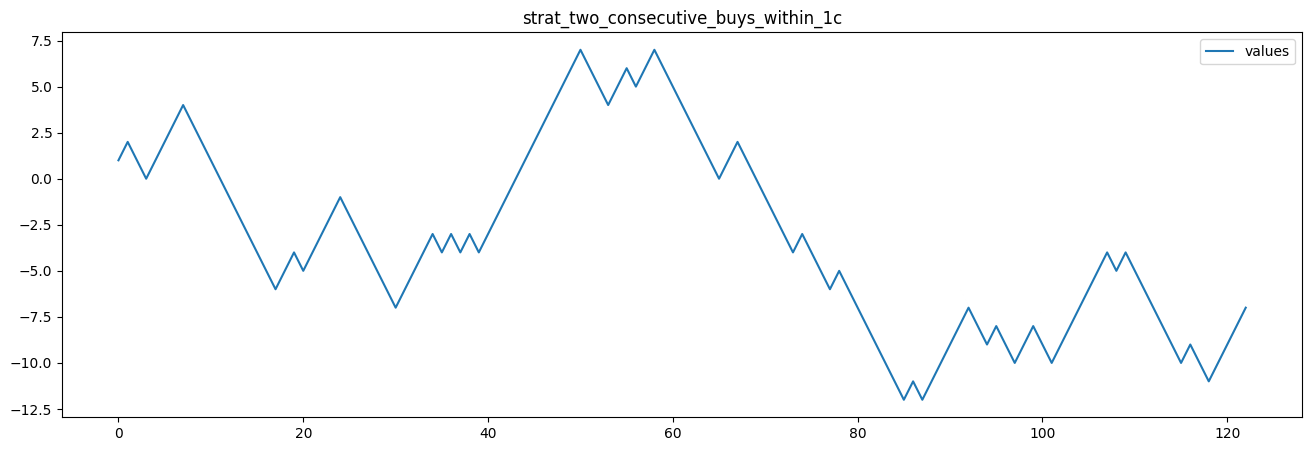

strat_two_consecutive_buys_within_2c


<Figure size 1600x500 with 0 Axes>

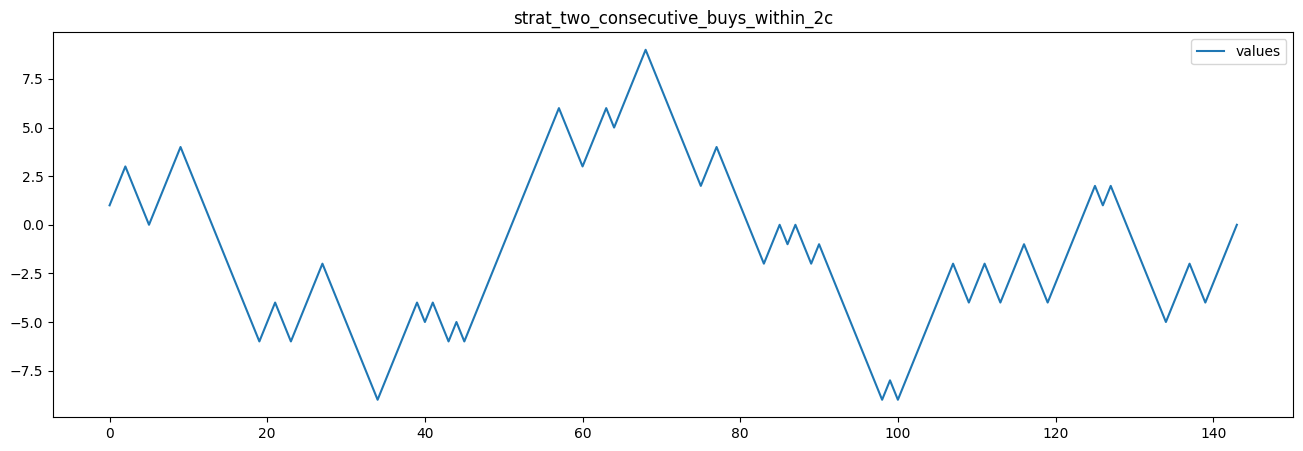

strat_two_consecutive_buys_within_3c


<Figure size 1600x500 with 0 Axes>

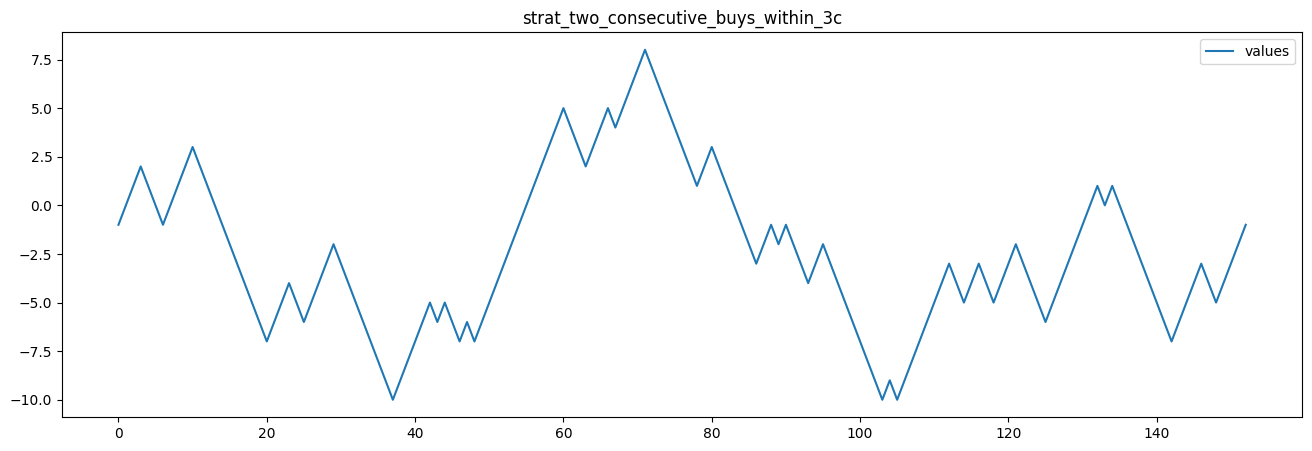

strat_two_consecutive_buys_within_4c


<Figure size 1600x500 with 0 Axes>

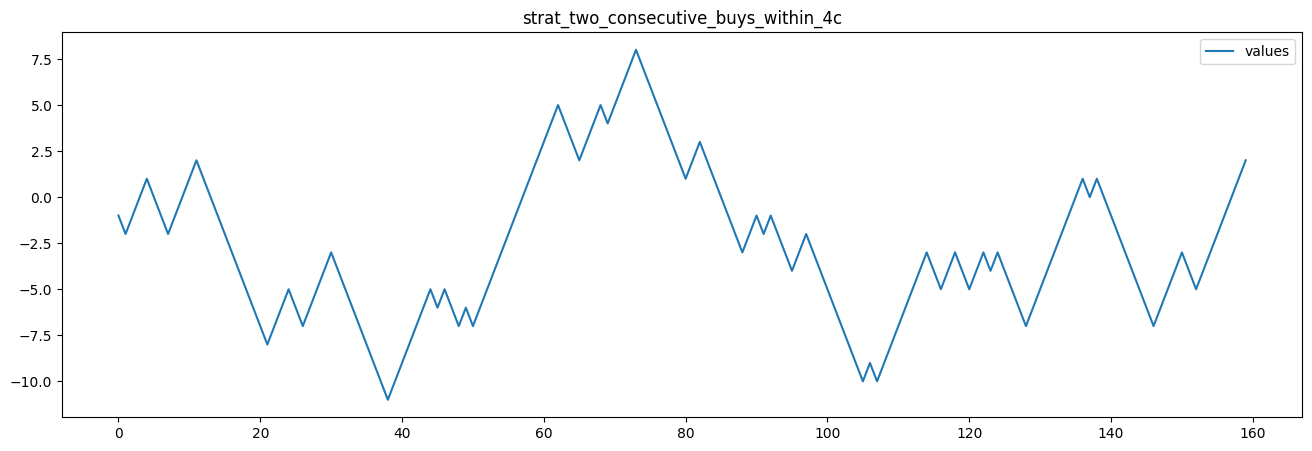

strat_two_consecutive_buys_within_5c


<Figure size 1600x500 with 0 Axes>

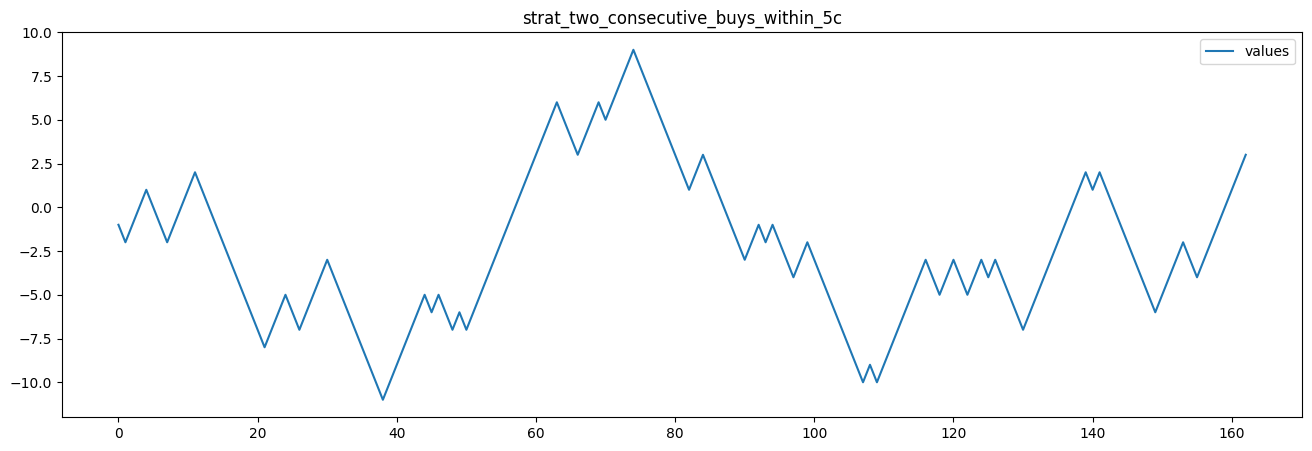

strat_two_consecutive_sells_within_1c


<Figure size 1600x500 with 0 Axes>

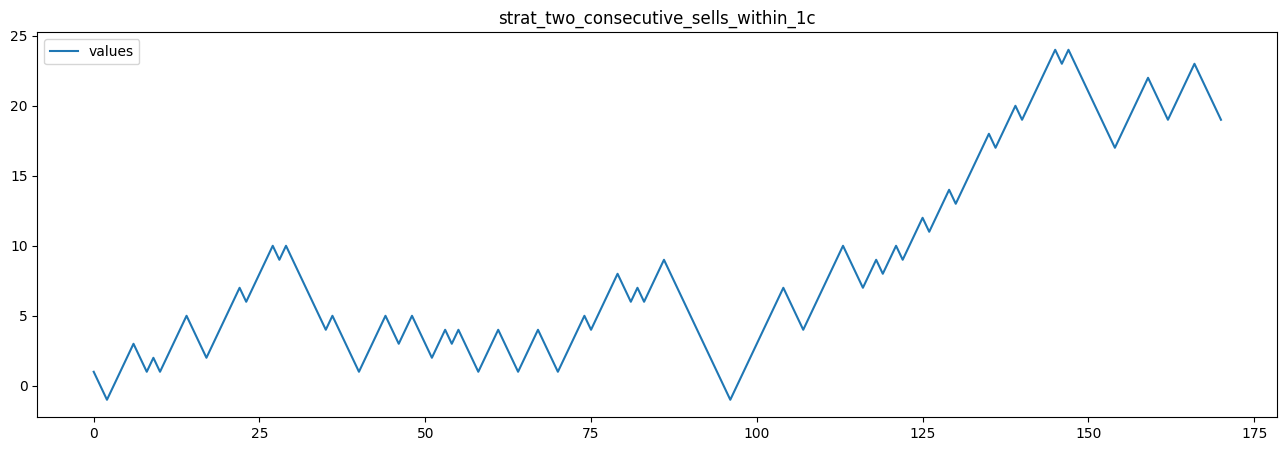

strat_two_consecutive_sells_within_2c


<Figure size 1600x500 with 0 Axes>

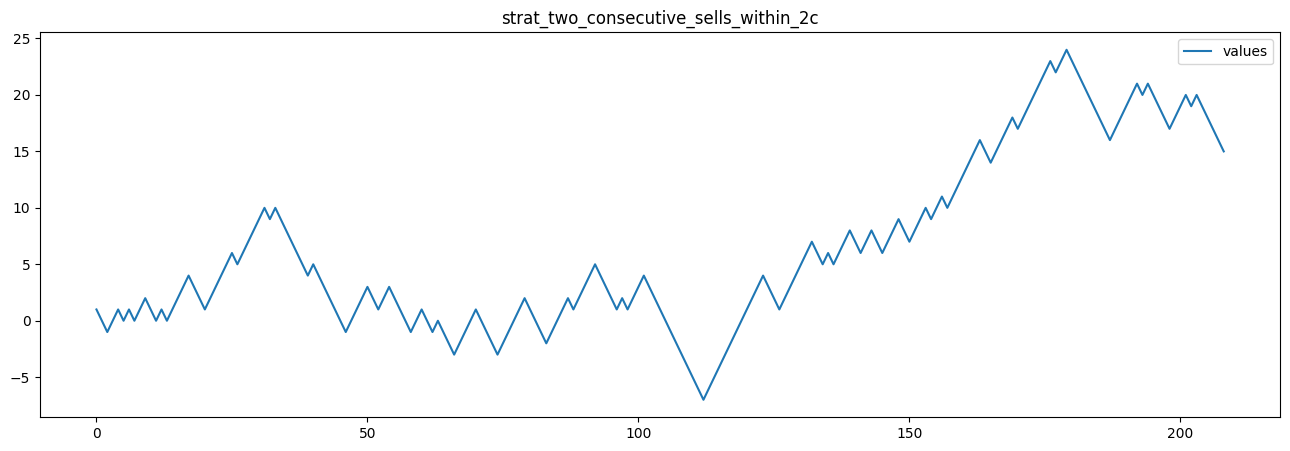

strat_two_consecutive_sells_within_3c


<Figure size 1600x500 with 0 Axes>

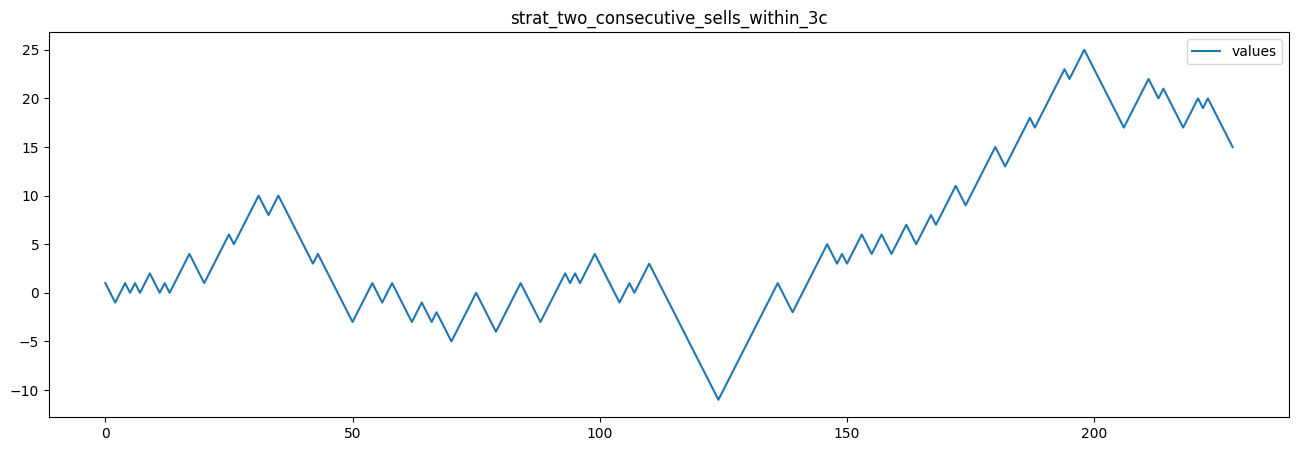

strat_two_consecutive_sells_within_4c


<Figure size 1600x500 with 0 Axes>

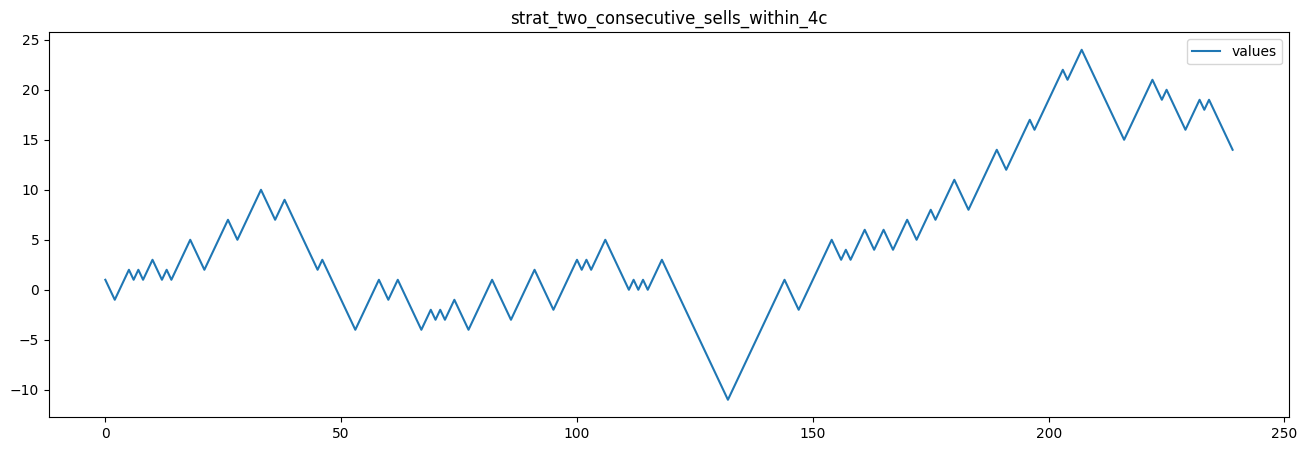

strat_two_consecutive_sells_within_5c


<Figure size 1600x500 with 0 Axes>

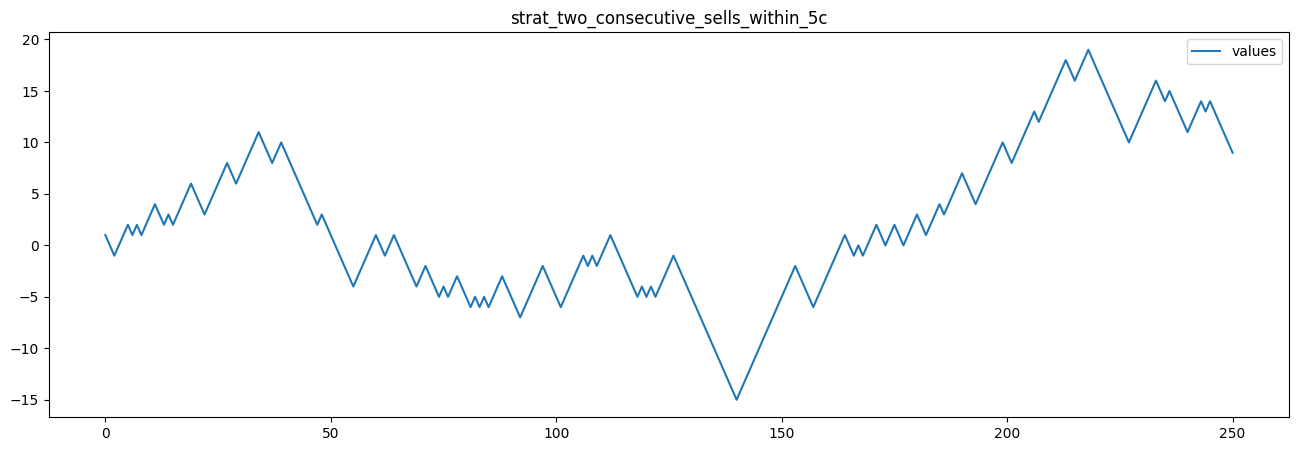

strat_two_consecutive_same_dir_within_1c


<Figure size 1600x500 with 0 Axes>

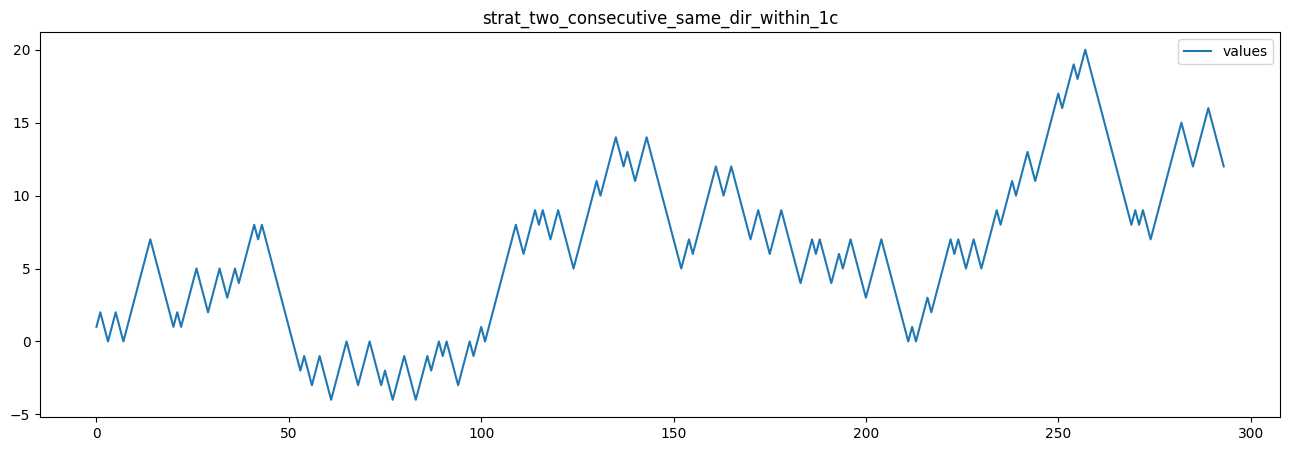

strat_two_consecutive_same_dir_within_2c


<Figure size 1600x500 with 0 Axes>

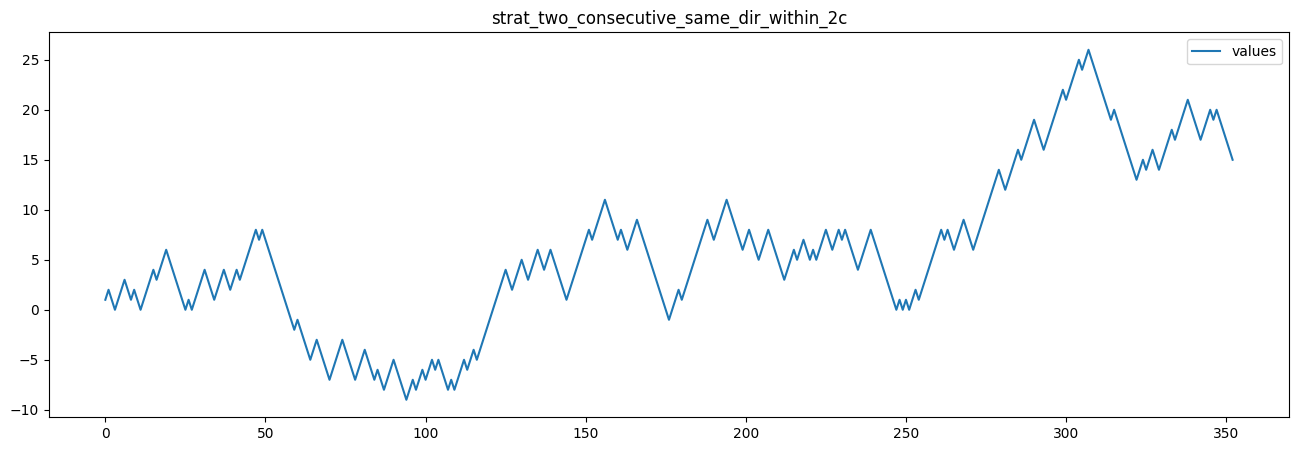

strat_two_consecutive_same_dir_within_3c


<Figure size 1600x500 with 0 Axes>

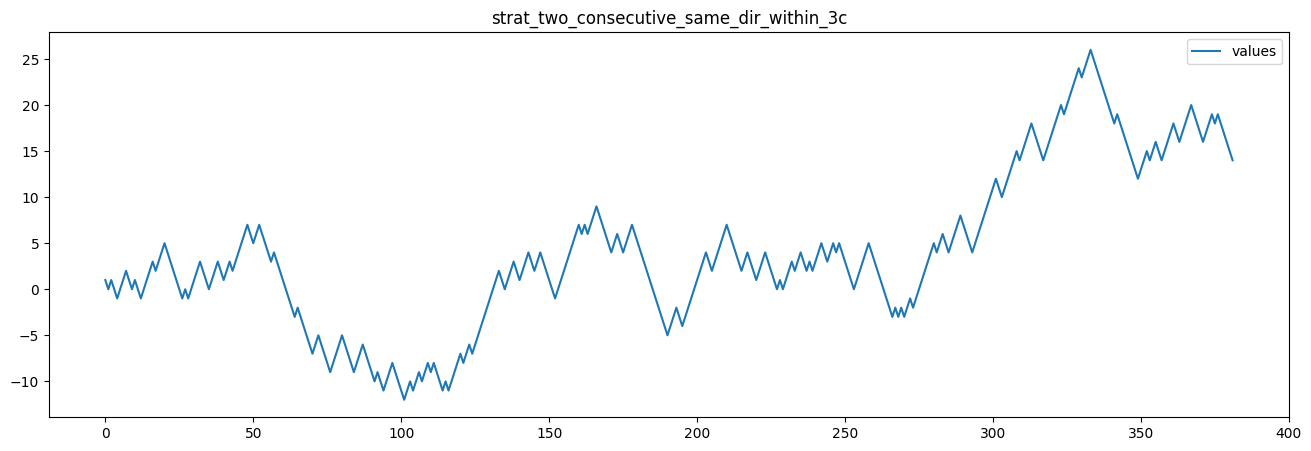

strat_two_consecutive_same_dir_within_4c


<Figure size 1600x500 with 0 Axes>

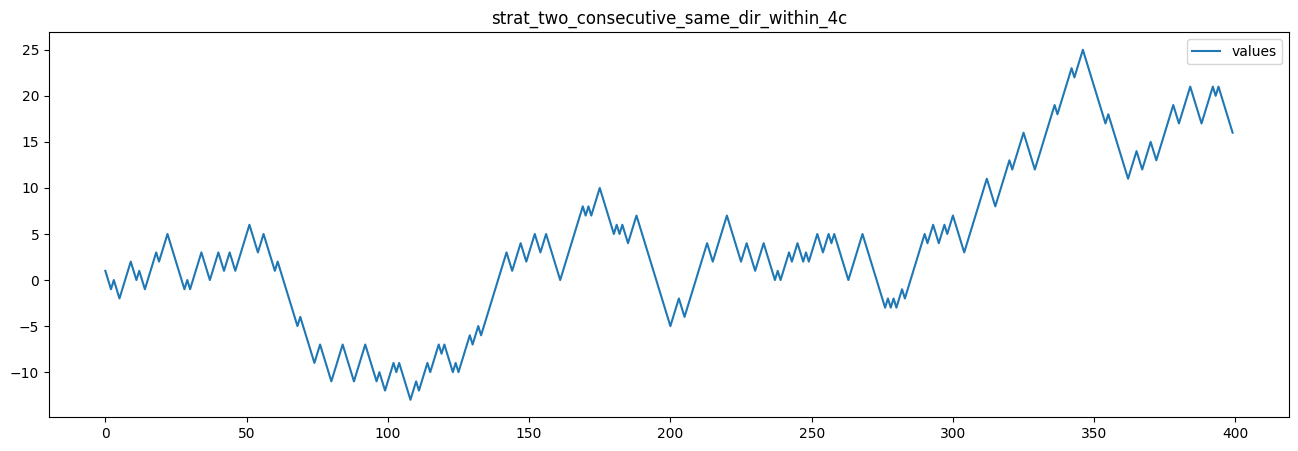

strat_two_consecutive_same_dir_within_5c


<Figure size 1600x500 with 0 Axes>

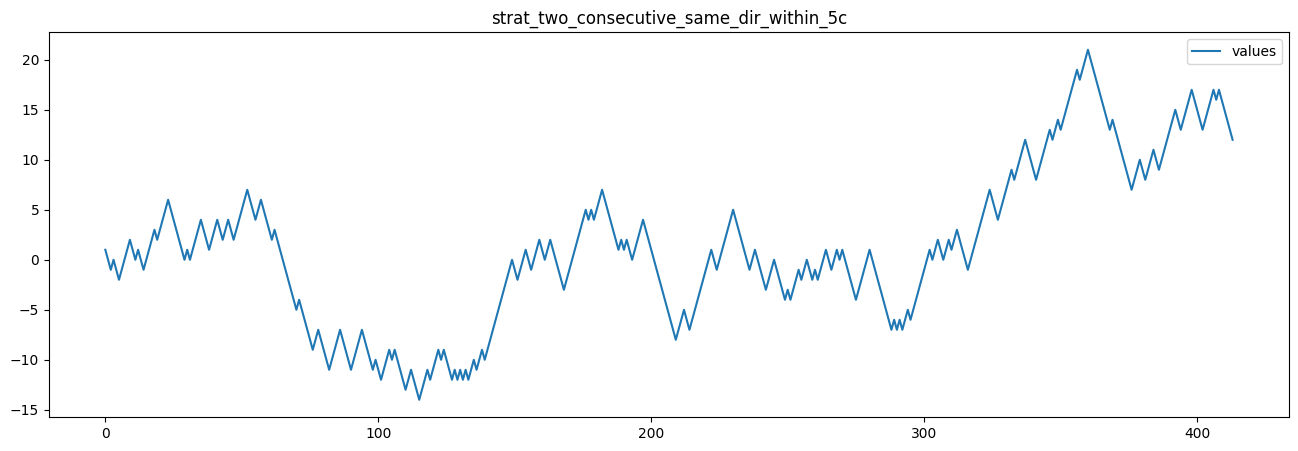

strat_direction_flip_within_1c


<Figure size 1600x500 with 0 Axes>

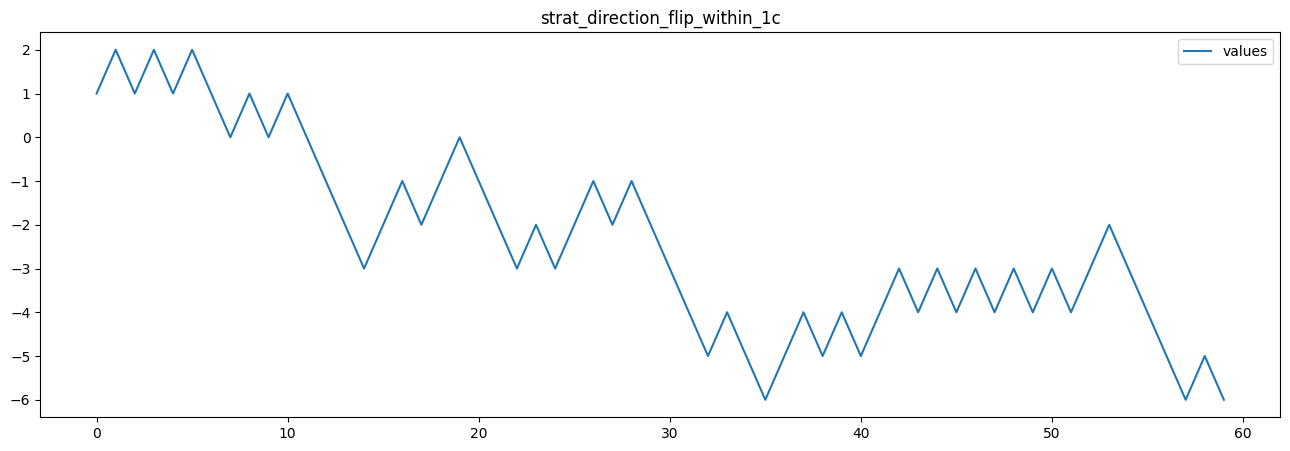

strat_direction_flip_within_2c


<Figure size 1600x500 with 0 Axes>

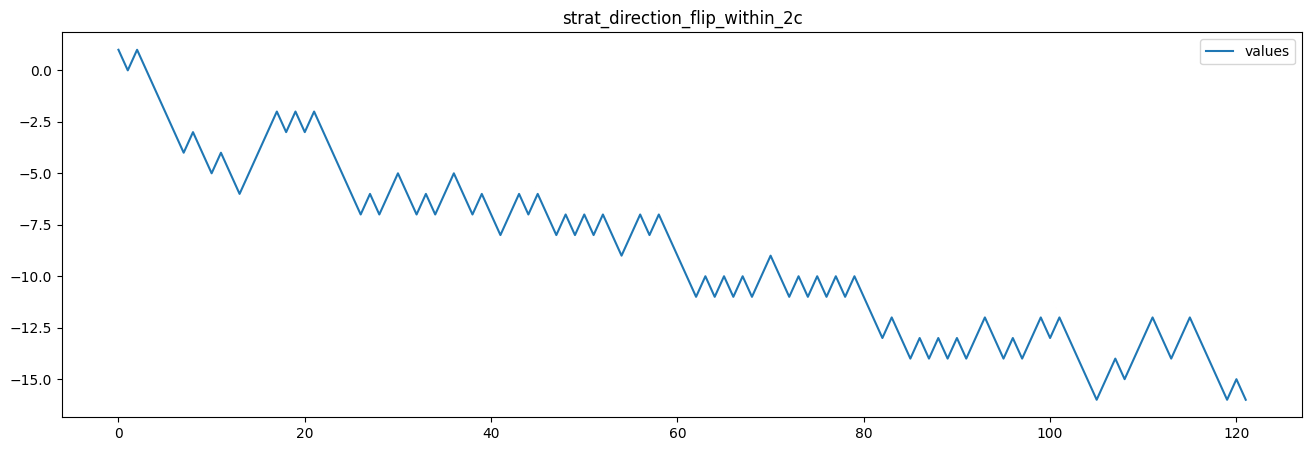

strat_direction_flip_within_3c


<Figure size 1600x500 with 0 Axes>

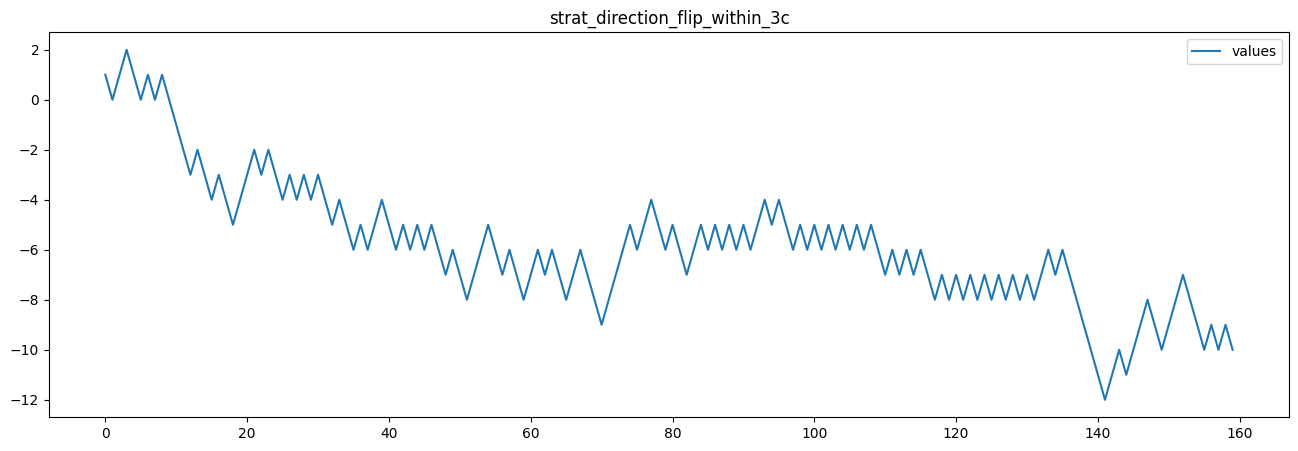

strat_direction_flip_within_4c


<Figure size 1600x500 with 0 Axes>

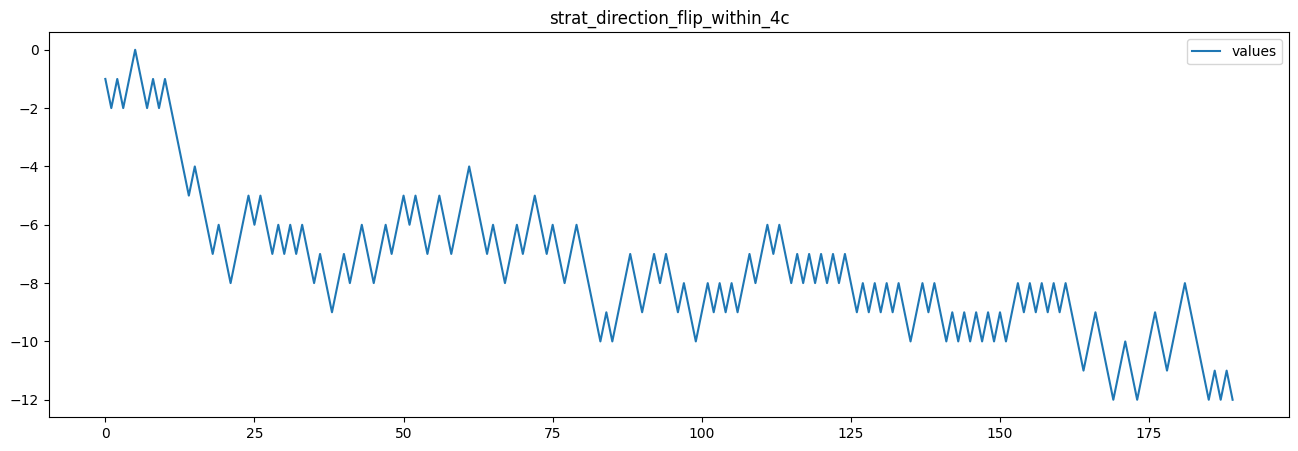

strat_direction_flip_within_5c


<Figure size 1600x500 with 0 Axes>

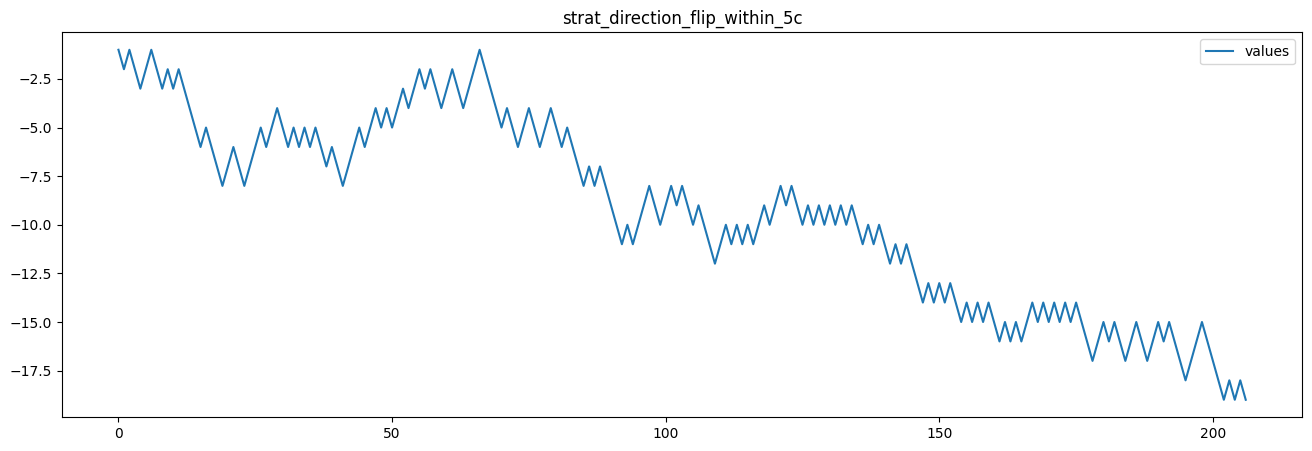

strat_buy_run_ge_2


<Figure size 1600x500 with 0 Axes>

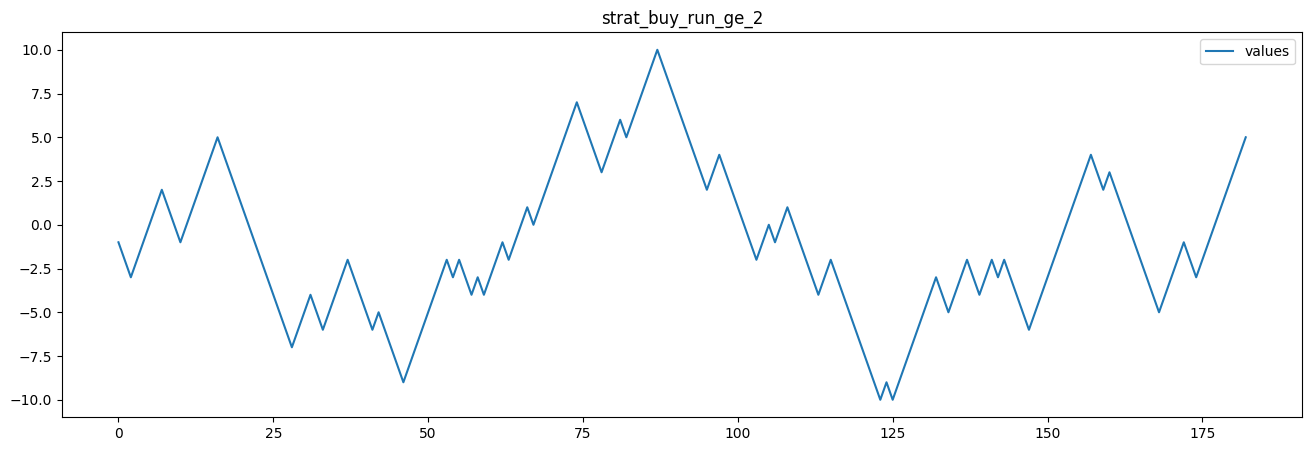

strat_sell_run_ge_2


<Figure size 1600x500 with 0 Axes>

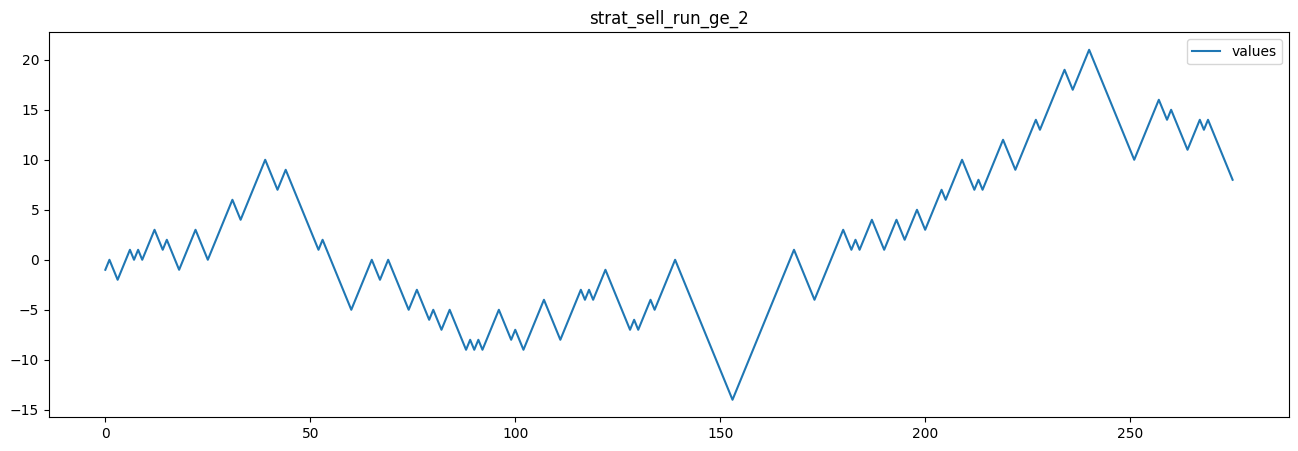

strat_buy_run_ge_2_within_5c


<Figure size 1600x500 with 0 Axes>

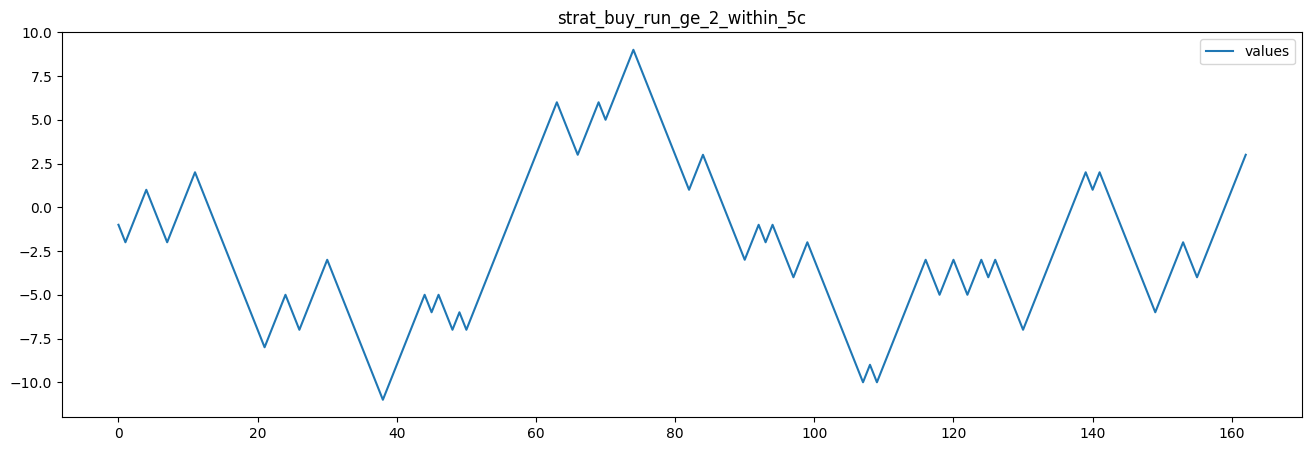

strat_sell_run_ge_2_within_5c


<Figure size 1600x500 with 0 Axes>

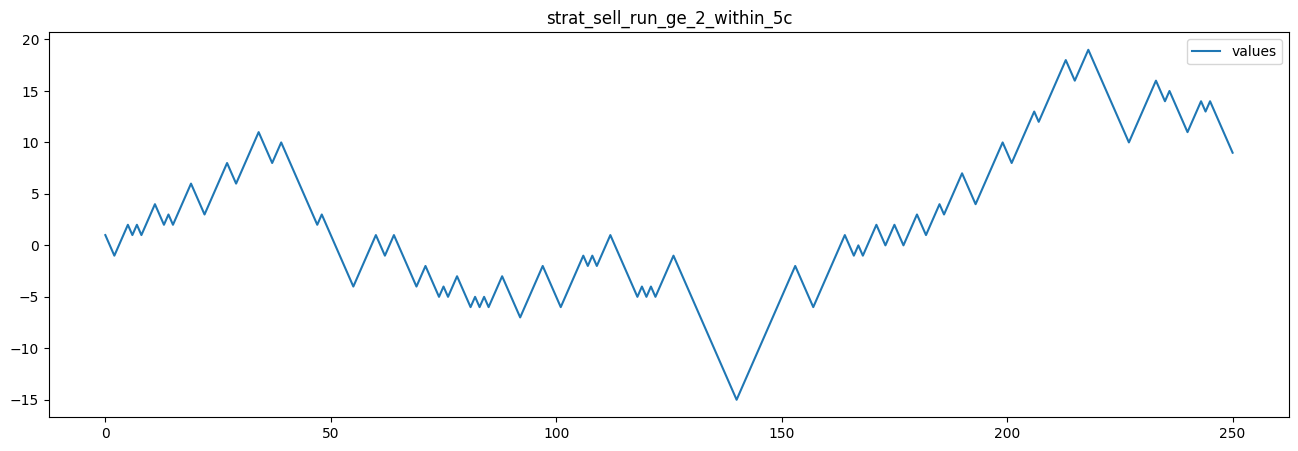

strat_london_buy


<Figure size 1600x500 with 0 Axes>

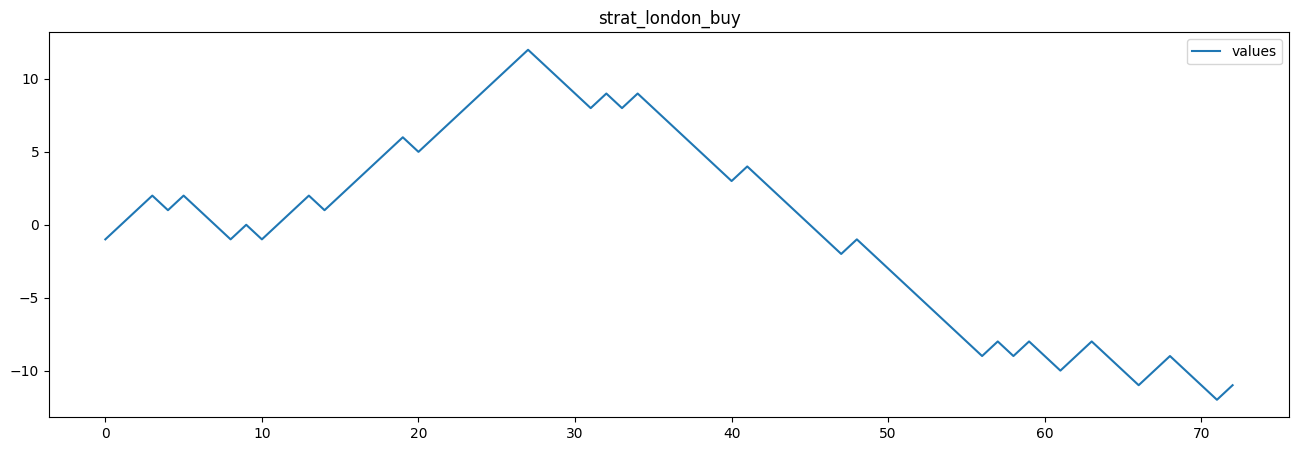

strat_newyork_sell


<Figure size 1600x500 with 0 Axes>

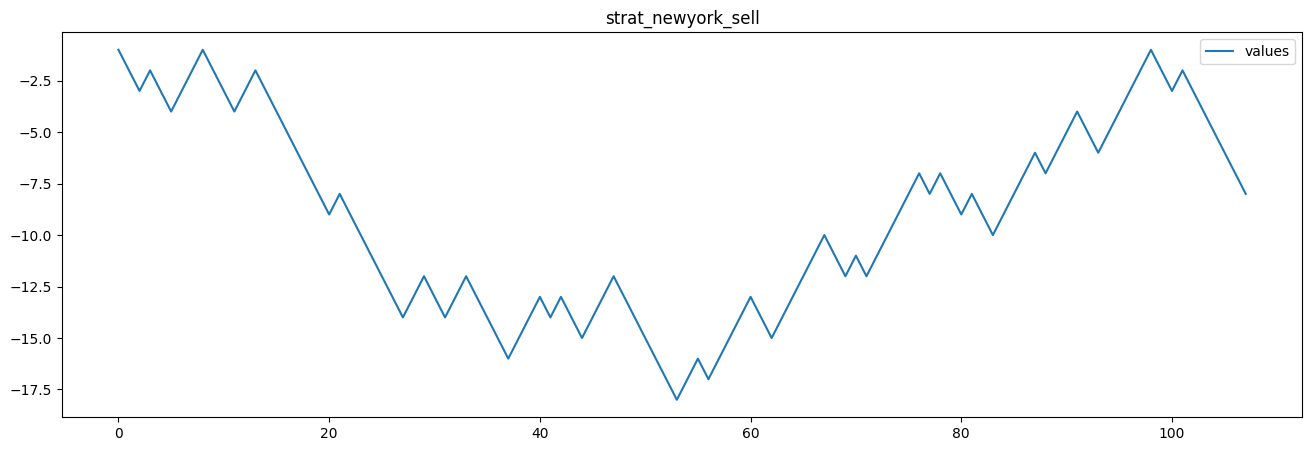

In [39]:
trade_details_nf = _df.combine_first(trade_details_analysis_nf)
trade_details_nf.set_index('entry_time', inplace=True)

trade_details_nf_dict = {}
for column in trade_details_analysis_nf.columns:
    print(column)
    trade_details_nf_dict[column] = {}
    df_temp = trade_details_nf['win/loss'][trade_details_nf[column] == 1]
    
    sum_of_win_loss = []
    sum_win_loss = 0
    
    for item in df_temp.items():
        if item[1] == 1:
            sum_win_loss += 1
        else:
            sum_win_loss -= 1
        
        sum_of_win_loss.append(sum_win_loss)
        
    trade_details_nf_dict[column]['datetimes'] = df_temp.index
    trade_details_nf_dict[column]['values'] = sum_of_win_loss
    

for key in list(trade_details_nf_dict.keys()):
    print(key)
    plt.figure(figsize=(16, 5))
    
    df_temp = pd.DataFrame({'datetimes': trade_details_nf_dict[key]['datetimes'], 
                            'values': trade_details_nf_dict[key]['values']})
    df_temp.plot(figsize=(16, 5), title=key)
    
    if not df_temp.empty:
        if df_temp.iloc[-1]['values'] > 0:
            winning_strats.append(key)

    plt.show()

strat_two_consecutive_buys_within_1c


<Figure size 1600x500 with 0 Axes>

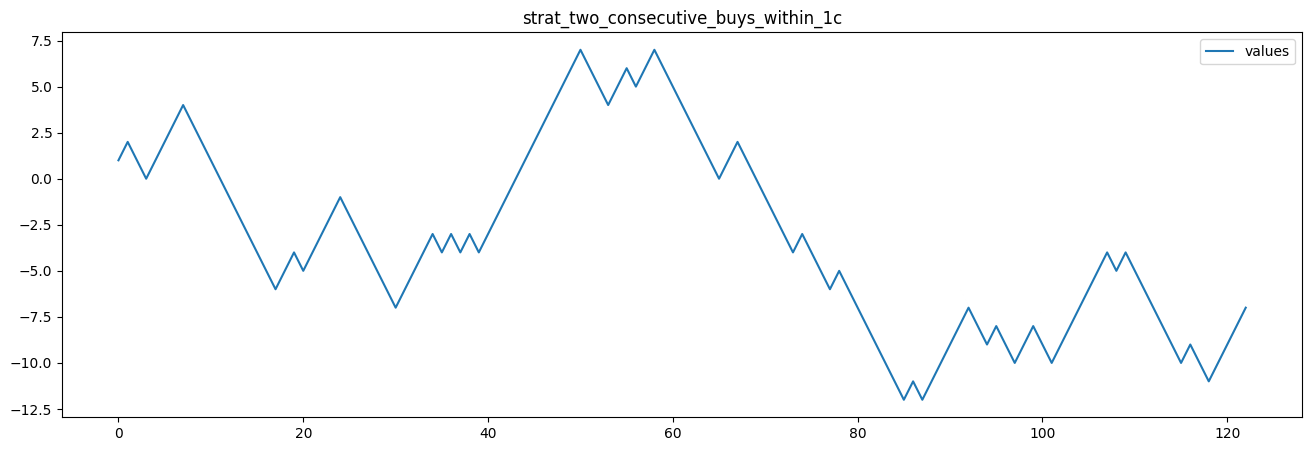

strat_two_consecutive_buys_within_2c


<Figure size 1600x500 with 0 Axes>

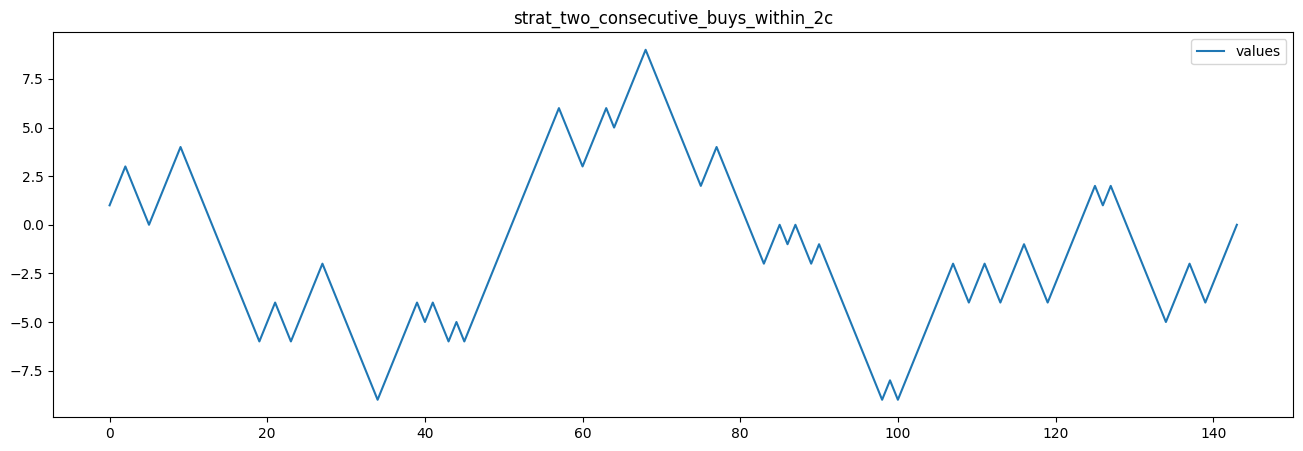

strat_two_consecutive_buys_within_3c


<Figure size 1600x500 with 0 Axes>

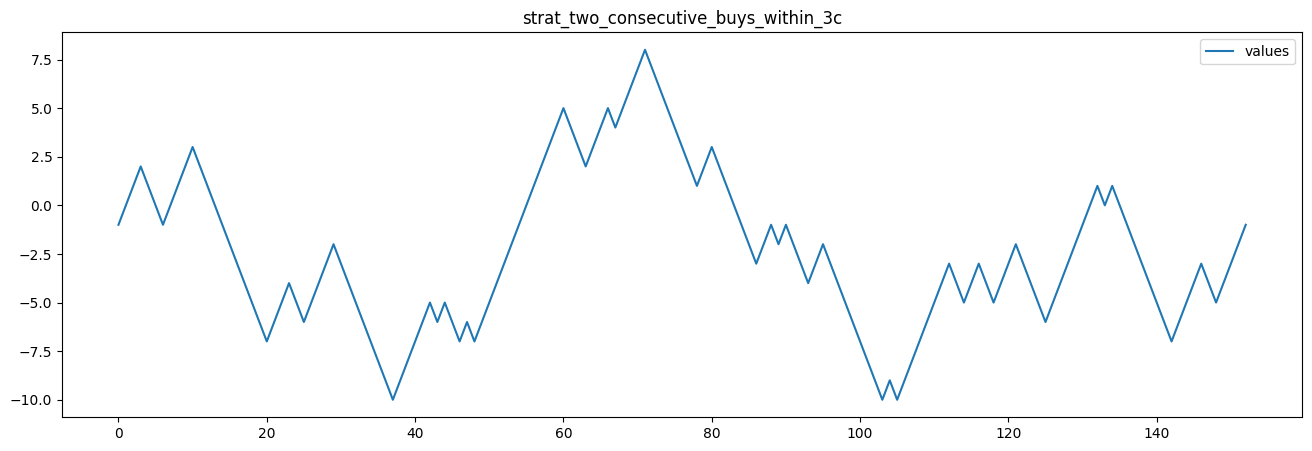

strat_two_consecutive_buys_within_4c


<Figure size 1600x500 with 0 Axes>

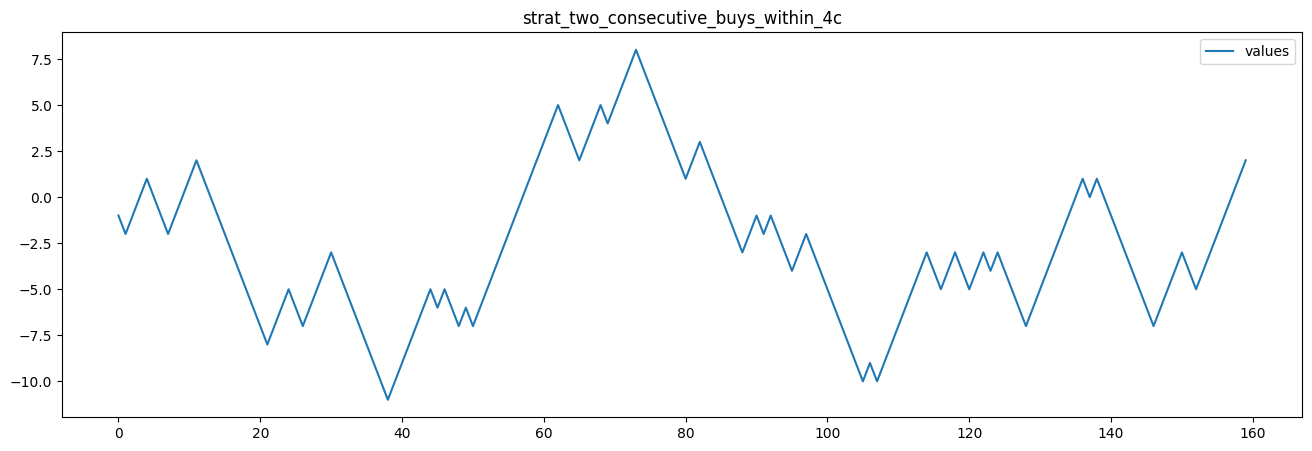

strat_two_consecutive_buys_within_5c


<Figure size 1600x500 with 0 Axes>

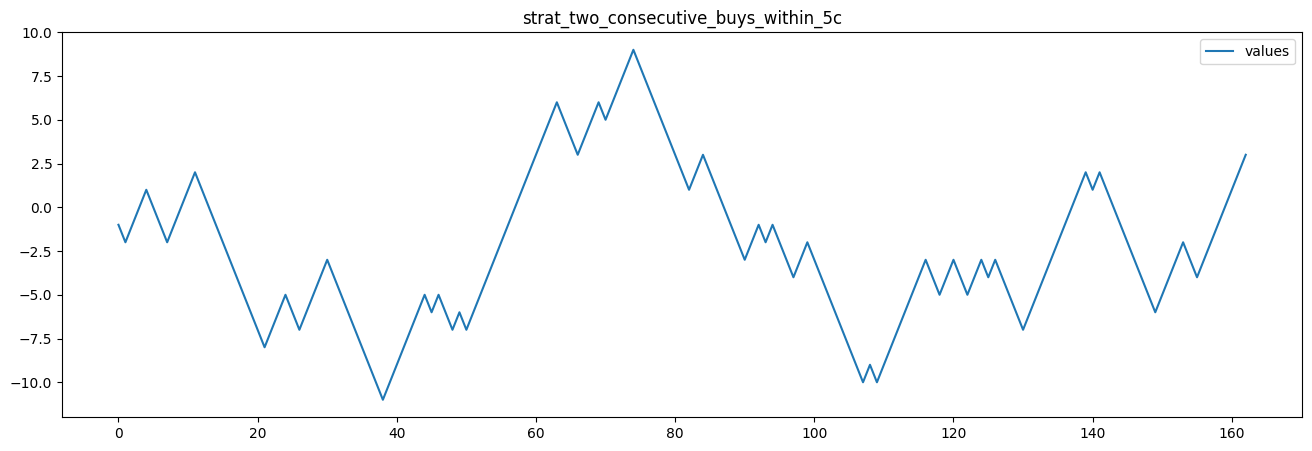

strat_two_consecutive_sells_within_1c


<Figure size 1600x500 with 0 Axes>

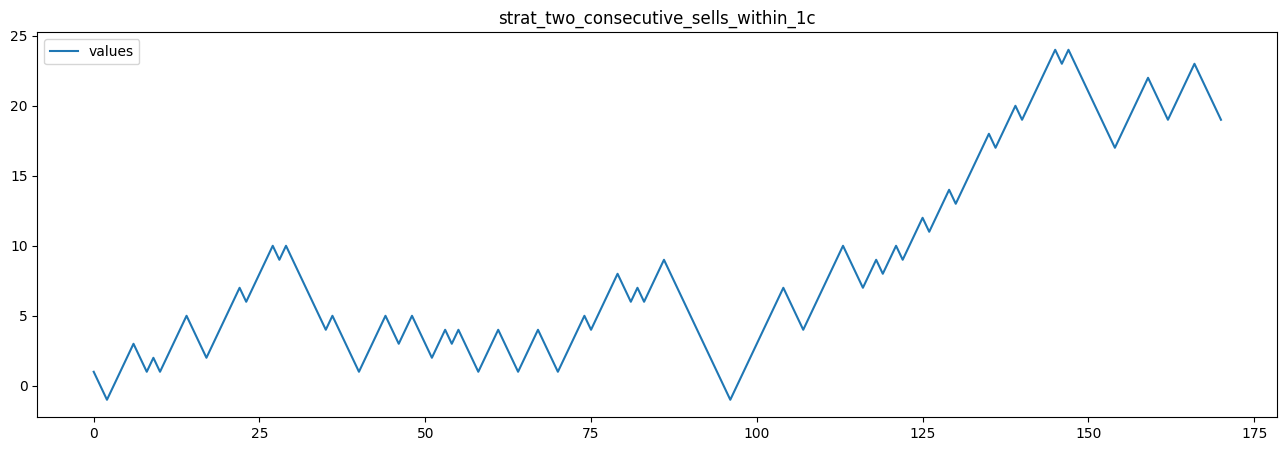

strat_two_consecutive_sells_within_2c


<Figure size 1600x500 with 0 Axes>

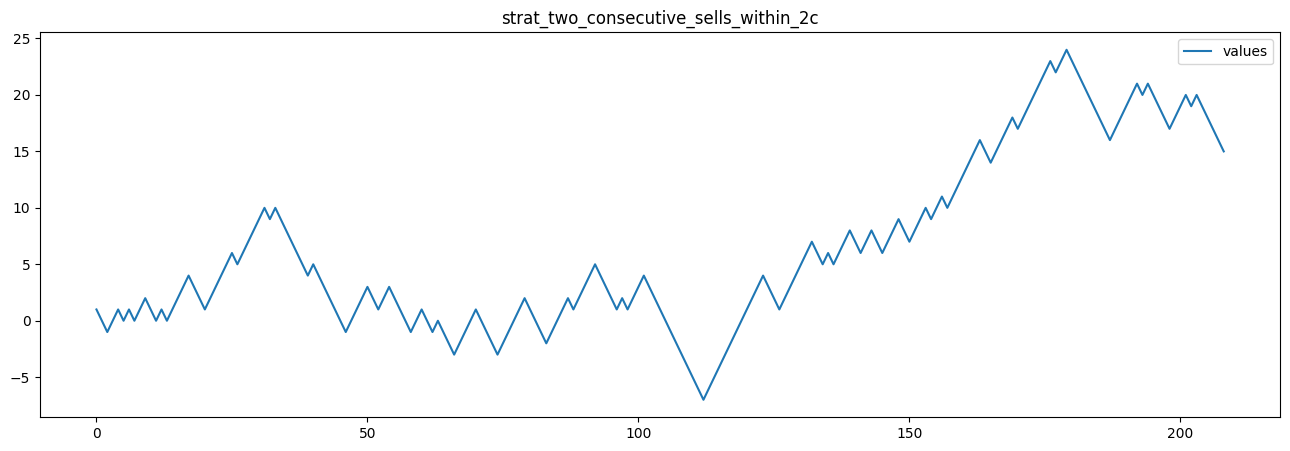

strat_two_consecutive_sells_within_3c


<Figure size 1600x500 with 0 Axes>

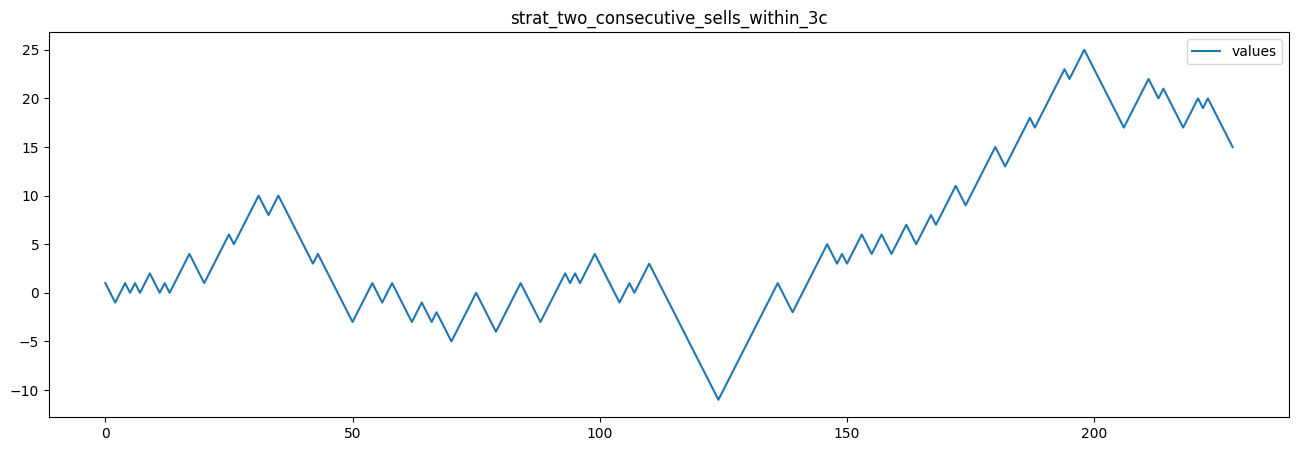

strat_two_consecutive_sells_within_4c


<Figure size 1600x500 with 0 Axes>

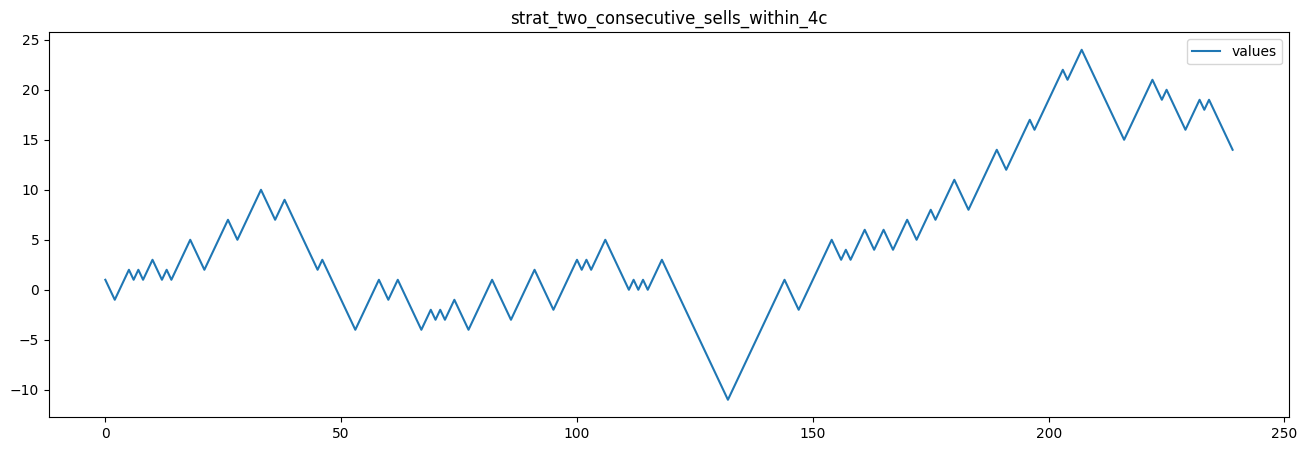

strat_two_consecutive_sells_within_5c


<Figure size 1600x500 with 0 Axes>

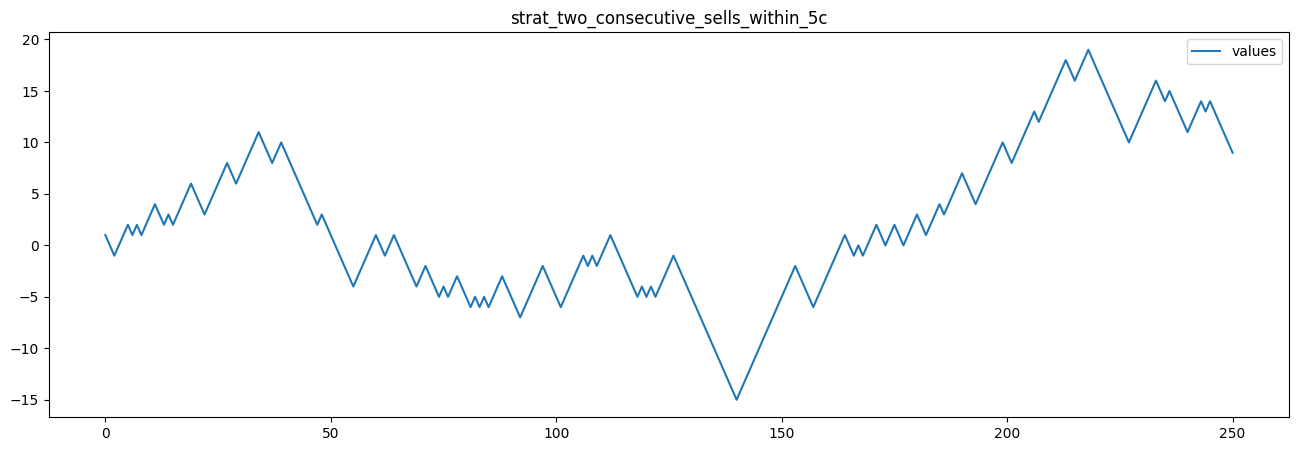

strat_two_consecutive_same_dir_within_1c


<Figure size 1600x500 with 0 Axes>

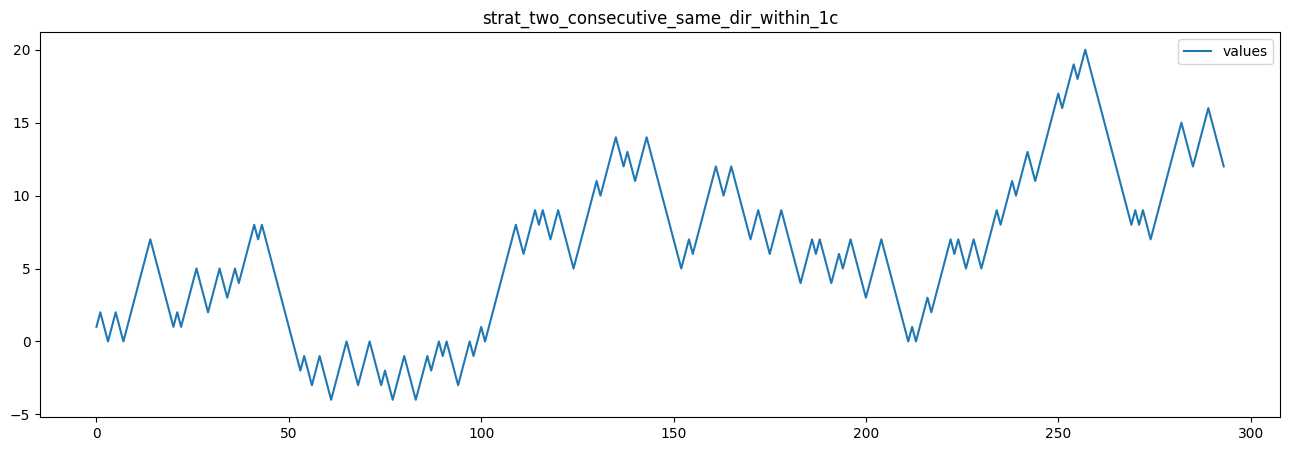

strat_two_consecutive_same_dir_within_2c


<Figure size 1600x500 with 0 Axes>

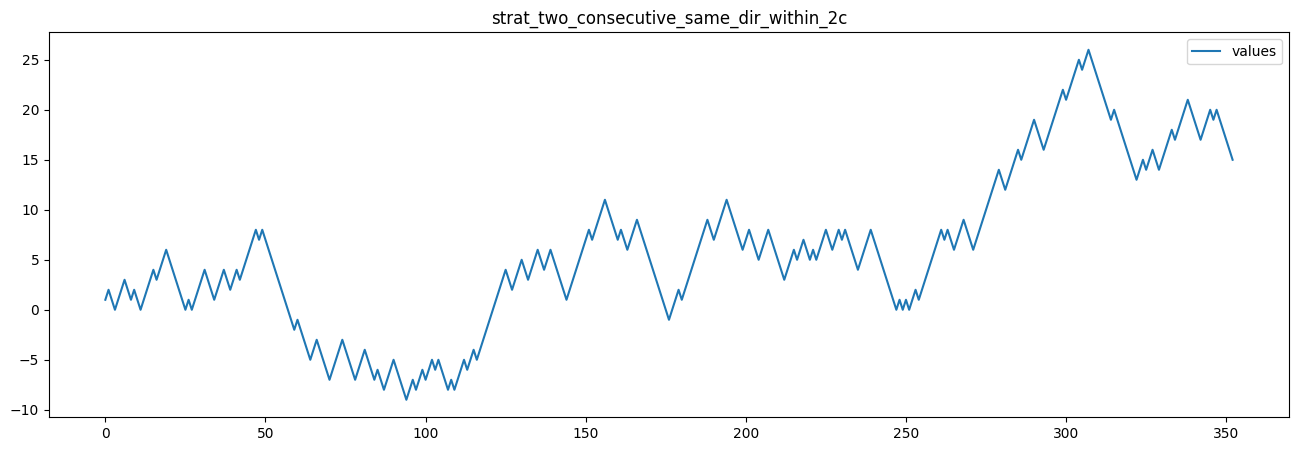

strat_two_consecutive_same_dir_within_3c


<Figure size 1600x500 with 0 Axes>

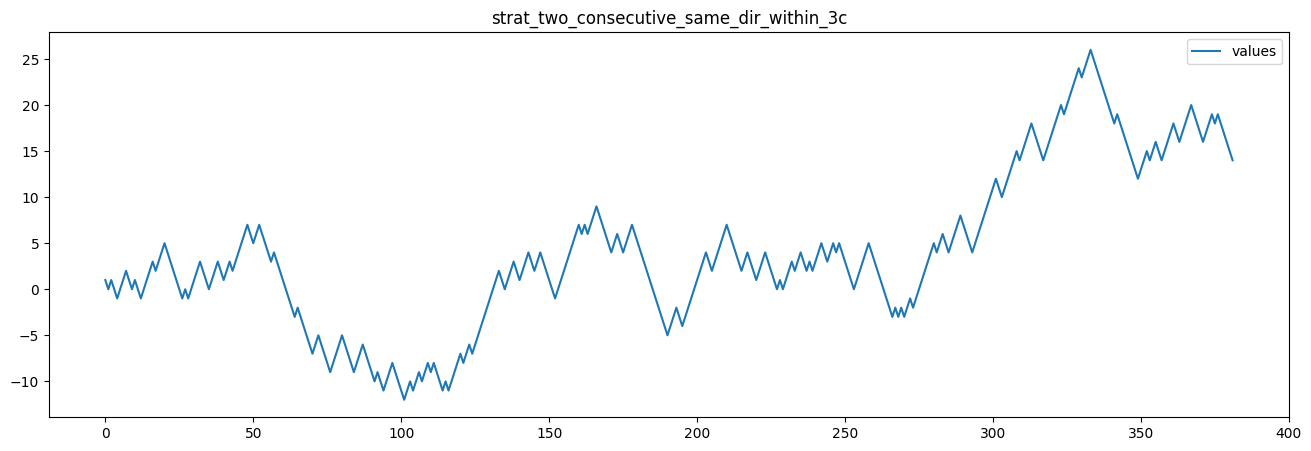

strat_two_consecutive_same_dir_within_4c


<Figure size 1600x500 with 0 Axes>

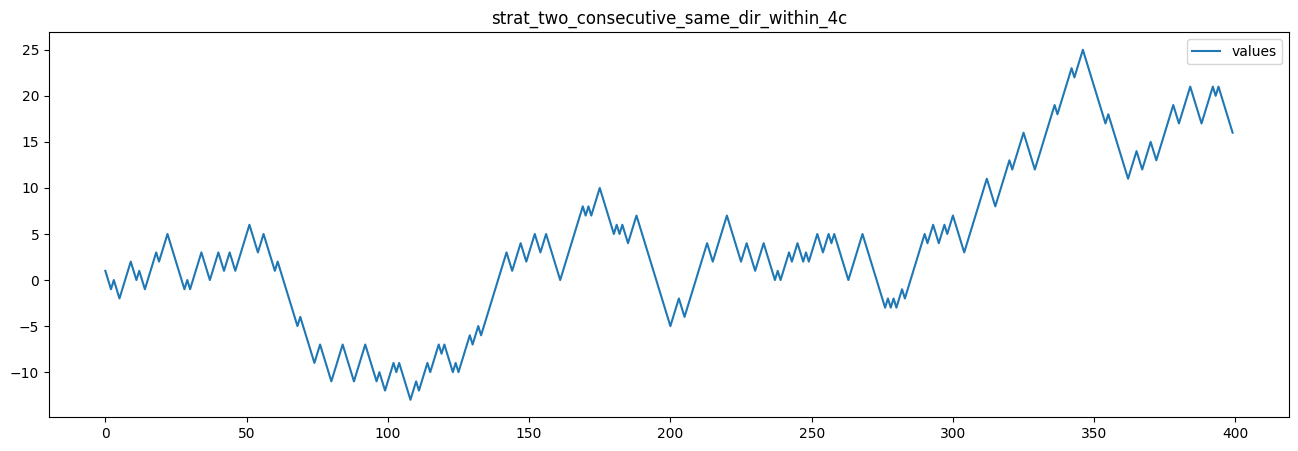

strat_two_consecutive_same_dir_within_5c


<Figure size 1600x500 with 0 Axes>

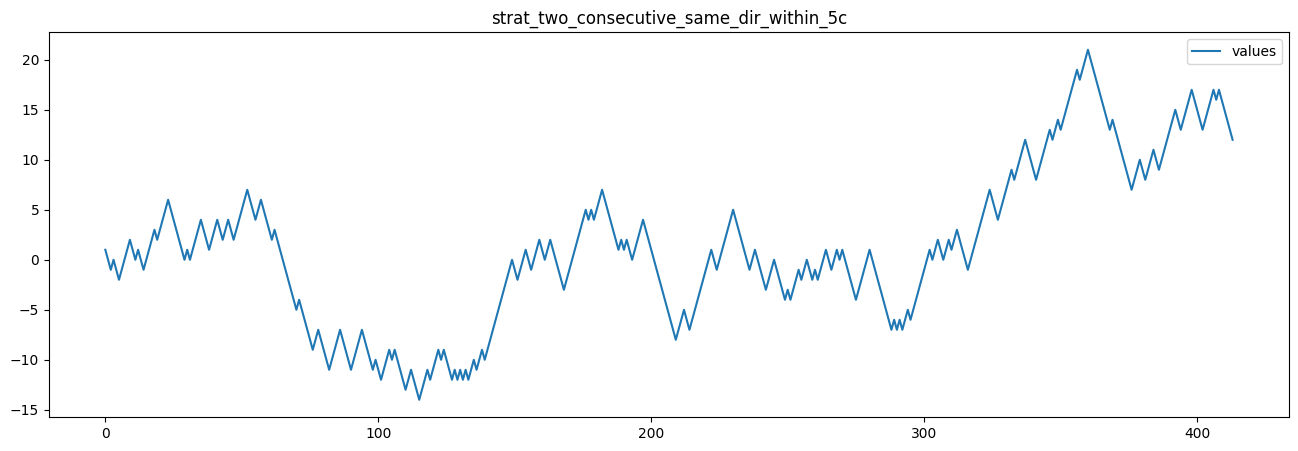

strat_direction_flip_within_1c


<Figure size 1600x500 with 0 Axes>

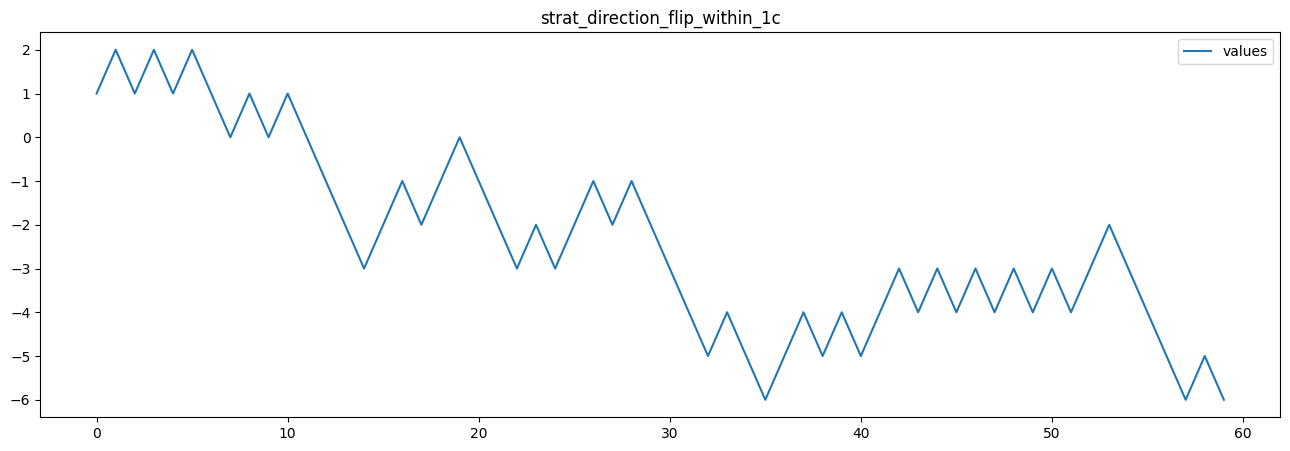

strat_direction_flip_within_2c


<Figure size 1600x500 with 0 Axes>

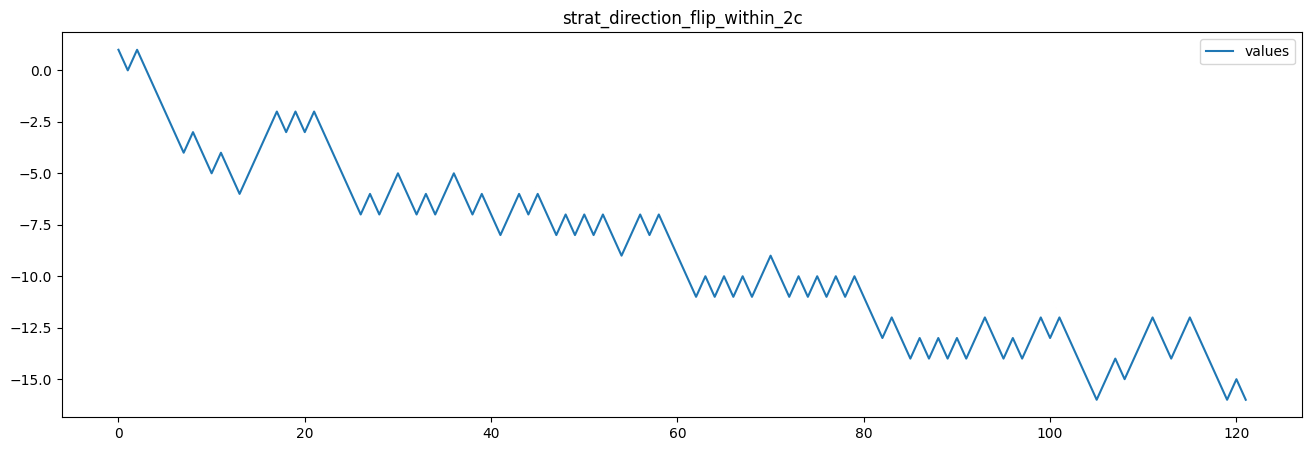

strat_direction_flip_within_3c


<Figure size 1600x500 with 0 Axes>

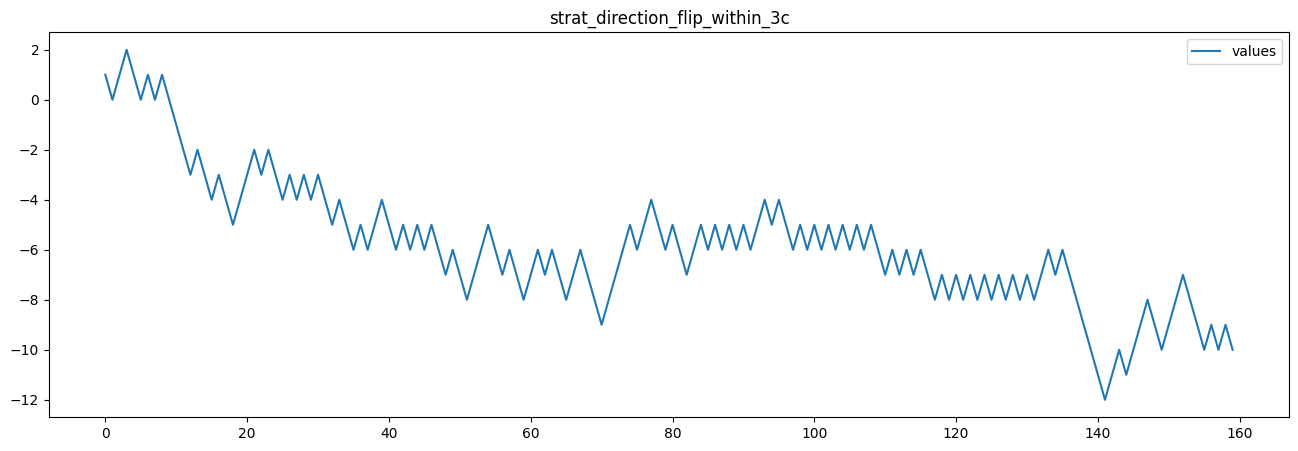

strat_direction_flip_within_4c


<Figure size 1600x500 with 0 Axes>

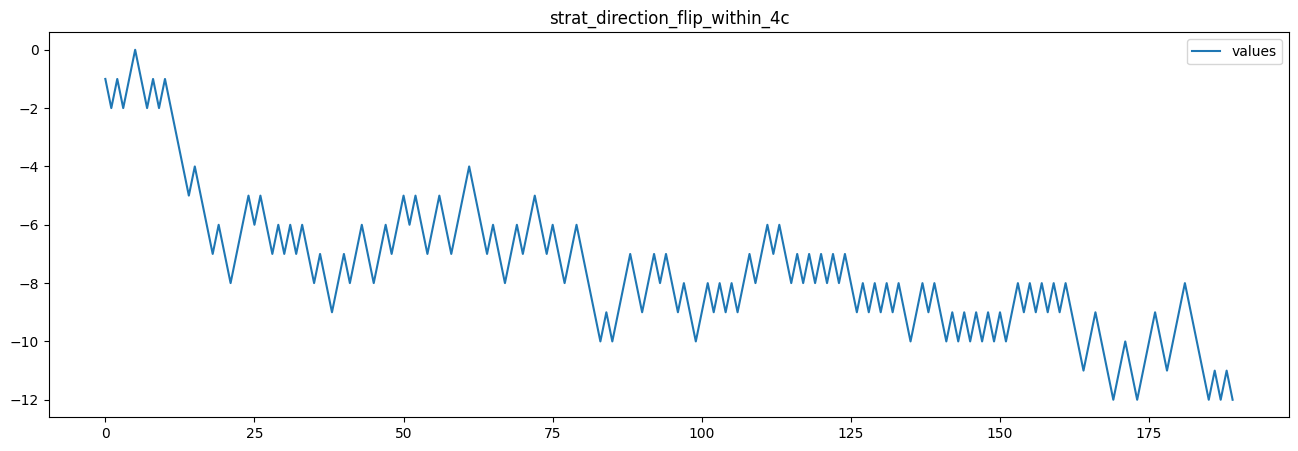

strat_direction_flip_within_5c


<Figure size 1600x500 with 0 Axes>

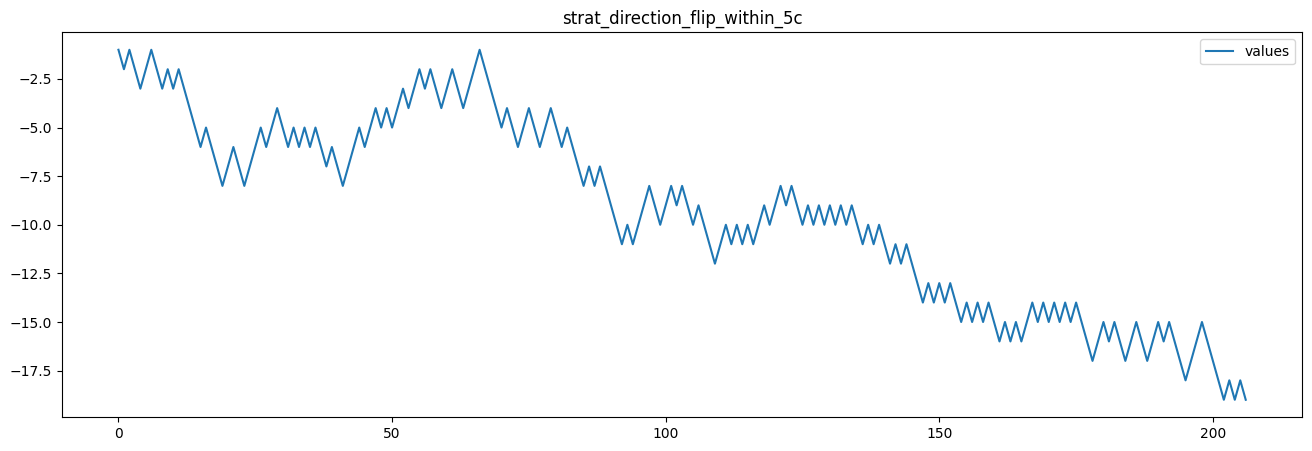

strat_buy_run_ge_2


<Figure size 1600x500 with 0 Axes>

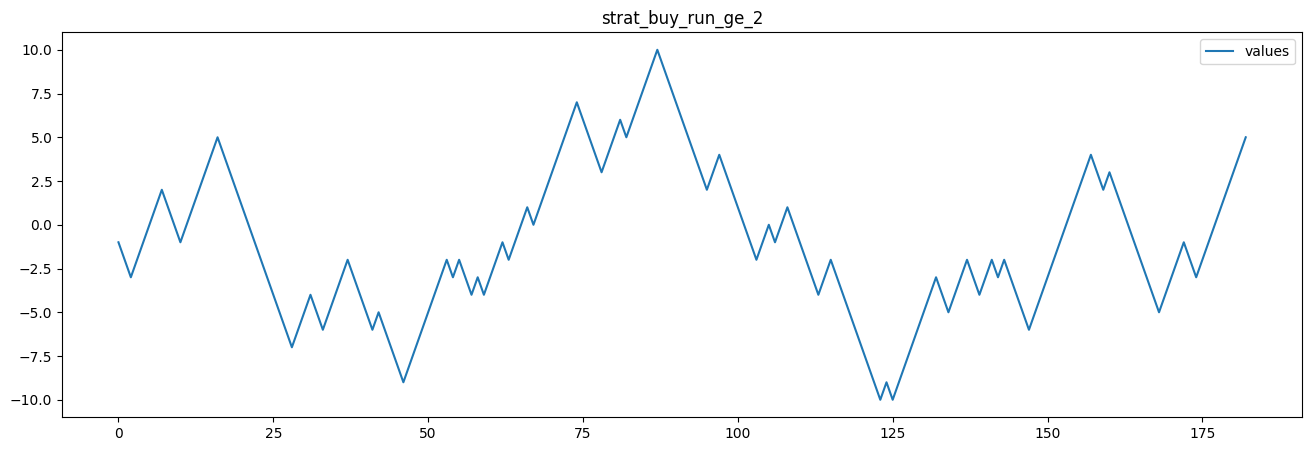

strat_sell_run_ge_2


<Figure size 1600x500 with 0 Axes>

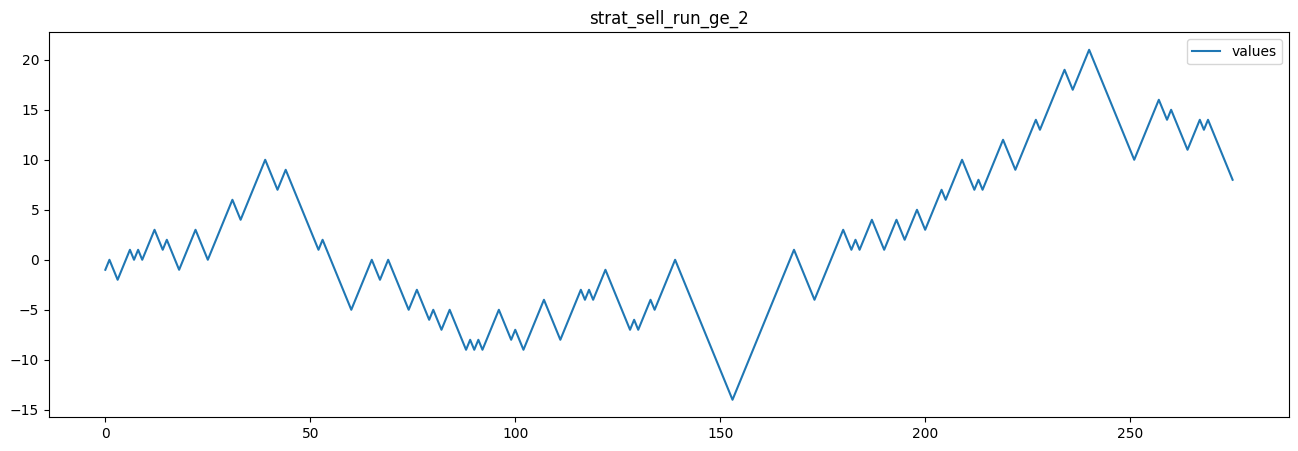

strat_buy_run_ge_2_within_5c


<Figure size 1600x500 with 0 Axes>

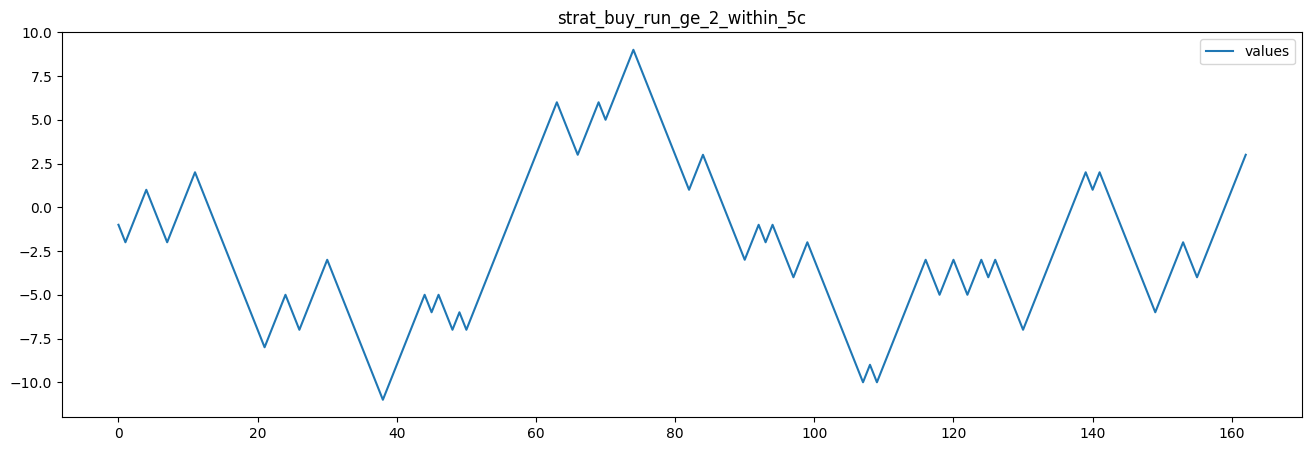

strat_sell_run_ge_2_within_5c


<Figure size 1600x500 with 0 Axes>

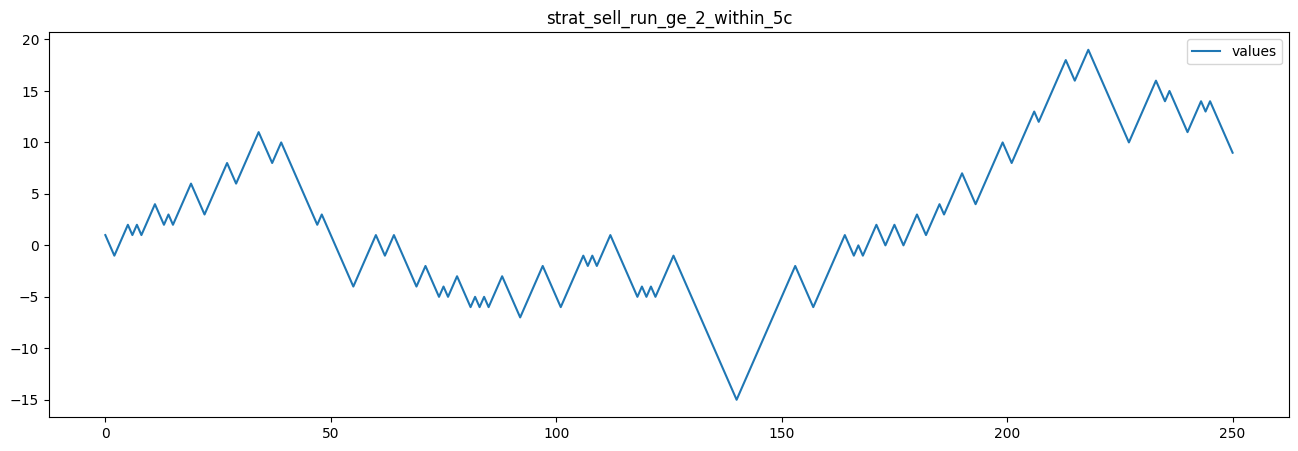

strat_london_buy


<Figure size 1600x500 with 0 Axes>

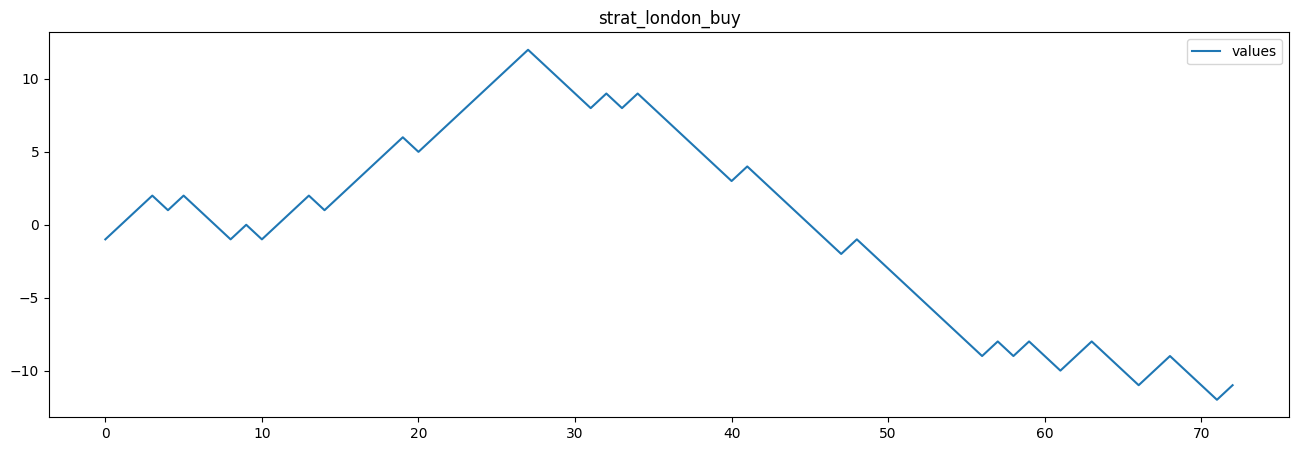

strat_newyork_sell


<Figure size 1600x500 with 0 Axes>

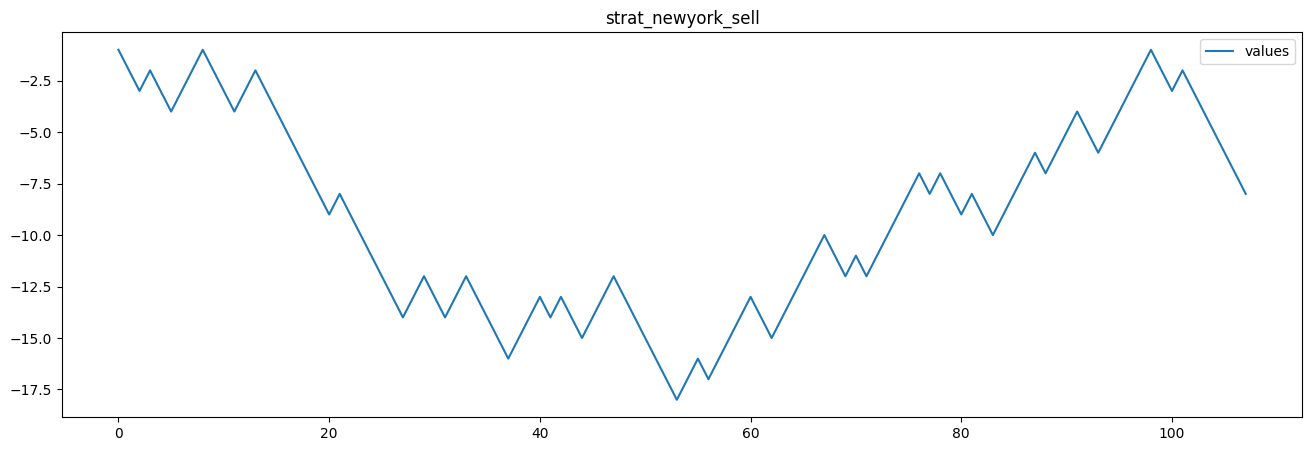

In [40]:
winning_strats = []

for key in list(trade_details_nf_dict.keys()):
    print(key)
    plt.figure(figsize=(16, 5))
    
    df_temp = pd.DataFrame({'datetimes': trade_details_nf_dict[key]['datetimes'], 
                            'values': trade_details_nf_dict[key]['values']})
    df_temp.plot(figsize=(16, 5), title=key)
    
    if not df_temp.empty:
        if df_temp.iloc[-1]['values'] > 0:
            winning_strats.append(key)

    plt.show()

In [189]:
for key in winning_strats:
    print(key)
    plt.figure(figsize=(16, 5))
    
    df_temp = pd.DataFrame({'datetimes': trade_details_nf_dict[key]['datetimes'], 
                            'values': trade_details_nf_dict[key]['values']})
    df_temp.plot(figsize=(16, 5), title=key)
    
    plt.show()

In [202]:
for ii in strategies_nf.keys():
    print(ii)

strat_two_consecutive_buys_within_1c
strat_two_consecutive_buys_within_2c
strat_two_consecutive_buys_within_3c
strat_two_consecutive_buys_within_4c
strat_two_consecutive_buys_within_5c
strat_two_consecutive_sells_within_1c
strat_two_consecutive_sells_within_2c
strat_two_consecutive_sells_within_3c
strat_two_consecutive_sells_within_4c
strat_two_consecutive_sells_within_5c
strat_two_consecutive_same_dir_within_1c
strat_two_consecutive_same_dir_within_2c
strat_two_consecutive_same_dir_within_3c
strat_two_consecutive_same_dir_within_4c
strat_two_consecutive_same_dir_within_5c
strat_direction_flip_within_1c
strat_direction_flip_within_2c
strat_direction_flip_within_3c
strat_direction_flip_within_4c
strat_direction_flip_within_5c
strat_buy_run_ge_2
strat_sell_run_ge_2
strat_buy_run_ge_2_within_5c
strat_sell_run_ge_2_within_5c
strat_london_buy
strat_newyork_sell
